# ⚛️ CERN-Schaltzentrale & Teilchenphysik-Datenanalyse
### Ein interaktives Curriculum für den Begabtenkurs

Dieses Notebook führt durch den **echten Arbeitsablauf der experimentellen Teilchenphysik** —
von der Beschleunigung über die Kollision bis zur Entdeckung — und nutzt dabei durchgehend
**echte Open Data des CMS-Experiments** am LHC (Run 2011, √s = 7 TeV).

## 🎯 Lernziele
Nach diesem Notebook kannst du …
1. erklären, **wie ein Teilchenbeschleuniger** Teilchen auf nahezu Lichtgeschwindigkeit bringt und kollidieren lässt;
2. aus gemessenen **Impulsen die invariante Masse** eines Teilchens berechnen (relativistische Kinematik);
3. ein **Massenspektrum** lesen und die darin verborgene „Teilchen-Leiter" erkennen;
4. eine **Resonanz vermessen** (Masse & Breite per Kurvenanpassung) und mit dem Literaturwert (PDG) vergleichen;
5. die **statistische Signifikanz** einer Entdeckung berechnen und das **5σ-Kriterium** begründen;
6. den Zusammenhang **Strahlenergie ↔ erreichbare Teilchenmasse** quantifizieren.

## 🗺️ Fahrplan
| Teil | Thema |
|------|-------|
| **1** | Die Maschine — der Beschleunigerkomplex (interaktives Stellwerk) |
| **2** | Von Rohdaten zur Masse — die invariante Masse aus 4-Vektoren |
| **3** | Das Massenspektrum — die Teilchen-Leiter |
| **4** | Eine Resonanz vermessen — Kurvenanpassung & PDG-Vergleich |
| **5** | Entdeckung & Signifikanz — das 5σ-Kriterium und der Higgs |
| **6** | Maschinenphysik — Energie, Magnetfeld und die Reichweite |
| **7** | Zusammenfassung & Übungen |

> **🔎 Datenehrlichkeit:** Wo echte Messdaten verwendet werden, ist die Quelle angegeben.
> Wo Daten simuliert sind (z. B. der Higgs-Goldkanal H→ZZ\*→4ℓ), steht es ausdrücklich dabei.
> Eine Simulation wird nie als Messung ausgegeben.

---
## Teil 1 · Die Maschine

> **Lernziel:** Verstehen, wie der CERN-Beschleunigerkomplex ein Teilchenpaket („Bunch") stufenweise
> beschleunigt, im LHC speichert und an den Experimenten zur Kollision bringt.

Ein Collider macht zwei Dinge: Er **beschleunigt** geladene Teilchen mit Hochfrequenz-Feldern und **lenkt**
sie mit supraleitenden Dipolmagneten auf eine Kreisbahn. Je höher die Energie, desto stärker muss das
Magnetfeld sein, um die Teilchen auf der Bahn zu halten — das ist später (Teil 6) die zentrale Grenze.

Dasselbe **Teilchenpaket** durchläuft den gesamten realen Pfad:

### 🔵 Protonen
**Quelle** → **LINAC 4** (160 MeV) → **PSB** (2 GeV) → **PS** (26 GeV) → **SPS** (450 GeV) → **LHC** (bis 6.8 TeV)

### 🟣 Blei-Ionen
**Quelle** → **LINAC 3** (4.2 MeV/u) → **LEIR** (72 MeV/u) → **PS** (5.9 GeV/u) → **SPS** (177 GeV/u) → **LHC** (bis 2.56 TeV/u)

Im **Stellwerk** unten erlebst du diesen Ablauf interaktiv: Teilchenart wählen → Bunches injizieren
(Beam 1 über TI 2, Beam 2 über TI 8) → auf Kollisionsenergie **rampen** → **Beam Squeeze** → **kollidieren**.
Die vier **Experiment-Presets** (Higgs/ATLAS·CMS, QGP/ALICE, CP/LHCb, Pilot) stellen je einen realistischen
Betriebspunkt ein.

In [29]:
import numpy as np, matplotlib.pyplot as plt, sys, os
from IPython.display import display, HTML
sys.path.append(os.path.abspath('../scripts'))
import cern_utils as cu
cu.apply_cern_style()

# ── Echte CMS-Open-Data laden: Dimuon-Ereignisse MIT vollen 4-Vektoren ──
#    Run2011A DoubleMu, √s = 7 TeV. Repo-Subset (offline-fähig); für die volle
#    Statistik in Zelle 1 LADE_VOLLEN_DATENSATZ=True (lädt ~14 MB von opendata.cern.ch).
EV, INFO = cu.lade_dimuon_4vektoren()
print(f'✅ {INFO["n"]:,} Dimuon-Ereignisse geladen')
print(f'   Quelle: {INFO["quelle"]}')
print(f'   Pro Ereignis: E, p⃗=(px,py,pz), Ladung Q für beide Myonen (+ CMS-Massenspalte M).')
print('⚙️ Bereit. Führe als Nächstes das Stellwerk aus.')

✅ 12,000 Dimuon-Ereignisse geladen
   Quelle: CMS Open Data Run2011A DoubleMu, √s=7 TeV (Repo-Subset, 4-Vektoren)
   Pro Ereignis: E, p⃗=(px,py,pz), Ladung Q für beide Myonen (+ CMS-Massenspalte M).
⚙️ Bereit. Führe als Nächstes das Stellwerk aus.


### 🎛️ Stellwerk
Führe die nächste Zelle aus und bediene die Schaltzentrale:
1. **Protonen** oder **Blei-Ionen** wählen — oder ein **Experiment-Preset** laden.
2. **Füllprotokoll (Autopilot)** für eine automatische, symmetrische Injektion beider Strahlen.
3. **Ramping** starten (beschleunigt auf Kollisionsenergie) → **Beam Squeeze** → **Kollidieren**.
4. Beobachte **Event-Display** und **Massenspektrum**: jede Kollision ist EIN physikalisches Ereignis,
   das konsistent im Detektorbild *und* im Histogramm erscheint.

> Falls das Widget nicht reagiert: in JupyterLab das Notebook **„Trust"** (Befehlspalette → *Trust Notebook*)
> und die Zelle neu ausführen — eingebettetes JavaScript läuft nur in vertrauenswürdigen Notebooks.

In [ ]:
display(HTML(r'''<iframe id="cern-v4-frame" title="CERN Stellwerk" scrolling="no" style="width:100%;height:1040px;border:0;display:block;overflow:hidden;background:#0d1117" srcdoc="<!doctype html><html><head><meta charset=&quot;utf-8&quot;><style>html,body{margin:0;background:#0d1117}</style></head><body><div id=&quot;cern-v4&quot;>
<style>
#cern-v4{background:#0d1117;color:#c9d1d9;font-family:-apple-system,'Segoe UI',Roboto,sans-serif;border-radius:16px;padding:20px;border:1px solid #30363d;max-width:1100px;margin:0 auto;user-select:none}
.cv4-hdr{display:flex;justify-content:space-between;align-items:center;border-bottom:2px solid #21262d;padding-bottom:10px;margin-bottom:14px}
.cv4-logo{font-size:20px;font-weight:800;color:#58a6ff;letter-spacing:1px}
.cv4-badge{background:rgba(88,166,255,.12);color:#58a6ff;font-size:10px;padding:3px 7px;border-radius:10px;border:1px solid rgba(88,166,255,.25);margin-left:8px}
.cv4-status{font-size:11px;color:#8b949e;display:flex;align-items:center;gap:6px}
.cv4-dot{width:8px;height:8px;border-radius:50%;background:#8b949e;display:inline-block}
.cv4-dot.on{background:#2ea44f;box-shadow:0 0 8px #2ea44f;animation:cv4p 1.5s infinite}
@keyframes cv4p{0%,100%{opacity:.6;transform:scale(.9)}50%{opacity:1;transform:scale(1.2)}}
.cv4-sel{display:flex;gap:6px;margin-bottom:14px}
.cv4-sel-tab{flex:1;padding:8px;font-size:13px;font-weight:700;text-align:center;border-radius:6px;cursor:pointer;border:1px solid #30363d;background:#161b22;transition:all .2s}
.cv4-sel-tab.act-p{background:rgba(88,166,255,.12);border-color:#58a6ff;color:#58a6ff}
.cv4-sel-tab.act-i{background:rgba(227,119,194,.12);border-color:#e377c2;color:#e377c2}
.cv4-grid{display:grid;grid-template-columns:1fr 310px;gap:20px}
@media(max-width:860px){.cv4-grid{grid-template-columns:1fr}}
.cv4-svg-wrap{background:#090d13;border-radius:12px;border:1px solid #21262d;height:500px;display:flex;align-items:center;justify-content:center;position:relative;overflow:hidden}
.cv4-panel{background:#161b22;border-radius:12px;border:1px solid #30363d;padding:14px;display:flex;flex-direction:column;gap:14px}
.cv4-ptitle{font-size:11px;text-transform:uppercase;letter-spacing:1px;color:#8b949e;border-bottom:1px solid #30363d;padding-bottom:6px;margin-bottom:6px;font-weight:700}
.cv4-btn{background:#21262d;color:#c9d1d9;border:1px solid #30363d;padding:9px 14px;border-radius:6px;cursor:pointer;font-size:12px;font-weight:600;transition:all .2s;text-align:center}
.cv4-btn:hover{background:#30363d;border-color:#8b949e}
.cv4-btn.act{background:rgba(88,166,255,.15);border-color:#58a6ff;color:#58a6ff}
.cv4-btn.act-i{background:rgba(227,119,194,.15);border-color:#e377c2;color:#e377c2}
.cv4-btn.danger{background:rgba(248,81,73,.08);border-color:rgba(248,81,73,.4);color:#f85149}
.cv4-btn.danger:hover{background:rgba(248,81,73,.18);box-shadow:0 0 10px rgba(248,81,73,.25)}
.cv4-btn.off{opacity:.3;pointer-events:none}
.cv4-fill-row{display:flex;align-items:center;gap:8px;font-size:11px}
.cv4-fill-bar{flex:1;background:#21262d;border-radius:3px;height:8px;overflow:hidden}
.cv4-fill-bar-inner{height:100%;transition:width .3s;border-radius:3px}
.cv4-fill-bar-inner.b1{background:#58a6ff}
.cv4-fill-bar-inner.b2{background:#ff7f0e}
.cv4-fill-bar-inner.b1i{background:#e377c2}
.cv4-fill-bar-inner.b2i{background:#c77dff}
.cv4-grid{display:grid;grid-template-columns:1fr 310px;gap:20px}
.cv4-ro{background:#0d1117;border-radius:5px;border:1px solid #21262d;padding:7px 10px}
.cv4-ro-l{font-size:9px;color:#8b949e;text-transform:uppercase}
.cv4-ro-v{font-size:14px;font-weight:700;color:#f0f6fc;font-family:'Courier New',monospace}
.cv4-tracker{display:flex;align-items:center;gap:4px;font-size:10px;color:#8b949e;margin-top:4px}
.cv4-tracker .step{padding:2px 6px;border-radius:3px;border:1px solid #21262d;background:#0d1117}
.cv4-tracker .step.cur{border-color:#58a6ff;color:#58a6ff;background:rgba(88,166,255,.1)}
.cv4-tracker .step.cur-i{border-color:#e377c2;color:#e377c2;background:rgba(227,119,194,.1)}
.cv4-tracker .step.done{border-color:#2ea44f;color:#2ea44f}
.cv4-tracker .arr{color:#30363d}
.svg-path{stroke:#1a1f27;stroke-width:2.5;fill:none}
.svg-path.lit{stroke:#58a6ff;filter:drop-shadow(0 0 5px rgba(88,166,255,.6))}
.svg-path.lit-i{stroke:#e377c2;filter:drop-shadow(0 0 5px rgba(227,119,194,.6))}
.svg-path.lit-b2{stroke:#ff7f0e;filter:drop-shadow(0 0 5px rgba(255,127,14,.6))}
.svg-lhc{stroke:rgba(88,166,255,.08);stroke-width:4;fill:none}
.svg-lhc.lit{stroke:rgba(88,166,255,.3)}
.svg-lhc.lit-i{stroke:rgba(227,119,194,.3)}
.svg-node{fill:#0d1117;stroke:#21262d;stroke-width:2}
.svg-node.glow{stroke:#58a6ff;fill:rgba(88,166,255,.12);filter:drop-shadow(0 0 6px rgba(88,166,255,.4))}
.svg-node.glow-i{stroke:#e377c2;fill:rgba(227,119,194,.12);filter:drop-shadow(0 0 6px rgba(227,119,194,.4))}
.svg-node.flash{stroke:#f85149;fill:rgba(248,81,73,.2);filter:drop-shadow(0 0 8px rgba(248,81,73,.6))}
.svg-lbl{font-size:9px;fill:#8b949e;font-family:monospace;text-anchor:middle}
.cv4-bottom{margin-top:20px;display:grid;grid-template-columns:1fr 1fr;gap:16px}
.cv4-evcanvas{background:#090d13;border:1px solid #21262d;border-radius:8px;width:100%;height:180px}
.cv4-histwrap{background:#090d13;border:1px solid #21262d;border-radius:8px;height:130px;padding:6px}
.cv4-dtabs{display:flex;gap:3px;margin-bottom:6px}
.cv4-dtab{flex:1;background:#21262d;border:1px solid #30363d;padding:5px;font-size:10px;color:#8b949e;border-radius:4px;cursor:pointer;text-align:center;font-weight:700}
.cv4-dtab.act{background:rgba(88,166,255,.12);border-color:#58a6ff;color:#58a6ff}
.cv4-sli-lbl{display:flex;justify-content:space-between;font-size:10px;color:#8b949e;margin-top:4px}
.cv4-sli{width:100%;background:#21262d;border-radius:3px;height:4px;outline:none;-webkit-appearance:none;margin-top:2px}
.cv4-sli::-webkit-slider-thumb{-webkit-appearance:none;appearance:none;width:12px;height:12px;border-radius:50%;background:#58a6ff;cursor:pointer;border:1px solid #30363d}
.cv4-sli::-moz-range-thumb{width:12px;height:12px;border-radius:50%;background:#58a6ff;cursor:pointer;border:1px solid #30363d}
.cv4-quench{background:rgba(248,81,73,.15);border:1px solid #f85149;color:#f85149;padding:10px;border-radius:6px;font-size:12px;font-weight:bold;text-align:center;animation:cv4blink 1s infinite}
@keyframes cv4blink{0%,100%{opacity:.5}50%{opacity:1}}
.geo-element{transition:opacity 0.3s ease, fill-opacity 0.3s ease, filter 0.3s ease;}
/* Geo-Overlay ausgegraut: gedimmt + entsättigt (per Button), statt komplett ausgeblendet */
#svg.geo-dimmed .geo-element{opacity:0.22;filter:grayscale(1) brightness(0.85);}
.info-hit{cursor:pointer;transition:fill 0.18s}
.info-hit:hover{fill:rgba(88,166,255,0.07)!important}
.info-hit-ring{cursor:pointer;transition:stroke 0.18s}
.info-hit-ring:hover{stroke:rgba(88,166,255,0.12)!important}
.cv4-info-panel{position:absolute;top:16px;right:16px;width:252px;background:#0d1117;border:1px solid #30363d;border-radius:10px;z-index:20;display:none;box-shadow:0 8px 32px rgba(0,0,0,0.75);overflow:hidden;animation:cv4infoin 0.18s ease}
@keyframes cv4infoin{from{opacity:0;transform:scale(0.96) translateY(-4px)}to{opacity:1;transform:none}}
.cv4-info-panel.visible{display:block}
.cv4-hdr-photo{position:relative;height:120px;background:linear-gradient(135deg,#0a0e16,#11161f);overflow:hidden}
.cv4-hdr-photo img{width:100%;height:100%;object-fit:cover;display:block}
.cv4-hdr-shade{position:absolute;inset:0;background:linear-gradient(180deg,rgba(13,17,23,0) 45%,rgba(13,17,23,0.82) 100%);border-bottom:3px solid var(--accent);pointer-events:none}
.cv4-hdr-cred{position:absolute;right:5px;bottom:5px;max-width:90%;font-size:7px;font-family:monospace;color:rgba(230,237,243,0.62);text-shadow:0 1px 2px #000;text-align:right;line-height:1.3;pointer-events:none}
.cv4-hdr-fbtxt{display:none;position:absolute;inset:0;align-items:center;justify-content:center;font-size:13px;font-weight:800;letter-spacing:1px;color:var(--accent);opacity:0.5;text-transform:uppercase}
.cv4-hdr-noimg{background:linear-gradient(135deg,#0a1628,#0d2b52)}
.cv4-hdr-noimg .cv4-hdr-fbtxt{display:flex}
.cv4-info-close{position:absolute;top:7px;right:7px;background:rgba(13,17,23,0.82);border:1px solid #30363d;color:#8b949e;border-radius:4px;cursor:pointer;padding:1px 7px;font-size:11px;z-index:2;line-height:1.7;transition:all .15s}
.cv4-info-close:hover{color:#f85149;border-color:#f85149}
.cv4-info-body{padding:9px 12px 12px}
.cv4-info-title{font-size:13px;font-weight:800;color:#e6edf3;margin-bottom:2px}
.cv4-info-sub{font-size:8.5px;margin-bottom:8px;text-transform:uppercase;letter-spacing:0.4px;line-height:1.4}
.cv4-info-stats-grid{display:grid;grid-template-columns:repeat(3,1fr);gap:4px;margin-bottom:8px}
.cv4-info-stat{background:#161b22;border:1px solid #21262d;border-radius:4px;padding:4px 5px}
.cv4-info-stat-l{display:block;font-size:7.5px;color:#8b949e;text-transform:uppercase;letter-spacing:0.3px}
.cv4-info-stat-v{display:block;font-size:10px;font-weight:700;font-family:'Courier New',monospace}
.cv4-info-text{font-size:10px;color:#8b949e;line-height:1.56}
.cv4-pi-btn{background:none;border:1px solid #30363d;color:#58a6ff;border-radius:3px;cursor:pointer;padding:0 5px;font-size:10px;line-height:1.5;vertical-align:middle;margin-left:3px;transition:all .15s}
.cv4-pi-btn:hover{background:rgba(88,166,255,.1);border-color:#58a6ff}
.cv4-param-info{max-height:0;overflow:hidden;transition:max-height 0.28s ease,padding 0.28s ease,margin 0.28s ease;font-size:9.5px;color:#8b949e;line-height:1.55;padding:0 8px;margin:0;background:rgba(13,17,23,0.7);border-left:2px solid #30363d;border-radius:0 0 4px 4px}
.cv4-param-info.open{max-height:180px;padding:6px 8px;margin-top:3px}
</style>

<div class=&quot;cv4-hdr&quot;>
 <div><span class=&quot;cv4-logo&quot;>⚛️ CERN CCC</span><span class=&quot;cv4-badge&quot;>Schaltzentrale v5 - Real Map</span></div>
 <div style=&quot;display:flex;align-items:center;gap:12px&quot;>
  <button class=&quot;cv4-btn act&quot; id=&quot;btn-toggle-geo&quot; style=&quot;padding:4px 8px;font-size:10.5px&quot;>🌐 Geo-Overlay</button>
  <div class=&quot;cv4-status&quot;><span class=&quot;cv4-dot&quot; id=&quot;sdot&quot;></span><span id=&quot;stxt&quot;>OFFLINE</span></div>
 </div>
</div>

<div class=&quot;cv4-sel&quot;>
  <div class=&quot;cv4-sel-tab act-p&quot; id=&quot;sel-p&quot;>🔵 Protonen (LINAC4 → PSB → PS → SPS → LHC)</div>
  <div class=&quot;cv4-sel-tab&quot; id=&quot;sel-i&quot;>🟣 Blei-Ionen (LINAC3 → LEIR → PS → SPS → LHC)</div>
</div>

<div class=&quot;cv4-grid&quot;>
 <div class=&quot;cv4-svg-wrap&quot;>
  <!-- Interactive Absolute Overlay Reset Zoom Button -->
  <button class=&quot;cv4-btn off&quot; id=&quot;btn-zoom-out&quot; style=&quot;position:absolute;top:12px;left:12px;padding:5px 10px;font-size:10px;background:rgba(22,27,34,0.85);border-color:#30363d;z-index:10;transition:all 0.2s&quot;>🔍 Ansicht zurücksetzen</button>

  <!-- INFO PANEL -->
  <div id=&quot;info-panel&quot; class=&quot;cv4-info-panel&quot;>
   <button class=&quot;cv4-info-close&quot; id=&quot;info-close&quot;>✕</button>
   <div id=&quot;info-hdr&quot;></div>
   <div class=&quot;cv4-info-body&quot;>
    <div class=&quot;cv4-info-title&quot; id=&quot;info-title&quot;></div>
    <div class=&quot;cv4-info-sub&quot; id=&quot;info-sub&quot;></div>
    <div class=&quot;cv4-info-stats-grid&quot; id=&quot;info-stats&quot;></div>
    <div class=&quot;cv4-info-text&quot; id=&quot;info-text&quot;></div>
   </div>
  </div>

  <svg id=&quot;svg&quot; width=&quot;700&quot; height=&quot;480&quot; viewBox=&quot;0 0 700 480&quot; style=&quot;background:#090d13&quot;>
   <!-- Architectural Grid for tech style -->
   <defs>
    <pattern id=&quot;arch-grid&quot; width=&quot;30&quot; height=&quot;30&quot; patternUnits=&quot;userSpaceOnUse&quot;>
     <path d=&quot;M 30 0 L 0 0 0 30&quot; fill=&quot;none&quot; stroke=&quot;rgba(255,255,255,0.025)&quot; stroke-width=&quot;0.5&quot;/>
    </pattern>
   </defs>
   <rect width=&quot;100%&quot; height=&quot;100%&quot; fill=&quot;url(#arch-grid)&quot; />

   <!-- GEOGRAPHICAL FEATURES (Toggleable via .geo-element) -->
   <!-- Geneva Lake (Lac Léman) in top-right -->
   <path class=&quot;geo-element&quot; d=&quot;M 520,0 Q 560,50 620,60 T 700,75 L 700,0 Z&quot; fill=&quot;rgba(88,166,255,0.088)&quot; stroke=&quot;rgba(88,166,255,0.264)&quot; stroke-width=&quot;1.5&quot; />
   <text class=&quot;geo-element&quot; x=&quot;610&quot; y=&quot;30&quot; fill=&quot;rgba(88,166,255,0.484)&quot; font-size=&quot;8px&quot; font-family=&quot;monospace&quot;>LAC LÉMAN (GENFER SEE)</text>

   <!-- French-Swiss Border: aus der offiziellen CERN-Karte digitalisiert + projiziert (Ost-/Schweizer Seite, schneidet den Ring im SE) -->
   <path class=&quot;geo-element&quot; d=&quot;M 541,48 Q 518,147 521,204 Q 524,261 511,292 Q 498,322 479,344 Q 459,366 444,379 L 428,392&quot; stroke=&quot;rgba(255,255,255,0.20)&quot; stroke-width=&quot;1.2&quot; stroke-dasharray=&quot;6,6&quot; fill=&quot;none&quot; />
   <text class=&quot;geo-element&quot; x=&quot;538&quot; y=&quot;120&quot; fill=&quot;rgba(255,255,255,0.30)&quot; font-size=&quot;7px&quot; font-family=&quot;monospace&quot; text-anchor=&quot;middle&quot; transform=&quot;rotate(76, 538, 120)&quot;>STAATSGRENZE</text>
   <text class=&quot;geo-element&quot; x=&quot;120&quot; y=&quot;170&quot; fill=&quot;rgba(255,255,255,0.24)&quot; font-size=&quot;8.5px&quot; font-family=&quot;monospace&quot; text-anchor=&quot;middle&quot;>FRANKREICH (FR)</text>
   <text class=&quot;geo-element&quot; x=&quot;630&quot; y=&quot;225&quot; fill=&quot;rgba(255,255,255,0.24)&quot; font-size=&quot;8.5px&quot; font-family=&quot;monospace&quot; text-anchor=&quot;middle&quot;>SCHWEIZ (CH)</text>

   <!-- Jura Mountain Ridge in the top-left -->
   <path class=&quot;geo-element&quot; d=&quot;M 0,50 Q 80,80 150,50 T 250,20&quot; stroke=&quot;rgba(255,255,255,0.088)&quot; stroke-width=&quot;1.5&quot; stroke-dasharray=&quot;3,6&quot; fill=&quot;none&quot; />
   <text class=&quot;geo-element&quot; x=&quot;60&quot; y=&quot;40&quot; fill=&quot;rgba(255,255,255,0.22)&quot; font-size=&quot;7px&quot; font-family=&quot;monospace&quot;>JURA-GEBIRGE (FR)</text>

   <!-- Geographic Town/Site Markers -->
   <text class=&quot;geo-element&quot; x=&quot;142&quot; y=&quot;430&quot; fill=&quot;rgba(255,255,255,0.396)&quot; font-size=&quot;7.5px&quot; font-family=&quot;monospace&quot; text-anchor=&quot;middle&quot;>CERN Meyrin Campus (CH)</text>
   <text class=&quot;geo-element&quot; x=&quot;430&quot; y=&quot;90&quot; fill=&quot;rgba(255,255,255,0.396)&quot; font-size=&quot;7.5px&quot; font-family=&quot;monospace&quot; text-anchor=&quot;middle&quot;>CERN Prévessin Campus (FR)</text>
   <text class=&quot;geo-element&quot; x=&quot;100&quot; y=&quot;225&quot; fill=&quot;rgba(255,255,255,0.396)&quot; font-size=&quot;7.5px&quot; font-family=&quot;monospace&quot;>St. Genis-Pouilly (FR)</text>
   <text class=&quot;geo-element&quot; x=&quot;350&quot; y=&quot;25&quot; fill=&quot;rgba(255,255,255,0.396)&quot; font-size=&quot;7.5px&quot; font-family=&quot;monospace&quot; text-anchor=&quot;middle&quot;>Ferney-Voltaire (FR)</text>
   <path class=&quot;geo-element&quot; d=&quot;M 590,320 L 670,290&quot; stroke=&quot;rgba(255,255,255,0.176)&quot; stroke-width=&quot;3&quot; />
   <text class=&quot;geo-element&quot; x=&quot;630&quot; y=&quot;332&quot; fill=&quot;rgba(255,255,255,0.33)&quot; font-size=&quot;7.5px&quot; font-family=&quot;monospace&quot; text-anchor=&quot;middle&quot;>Flughafen Genf (GVA)</text>

   <!-- REAL CERN TOP-VIEW ACCELERATOR STRUCTURE -->
   <!-- LINAC4: straight line injecting into PSB (cx=142, cy=385) -->
   <path id=&quot;p-linac4&quot; d=&quot;M 30,385 L 124,385&quot; class=&quot;svg-path&quot;/>
   <!-- PSB ring cx=142 cy=385 r=18 -->
   <circle id=&quot;p-psb&quot; cx=&quot;142&quot; cy=&quot;385&quot; r=&quot;18&quot; class=&quot;svg-path&quot;/>
   <!-- Transfer PSB→PS: starts at PSB exit angle toward PS, ends at PS entry -->
   <path id=&quot;p-psb-ps&quot; d=&quot;M 157.7,376.2 Q 185,358 206.9,348.6&quot; class=&quot;svg-path&quot;/>

   <!-- LINAC3: straight line ending at LEIR left edge (124,275) -->
   <path id=&quot;p-linac3&quot; d=&quot;M 30,275 L 124,275&quot; class=&quot;svg-path&quot;/>
   <!-- LEIR ring cx=142 cy=275 r=18 -->
   <circle id=&quot;p-leir&quot; cx=&quot;142&quot; cy=&quot;275&quot; r=&quot;18&quot; class=&quot;svg-path&quot;/>
   <!-- Transfer LEIR→PS -->
   <path id=&quot;p-leir-ps&quot; d=&quot;M 157.7,283.8 Q 185,300 206.9,311.4&quot; class=&quot;svg-path&quot;/>

   <!-- PS ring cx=242 cy=332 r=38 -->
   <circle id=&quot;p-ps&quot; cx=&quot;242&quot; cy=&quot;332&quot; r=&quot;38&quot; class=&quot;svg-path&quot;/>
   <!-- Transfer PS→SPS (PS-Austritt → SPS-Eintritt) -->
   <path id=&quot;p-ps-sps&quot; d=&quot;M 279.4,338.5 Q 286,341 293.8,341.1&quot; class=&quot;svg-path&quot;/>

   <!-- SPS ring: kleinerer Ring unten-mittig, tangential zum LHC nahe Punkt 1 (ATLAS) — wie reale Geografie. cx=345 cy=350 r=52 -->
   <circle id=&quot;p-sps&quot; cx=&quot;345&quot; cy=&quot;350&quot; r=&quot;52&quot; class=&quot;svg-path&quot;/>

   <!-- TI 2: SPS → LHC Punkt 2 (unten-links). Kurze Strecke, Tunnel AUSSERHALB des Rings (südl. Bogen, meidet PS). -->
   <path id=&quot;p-ti2&quot; d=&quot;M 293.5,343.0 Q 225,425 193.9,329.6&quot; class=&quot;svg-path&quot;/>
   <!-- TI 8: SPS → LHC Punkt 8 (unten-rechts). Kurze Strecke, Tunnel INNERHALB des Rings. -->
   <path id=&quot;p-ti8&quot; d=&quot;M 394.9,364.5 Q 425,360 459.0,383.2&quot; class=&quot;svg-path&quot;/>

   <!-- Modulated crossover beam vacuum tubes inside the LHC arcs (Double-bore design) -->
    <!-- Beam 1 tube: starts outer at 45°, crosses in detectors -->
    <path id=&quot;lhc-pipe1&quot; class=&quot;geo-element&quot; d=&quot;M 530.00,240.00 L 530.27,246.30 L 530.33,252.61 L 530.15,258.93 L 529.75,265.26 L 529.12,271.58 L 528.25,277.89 L 527.16,284.17 L 525.83,290.42 L 524.26,296.62 L 522.47,302.77 L 520.44,308.86 L 518.17,314.88 L 515.68,320.81 L 512.96,326.65 L 510.01,332.38 L 506.84,338.01 L 503.45,343.51 L 499.85,348.88 L 496.05,354.10 L 492.04,359.18 L 487.83,364.10 L 483.44,368.86 L 478.86,373.44 L 474.10,377.83 L 469.18,382.04 L 464.10,386.05 L 458.88,389.85 L 453.51,393.45 L 448.01,396.84 L 442.38,400.01 L 436.65,402.96 L 430.81,405.68 L 424.88,408.17 L 418.86,410.44 L 412.77,412.47 L 406.62,414.26 L 400.42,415.83 L 394.17,417.16 L 387.89,418.25 L 381.58,419.12 L 375.26,419.75 L 368.93,420.15 L 362.61,420.33 L 356.30,420.27 L 350.00,420.00 L 343.73,419.51 L 337.50,418.80 L 331.30,417.88 L 325.16,416.75 L 319.07,415.41 L 313.04,413.88 L 307.08,412.15 L 301.19,410.23 L 295.38,408.12 L 289.65,405.82 L 284.00,403.35 L 278.45,400.70 L 272.99,397.89 L 267.64,394.90 L 262.38,391.76 L 257.23,388.46 L 252.20,385.00 L 247.27,381.39 L 242.47,377.64 L 237.78,373.74 L 233.22,369.70 L 228.78,365.53 L 224.47,361.22 L 220.30,356.78 L 216.26,352.22 L 212.36,347.53 L 208.61,342.73 L 205.00,337.80 L 201.54,332.77 L 198.24,327.62 L 195.10,322.36 L 192.11,317.01 L 189.30,311.55 L 186.65,306.00 L 184.18,300.35 L 181.88,294.62 L 179.77,288.81 L 177.85,282.92 L 176.12,276.96 L 174.59,270.93 L 173.25,264.84 L 172.12,258.70 L 171.20,252.50 L 170.49,246.27 L 170.00,240.00 L 169.73,233.70 L 169.67,227.39 L 169.85,221.07 L 170.25,214.74 L 170.88,208.42 L 171.75,202.11 L 172.84,195.83 L 174.17,189.58 L 175.74,183.38 L 177.53,177.23 L 179.56,171.14 L 181.83,165.12 L 184.32,159.19 L 187.04,153.35 L 189.99,147.62 L 193.16,141.99 L 196.55,136.49 L 200.15,131.12 L 203.95,125.90 L 207.96,120.82 L 212.17,115.90 L 216.56,111.14 L 221.14,106.56 L 225.90,102.17 L 230.82,97.96 L 235.90,93.95 L 241.12,90.15 L 246.49,86.55 L 251.99,83.16 L 257.62,79.99 L 263.35,77.04 L 269.19,74.32 L 275.12,71.83 L 281.14,69.56 L 287.23,67.53 L 293.38,65.74 L 299.58,64.17 L 305.83,62.84 L 312.11,61.75 L 318.42,60.88 L 324.74,60.25 L 331.07,59.85 L 337.39,59.67 L 343.70,59.73 L 350.00,60.00 L 356.27,60.49 L 362.50,61.20 L 368.70,62.12 L 374.84,63.25 L 380.93,64.59 L 386.96,66.12 L 392.92,67.85 L 398.81,69.77 L 404.62,71.88 L 410.35,74.18 L 416.00,76.65 L 421.55,79.30 L 427.01,82.11 L 432.36,85.10 L 437.62,88.24 L 442.77,91.54 L 447.80,95.00 L 452.73,98.61 L 457.53,102.36 L 462.22,106.26 L 466.78,110.30 L 471.22,114.47 L 475.53,118.78 L 479.70,123.22 L 483.74,127.78 L 487.64,132.47 L 491.39,137.27 L 495.00,142.20 L 498.46,147.23 L 501.76,152.38 L 504.90,157.64 L 507.89,162.99 L 510.70,168.45 L 513.35,174.00 L 515.82,179.65 L 518.12,185.38 L 520.23,191.19 L 522.15,197.08 L 523.88,203.04 L 525.41,209.07 L 526.75,215.16 L 527.88,221.30 L 528.80,227.50 L 529.51,233.73 L 530.00,240.00&quot; stroke=&quot;rgba(88,166,255,0.484)&quot; stroke-width=&quot;1.2&quot; fill=&quot;none&quot; stroke-dasharray=&quot;3,3&quot; style=&quot;transition: opacity 0.3s;&quot; />
    <!-- Beam 2 tube: starts inner at 45°, crosses in detectors -->
    <path id=&quot;lhc-pipe2&quot; class=&quot;geo-element&quot; d=&quot;M 530.00,240.00 L 529.51,246.27 L 528.80,252.50 L 527.88,258.70 L 526.75,264.84 L 525.41,270.93 L 523.88,276.96 L 522.15,282.92 L 520.23,288.81 L 518.12,294.62 L 515.82,300.35 L 513.35,306.00 L 510.70,311.55 L 507.89,317.01 L 504.90,322.36 L 501.76,327.62 L 498.46,332.77 L 495.00,337.80 L 491.39,342.73 L 487.64,347.53 L 483.74,352.22 L 479.70,356.78 L 475.53,361.22 L 471.22,365.53 L 466.78,369.70 L 462.22,373.74 L 457.53,377.64 L 452.73,381.39 L 447.80,385.00 L 442.77,388.46 L 437.62,391.76 L 432.36,394.90 L 427.01,397.89 L 421.55,400.70 L 416.00,403.35 L 410.35,405.82 L 404.62,408.12 L 398.81,410.23 L 392.92,412.15 L 386.96,413.88 L 380.93,415.41 L 374.84,416.75 L 368.70,417.88 L 362.50,418.80 L 356.27,419.51 L 350.00,420.00 L 343.70,420.27 L 337.39,420.33 L 331.07,420.15 L 324.74,419.75 L 318.42,419.12 L 312.11,418.25 L 305.83,417.16 L 299.58,415.83 L 293.38,414.26 L 287.23,412.47 L 281.14,410.44 L 275.12,408.17 L 269.19,405.68 L 263.35,402.96 L 257.62,400.01 L 251.99,396.84 L 246.49,393.45 L 241.12,389.85 L 235.90,386.05 L 230.82,382.04 L 225.90,377.83 L 221.14,373.44 L 216.56,368.86 L 212.17,364.10 L 207.96,359.18 L 203.95,354.10 L 200.15,348.88 L 196.55,343.51 L 193.16,338.01 L 189.99,332.38 L 187.04,326.65 L 184.32,320.81 L 181.83,314.88 L 179.56,308.86 L 177.53,302.77 L 175.74,296.62 L 174.17,290.42 L 172.84,284.17 L 171.75,277.89 L 170.88,271.58 L 170.25,265.26 L 169.85,258.93 L 169.67,252.61 L 169.73,246.30 L 170.00,240.00 L 170.49,233.73 L 171.20,227.50 L 172.12,221.30 L 173.25,215.16 L 174.59,209.07 L 176.12,203.04 L 177.85,197.08 L 179.77,191.19 L 181.88,185.38 L 184.18,179.65 L 186.65,174.00 L 189.30,168.45 L 192.11,162.99 L 195.10,157.64 L 198.24,152.38 L 201.54,147.23 L 205.00,142.20 L 208.61,137.27 L 212.36,132.47 L 216.26,127.78 L 220.30,123.22 L 224.47,118.78 L 228.78,114.47 L 233.22,110.30 L 237.78,106.26 L 242.47,102.36 L 247.27,98.61 L 252.20,95.00 L 257.23,91.54 L 262.38,88.24 L 267.64,85.10 L 272.99,82.11 L 278.45,79.30 L 284.00,76.65 L 289.65,74.18 L 295.38,71.88 L 301.19,69.77 L 307.08,67.85 L 313.04,66.12 L 319.07,64.59 L 325.16,63.25 L 331.30,62.12 L 337.50,61.20 L 343.73,60.49 L 350.00,60.00 L 356.30,59.73 L 362.61,59.67 L 368.93,59.85 L 375.26,60.25 L 381.58,60.88 L 387.89,61.75 L 394.17,62.84 L 400.42,64.17 L 406.62,65.74 L 412.77,67.53 L 418.86,69.56 L 424.88,71.83 L 430.81,74.32 L 436.65,77.04 L 442.38,79.99 L 448.01,83.16 L 453.51,86.55 L 458.88,90.15 L 464.10,93.95 L 469.18,97.96 L 474.10,102.17 L 478.86,106.56 L 483.44,111.14 L 487.83,115.90 L 492.04,120.82 L 496.05,125.90 L 499.85,131.12 L 503.45,136.49 L 506.84,141.99 L 510.01,147.62 L 512.96,153.35 L 515.68,159.19 L 518.17,165.12 L 520.44,171.14 L 522.47,177.23 L 524.26,183.38 L 525.83,189.58 L 527.16,195.83 L 528.25,202.11 L 529.12,208.42 L 529.75,214.74 L 530.15,221.07 L 530.33,227.39 L 530.27,233.70 L 530.00,240.00&quot; stroke=&quot;rgba(255,127,14,0.484)&quot; stroke-width=&quot;1.2&quot; fill=&quot;none&quot; stroke-dasharray=&quot;3,3&quot; style=&quot;transition: opacity 0.3s;&quot; />

   <!-- LHC tunnel (massive average ring cx=350 cy=240 r=180) -->
   <circle id=&quot;p-lhc&quot; cx=&quot;350&quot; cy=&quot;240&quot; r=&quot;180&quot; class=&quot;svg-path svg-lhc&quot;/>

   <!-- STYLISH ACCELERATOR DETECTORS &amp; DETAILS -->
   <!-- RF Cavities on the LHC ring (Point 4) represented as small bright rects -->
   <rect x=&quot;340&quot; y=&quot;415&quot; width=&quot;20&quot; height=&quot;10&quot; fill=&quot;rgba(255,127,14,0.2)&quot; stroke=&quot;#ff7f0e&quot; stroke-width=&quot;1&quot; />
   <rect x=&quot;340&quot; y=&quot;55&quot; width=&quot;20&quot; height=&quot;10&quot; fill=&quot;rgba(255,127,14,0.2)&quot; stroke=&quot;#ff7f0e&quot; stroke-width=&quot;1&quot; />
   <text x=&quot;350&quot; y=&quot;435&quot; fill=&quot;rgba(255,127,14,0.5)&quot; font-size=&quot;6px&quot; font-family=&quot;monospace&quot; text-anchor=&quot;middle&quot;>400 MHz RF</text>

   <!-- Quadrupole focusing triplets near the detectors -->
   <path d=&quot;M 330,420 L 370,420&quot; stroke=&quot;#2ea44f&quot; stroke-width=&quot;3&quot; opacity=&quot;0.3&quot; />
   <path d=&quot;M 330,60 L 370,60&quot; stroke=&quot;#2ea44f&quot; stroke-width=&quot;3&quot; opacity=&quot;0.3&quot; />
   <path d=&quot;M 170,220 L 170,260&quot; stroke=&quot;#2ea44f&quot; stroke-width=&quot;3&quot; opacity=&quot;0.3&quot; />
   <path d=&quot;M 530,220 L 530,260&quot; stroke=&quot;#2ea44f&quot; stroke-width=&quot;3&quot; opacity=&quot;0.3&quot; />

   <!-- Nodes / Labels -->
   <circle id=&quot;n-linac4&quot; cx=&quot;30&quot; cy=&quot;385&quot; r=&quot;5&quot; class=&quot;svg-node&quot;/>
   <text x=&quot;30&quot; y=&quot;405&quot; class=&quot;svg-lbl&quot;>LINAC 4</text>
   <circle id=&quot;n-psb&quot; cx=&quot;142&quot; cy=&quot;385&quot; r=&quot;7&quot; class=&quot;svg-node&quot;/>
   <text x=&quot;142&quot; y=&quot;415&quot; class=&quot;svg-lbl&quot;>PSB</text>

   <circle id=&quot;n-linac3&quot; cx=&quot;30&quot; cy=&quot;275&quot; r=&quot;5&quot; class=&quot;svg-node&quot;/>
   <text x=&quot;30&quot; y=&quot;258&quot; class=&quot;svg-lbl&quot;>LINAC 3</text>
   <circle id=&quot;n-leir&quot; cx=&quot;142&quot; cy=&quot;275&quot; r=&quot;7&quot; class=&quot;svg-node&quot;/>
   <text x=&quot;142&quot; y=&quot;256&quot; class=&quot;svg-lbl&quot;>LEIR</text>

   <circle id=&quot;n-ps&quot; cx=&quot;242&quot; cy=&quot;332&quot; r=&quot;8&quot; class=&quot;svg-node&quot;/>
   <text x=&quot;242&quot; y=&quot;383&quot; class=&quot;svg-lbl&quot;>PS</text>
   <circle id=&quot;n-sps&quot; cx=&quot;345&quot; cy=&quot;350&quot; r=&quot;10&quot; class=&quot;svg-node&quot;/>
   <text x=&quot;345&quot; y=&quot;291&quot; class=&quot;svg-lbl&quot; text-anchor=&quot;middle&quot;>SPS</text>

   <!-- LHC Detector Groups for interactive zoom -->
   <g id=&quot;grp-atlas&quot; style=&quot;cursor:pointer&quot;>
    <circle id=&quot;d-atlas&quot; cx=&quot;350&quot; cy=&quot;420&quot; r=&quot;14&quot; class=&quot;svg-node&quot;/>
    <text x=&quot;350&quot; y=&quot;448&quot; class=&quot;svg-lbl&quot; style=&quot;fill:#e6edf3;font-weight:bold&quot;>ATLAS (IP1)</text>
   </g>
   <g id=&quot;grp-cms&quot; style=&quot;cursor:pointer&quot;>
    <circle id=&quot;d-cms&quot; cx=&quot;350&quot; cy=&quot;60&quot; r=&quot;14&quot; class=&quot;svg-node&quot;/>
    <text x=&quot;350&quot; y=&quot;42&quot; class=&quot;svg-lbl&quot; style=&quot;fill:#e6edf3;font-weight:bold&quot;>CMS (IP5)</text>
   </g>
   <g id=&quot;grp-alice&quot; style=&quot;cursor:pointer&quot;>
    <circle id=&quot;d-alice&quot; cx=&quot;170&quot; cy=&quot;240&quot; r=&quot;12&quot; class=&quot;svg-node&quot;/>
    <text x=&quot;134&quot; y=&quot;240&quot; class=&quot;svg-lbl&quot; style=&quot;fill:#e6edf3;font-weight:bold&quot;>ALICE (IP2)</text>
   </g>
   <g id=&quot;grp-lhcb&quot; style=&quot;cursor:pointer&quot;>
    <circle id=&quot;d-lhcb&quot; cx=&quot;530&quot; cy=&quot;240&quot; r=&quot;12&quot; class=&quot;svg-node&quot;/>
    <text x=&quot;567&quot; y=&quot;240&quot; class=&quot;svg-lbl&quot; style=&quot;fill:#e6edf3;font-weight:bold&quot;>LHCb (IP8)</text>
   </g>

   <!-- TI labels -->
   <text x=&quot;206&quot; y=&quot;392&quot; class=&quot;svg-lbl&quot; style=&quot;font-size:8px&quot;>TI 2</text>
   <text x=&quot;436&quot; y=&quot;356&quot; class=&quot;svg-lbl&quot; style=&quot;font-size:8px&quot;>TI 8</text>

   <!-- INFO HIT TARGETS — transparent click zones; order = innermost last (highest z in SVG) -->
   <circle id=&quot;hit-lhc&quot; cx=&quot;350&quot; cy=&quot;240&quot; r=&quot;180&quot; fill=&quot;none&quot; stroke=&quot;rgba(88,166,255,0.01)&quot; stroke-width=&quot;22&quot; pointer-events=&quot;stroke&quot; class=&quot;info-hit-ring&quot;/>
   <circle id=&quot;hit-sps&quot; cx=&quot;345&quot; cy=&quot;350&quot; r=&quot;58&quot; fill=&quot;rgba(0,0,0,0.01)&quot; class=&quot;info-hit&quot;/>
   <circle id=&quot;hit-ps&quot;  cx=&quot;242&quot; cy=&quot;332&quot; r=&quot;48&quot; fill=&quot;rgba(0,0,0,0.01)&quot; class=&quot;info-hit&quot;/>
   <circle id=&quot;hit-psb&quot; cx=&quot;142&quot; cy=&quot;390&quot; r=&quot;24&quot; fill=&quot;rgba(0,0,0,0.01)&quot; class=&quot;info-hit&quot;/>
   <circle id=&quot;hit-leir&quot; cx=&quot;142&quot; cy=&quot;265&quot; r=&quot;24&quot; fill=&quot;rgba(0,0,0,0.01)&quot; class=&quot;info-hit&quot;/>
   <circle id=&quot;hit-linac4&quot; cx=&quot;55&quot; cy=&quot;385&quot; r=&quot;32&quot; fill=&quot;rgba(0,0,0,0.01)&quot; class=&quot;info-hit&quot;/>
   <circle id=&quot;hit-linac3&quot; cx=&quot;55&quot; cy=&quot;275&quot; r=&quot;32&quot; fill=&quot;rgba(0,0,0,0.01)&quot; class=&quot;info-hit&quot;/>
  </svg>
 </div>

 <div class=&quot;cv4-panel&quot;>
  <div>
   <div class=&quot;cv4-ptitle&quot;>🔬 EXPERIMENT-PRESETS (SCHNELLWAHL)</div>
   <div style=&quot;display:grid;grid-template-columns:1fr 1fr;gap:6px;margin-bottom:8px&quot;>
    <div><button class=&quot;cv4-btn&quot; id=&quot;btn-pre-higgs&quot; style=&quot;background:rgba(88,166,255,.10);border-color:#58a6ff;color:#58a6ff;font-size:9.5px;padding:6px 2px;width:100%&quot;>Higgs-Suche (ATLAS/CMS) <span class=&quot;cv4-pi-btn&quot; data-pi=&quot;preHiggs&quot;>ⓘ</span></button><div class=&quot;cv4-param-info&quot; id=&quot;pi-preHiggs&quot;></div></div>
    <div><button class=&quot;cv4-btn&quot; id=&quot;btn-pre-qgp&quot; style=&quot;background:rgba(227,119,194,.10);border-color:#e377c2;color:#e377c2;font-size:9.5px;padding:6px 2px;width:100%&quot;>QGP-Erzeugung (ALICE) <span class=&quot;cv4-pi-btn&quot; data-pi=&quot;preQgp&quot;>ⓘ</span></button><div class=&quot;cv4-param-info&quot; id=&quot;pi-preQgp&quot;></div></div>
    <div><button class=&quot;cv4-btn&quot; id=&quot;btn-pre-lhcb&quot; style=&quot;background:rgba(255,127,14,.10);border-color:#ff7f0e;color:#ff7f0e;font-size:9.5px;padding:6px 2px;width:100%&quot;>CP-Verletzung (LHCb) <span class=&quot;cv4-pi-btn&quot; data-pi=&quot;preLhcb&quot;>ⓘ</span></button><div class=&quot;cv4-param-info&quot; id=&quot;pi-preLhcb&quot;></div></div>
    <div><button class=&quot;cv4-btn&quot; id=&quot;btn-pre-pilot&quot; style=&quot;background:rgba(23,190,207,.10);border-color:#17becf;color:#17becf;font-size:9.5px;padding:6px 2px;width:100%&quot;>Pilot-Strahl (Testrun) <span class=&quot;cv4-pi-btn&quot; data-pi=&quot;prePilot&quot;>ⓘ</span></button><div class=&quot;cv4-param-info&quot; id=&quot;pi-prePilot&quot;></div></div>
   </div>
  </div>

  <div>
   <div class=&quot;cv4-ptitle&quot;>📡 INJEKTION</div>
   <div style=&quot;display:flex;flex-direction:column;gap:6px&quot;>
    <button class=&quot;cv4-btn&quot; id=&quot;btn-speed-toggle&quot; style=&quot;background:rgba(88,166,255,.08);border-color:rgba(88,166,255,.3);color:#58a6ff;font-size:10.5px;padding:6px 4px;margin-bottom:2px&quot;>⏱️ Tempo: Zeitraffer (schnell)</button>
    <button class=&quot;cv4-btn&quot; id=&quot;btn-auto&quot; style=&quot;background:rgba(46,164,79,.15);border-color:#2ea44f;color:#2ea44f&quot;>⚙️ Füllprotokoll starten</button>
   </div>
   <div class=&quot;cv4-tracker&quot; id=&quot;tracker&quot;>
    <span class=&quot;step&quot; id=&quot;tr-src&quot;>Quelle</span><span class=&quot;arr&quot;>→</span>
    <span class=&quot;step&quot; id=&quot;tr-inj&quot;>PSB</span><span class=&quot;arr&quot;>→</span>
    <span class=&quot;step&quot; id=&quot;tr-ps&quot;>PS</span><span class=&quot;arr&quot;>→</span>
    <span class=&quot;step&quot; id=&quot;tr-sps&quot;>SPS</span><span class=&quot;arr&quot;>→</span>
    <span class=&quot;step&quot; id=&quot;tr-lhc&quot;>LHC</span>
   </div>
  </div>

  <div>
   <div class=&quot;cv4-ptitle&quot;>🔋 LHC FÜLLSTAND</div>
   <div class=&quot;cv4-fill-row&quot;><span style=&quot;width:50px&quot;>B1 <span id=&quot;b1c&quot;>0</span>/6</span><div class=&quot;cv4-fill-bar&quot;><div class=&quot;cv4-fill-bar-inner b1&quot; id=&quot;b1bar&quot; style=&quot;width:0%&quot;></div></div></div>
   <div class=&quot;cv4-fill-row&quot; style=&quot;margin-top:4px&quot;><span style=&quot;width:50px&quot;>B2 <span id=&quot;b2c&quot;>0</span>/6</span><div class=&quot;cv4-fill-bar&quot;><div class=&quot;cv4-fill-bar-inner b2&quot; id=&quot;b2bar&quot; style=&quot;width:0%&quot;></div></div></div>
  </div>

  <div>
   <div class=&quot;cv4-ptitle&quot;>🎛️ CCC BETRIEBSPARAMETER</div>

   <div class=&quot;cv4-sli-lbl&quot;><span>Ziel-Energie: <button class=&quot;cv4-pi-btn&quot; data-pi=&quot;energy&quot;>ⓘ</button></span><span id=&quot;lbl-energy&quot;>6.8 TeV</span></div>
   <div class=&quot;cv4-param-info&quot; id=&quot;pi-energy&quot;></div>
   <input type=&quot;range&quot; class=&quot;cv4-sli&quot; id=&quot;sli-energy&quot; min=&quot;0.45&quot; max=&quot;7.0&quot; step=&quot;0.05&quot; value=&quot;6.8&quot;>

   <div class=&quot;cv4-sli-lbl&quot; style=&quot;margin-top:8px&quot;><span>Bunch-Intensität: <button class=&quot;cv4-pi-btn&quot; data-pi=&quot;intensity&quot;>ⓘ</button></span><span id=&quot;lbl-intensity&quot;>1.15e11 p</span></div>
   <div class=&quot;cv4-param-info&quot; id=&quot;pi-intensity&quot;></div>
   <input type=&quot;range&quot; class=&quot;cv4-sli&quot; id=&quot;sli-intensity&quot; min=&quot;0.1&quot; max=&quot;1.8&quot; step=&quot;0.05&quot; value=&quot;1.15&quot;>

   <div class=&quot;cv4-sli-lbl&quot; style=&quot;margin-top:8px&quot;><span>Strahl-Fokus β*: <button class=&quot;cv4-pi-btn&quot; data-pi=&quot;beta&quot;>ⓘ</button></span><span id=&quot;lbl-beta&quot;>1.50 m</span></div>
   <div class=&quot;cv4-param-info&quot; id=&quot;pi-beta&quot;></div>
   <input type=&quot;range&quot; class=&quot;cv4-sli&quot; id=&quot;sli-beta&quot; min=&quot;0.3&quot; max=&quot;1.5&quot; step=&quot;0.1&quot; value=&quot;1.5&quot; disabled>

   <div class=&quot;cv4-sli-lbl&quot; style=&quot;margin-top:8px&quot;><span>Ramp-Rate dB/dt: <button class=&quot;cv4-pi-btn&quot; data-pi=&quot;rampspeed&quot;>ⓘ</button></span><span id=&quot;lbl-rampspeed&quot; style=&quot;color:#58a6ff&quot;>0.05 T/s (Sicher)</span></div>
   <div class=&quot;cv4-param-info&quot; id=&quot;pi-rampspeed&quot;></div>
   <input type=&quot;range&quot; class=&quot;cv4-sli&quot; id=&quot;sli-rampspeed&quot; min=&quot;0.02&quot; max=&quot;0.15&quot; step=&quot;0.01&quot; value=&quot;0.05&quot;>
  </div>

  <div>
   <div class=&quot;cv4-ptitle&quot;>⚡ LHC BETRIEB</div>
   <div style=&quot;display:flex;flex-direction:column;gap:6px&quot;>
    <button class=&quot;cv4-btn off&quot; id=&quot;btn-ramp&quot;>🚀 Energie-Ramping starten</button>
    <div><button class=&quot;cv4-pi-btn&quot; data-pi=&quot;ramp&quot; style=&quot;font-size:9px&quot;>ⓘ Was ist Energie-Ramping?</button><div class=&quot;cv4-param-info&quot; id=&quot;pi-ramp&quot;></div></div>
    <div class=&quot;cv4-fill-row&quot;><span style=&quot;width:50px;font-size:10px&quot;>Ramp</span><div class=&quot;cv4-fill-bar&quot;><div class=&quot;cv4-fill-bar-inner b1&quot; id=&quot;rbar&quot; style=&quot;width:0%&quot;></div></div></div>
    <button class=&quot;cv4-btn off&quot; id=&quot;btn-squeeze&quot; style=&quot;background:rgba(23,190,207,.15);border-color:#17becf;color:#17becf&quot;>🗜️ Beam Squeeze starten (β*)</button>
    <div><button class=&quot;cv4-pi-btn&quot; data-pi=&quot;squeeze&quot; style=&quot;font-size:9px&quot;>ⓘ Was ist der Beam Squeeze?</button><div class=&quot;cv4-param-info&quot; id=&quot;pi-squeeze&quot;></div></div>
    <div style=&quot;display:flex;gap:4px&quot;>
     <button class=&quot;cv4-btn danger off&quot; id=&quot;btn-coll&quot; style=&quot;flex:1;font-size:10.5px;padding:9px 2px&quot;>💥 Kollision (manuell)</button>
     <button class=&quot;cv4-btn off&quot; id=&quot;btn-autocoll&quot; style=&quot;flex:1.2;background:rgba(248,81,73,.08);border-color:rgba(248,81,73,.4);color:#f85149;font-size:10.5px;padding:9px 2px&quot;>▶️ Auto-Datennahme</button>
    </div>
   </div>
  </div>

  <div>
   <div class=&quot;cv4-ptitle&quot;>📊 MESSWERTE</div>
   <div class=&quot;cv4-rg&quot;>
    <div class=&quot;cv4-ro&quot;><span class=&quot;cv4-ro-l&quot;>Energie/Beam</span><span class=&quot;cv4-ro-v&quot; id=&quot;v-e&quot;>0.00 TeV</span></div>
    <div class=&quot;cv4-ro&quot;><span class=&quot;cv4-ro-l&quot;>Magnetfeld B</span><span class=&quot;cv4-ro-v&quot; id=&quot;v-b&quot;>0.000 T</span></div>
    <div class=&quot;cv4-ro&quot;><span class=&quot;cv4-ro-l&quot;>Lorentz γ</span><span class=&quot;cv4-ro-v&quot; id=&quot;v-g&quot;>1</span></div>
    <div class=&quot;cv4-ro&quot;><span class=&quot;cv4-ro-l&quot;>Teilchen</span><span class=&quot;cv4-ro-v&quot; id=&quot;v-t&quot; style=&quot;color:#58a6ff&quot;>Proton</span></div>
   </div>
  </div>
 </div>
</div>

<div class=&quot;cv4-bottom&quot;>
 <div>
  <div class=&quot;cv4-ptitle&quot;>📸 EVENT DISPLAY</div>
  <div class=&quot;cv4-dtabs&quot;>
   <div class=&quot;cv4-dtab act&quot; id=&quot;dt-atlas&quot;>ATLAS</div>
   <div class=&quot;cv4-dtab&quot; id=&quot;dt-cms&quot;>CMS</div>
   <div class=&quot;cv4-dtab&quot; id=&quot;dt-alice&quot;>ALICE</div>
   <div class=&quot;cv4-dtab&quot; id=&quot;dt-lhcb&quot;>LHCb</div>
  </div>
  <canvas class=&quot;cv4-evcanvas&quot; id=&quot;cv-ev&quot;></canvas>
 </div>
 <div>
  <div class=&quot;cv4-ptitle&quot;>📊 MASSENSPEKTRUM <span id=&quot;sp-info&quot; style=&quot;float:right;font-size:10px;color:#58a6ff&quot;>Kollisionen: 0</span></div>
  <div style=&quot;display:flex;justify-content:space-between;align-items:center;margin-bottom:3px;font-size:10px;padding:0 4px&quot;>
   <span>Signifikanz: <strong id=&quot;lbl-sig&quot; style=&quot;font-family:monospace;color:#8b949e&quot;>0.00 σ</strong></span>
   <span id=&quot;lbl-sig-status&quot; style=&quot;font-weight:bold;color:#8b949e;font-size:9.5px&quot;>Rauschen (Kein Signal)</span>
  </div>
  <div class=&quot;cv4-fill-bar&quot; style=&quot;height:4px;margin-bottom:6px;background:#21262d;border-radius:2px;overflow:hidden&quot;>
   <div class=&quot;cv4-fill-bar-inner&quot; id=&quot;sig-bar&quot; style=&quot;width:0%;background:#8b949e;height:100%;transition:all 0.2s&quot;></div>
  </div>
  <div class=&quot;cv4-histwrap&quot;><canvas id=&quot;cv-hist&quot; style=&quot;width:100%;height:100%&quot;></canvas></div>
 </div>
</div>

<script>(() => {
  // cern/app/src/core.js
  var NEEDED = 6;
  var App = {
    state: {},
    // mutable Querschnittsvariablen (state.js füllt via Object.assign)
    els: {},
    // DOM-Referenzen (main.js#initDom befüllt sie bei Boot)
    g: {}
    // SVG-Geometrie: { R, J, paths, nodes, svg } (geometry.js + boot)
    // öffentliche Funktionen registrieren die Module hier (App.setStatus, App.drawHist, …)
  };
  var $ = (id) => document.getElementById(id);
  var SVG_NS = &quot;http://www.w3.org/2000/svg&quot;;
  var sleep = (ms) => new Promise((r) => setTimeout(r, ms));

  // cern/app/src/geometry.js
  var R = {
    PSB: { cx: 142, cy: 385, r: 18 },
    LEIR: { cx: 142, cy: 275, r: 18 },
    PS: { cx: 242, cy: 332, r: 38 },
    SPS: { cx: 345, cy: 350, r: 52 },
    LHC: { cx: 350, cy: 240, r: 180 }
  };
  var J = {
    PSB_ENTRY: Math.PI,
    // von LINAC (links)
    PSB_EXIT: Math.atan2(R.PS.cy - R.PSB.cy, R.PS.cx - R.PSB.cx),
    // → PS ≈-0.51
    LEIR_ENTRY: Math.PI,
    LEIR_EXIT: Math.atan2(R.PS.cy - R.LEIR.cy, R.PS.cx - R.LEIR.cx),
    // → PS ≈0.51
    PS_FROM_PSB: Math.atan2(R.PSB.cy - R.PS.cy, R.PSB.cx - R.PS.cx),
    // von PSB ≈2.63
    PS_FROM_LEIR: Math.atan2(R.LEIR.cy - R.PS.cy, R.LEIR.cx - R.PS.cx),
    // von LEIR ≈-2.63→3.65
    PS_EXIT: Math.atan2(R.SPS.cy - R.PS.cy, R.SPS.cx - R.PS.cx),
    // → SPS ≈0.17
    SPS_ENTRY: Math.atan2(R.PS.cy - R.SPS.cy, R.PS.cx - R.SPS.cx),
    // von PS ≈-2.97
    SPS_TI2: Math.atan2(329.6 - R.SPS.cy, 193.9 - R.SPS.cx),
    // → LHC Punkt 2 (unten-links) ≈-3.01
    SPS_TI8: Math.atan2(383.2 - R.SPS.cy, 459 - R.SPS.cx),
    // → LHC Punkt 8 (unten-rechts) ≈0.28
    LHC_ALICE: Math.PI,
    // ALICE bei 180° (links)
    LHC_LHCB: 0
    // LHCb bei 0° (rechts)
  };
  App.g.R = R;
  App.g.J = J;

  // cern/app/src/state.js
  Object.assign(App.state, {
    isIon: false,
    injecting: false,
    ramped: false,
    filling: false,
    b1Count: 0,
    b2Count: 0,
    collisions: 0,
    lhcDots: { b1: [], b2: [] },
    lhcSpeed: 78e-4,
    // rad/ms bei Injektionsenergie (Proton)
    lhcAngle: 0,
    lhcRunning: false,
    lhcLastT: null,
    lhcEnergy: 450,
    // GeV
    // Per-Detektor-Datenspeicher: jeder Detektor akkumuliert NUR sein eigenes Spektrum.
    massStore: { ATLAS: [], CMS: [], ALICE: [], LHCB: [] },
    collStore: { ATLAS: 0, CMS: 0, ALICE: 0, LHCB: 0 },
    lastEvent: null,
    goldenEvent: null,
    higgsCands: 0,
    selDet: &quot;ATLAS&quot;,
    activePhysicsMode: &quot;HIGGS&quot;,
    // HIGGS|QGP|LHCB|PILOT (entkoppelt vom Detektor-Tab)
    isFastMode: true,
    // CCC-Operator-Parameter
    paramEnergy: 6.8,
    // Ziel-Energie (TeV)
    paramIntensity: 1.15,
    // Bunch-Intensität (10^11 Protonen)
    paramBetaStar: 1.5,
    // Strahlgröße am IP (m)
    paramRampSpeed: 0.05,
    // Magnetfeld-Ramp-Rate (T/s)
    squeezing: false,
    squeezed: false,
    cryoRecovery: false,
    autoCollInterval: null,
    // Ablaufsteuerung (vormals implizite Globals im IIFE-Closure)
    resetFlag: false,
    autopilotActive: false,
    // Canvas-Maße / High-DPI (dpr bei Boot aus window.devicePixelRatio gesetzt)
    dpr: 1,
    evW: 340,
    evH: 180,
    histW: 340,
    histH: 130
  });
  function getDurations() {
    const s5 = App.state;
    const V = { linac: 0.52, psb: 0.75, trPs: 0.75, ps: 0.93, trSps: 0.93, sps: 1.12, ti: 1.32 };
    const LEN = { linac: 94, psb: 112 * 3, trPs: 56, ps: 238 * 3, trSps: 138, sps: 408 * 2, ti: 182 };
    const slow = App.timeScale();
    const ion = s5.isIon ? 1.6 : 1;
    const d = (len, v) => Math.round(len / v * slow * ion);
    return {
      linac: d(LEN.linac, V.linac),
      ring1: d(LEN.psb, V.psb),
      trToPs: d(LEN.trPs, V.trPs),
      ps: d(LEN.ps, V.ps),
      trToSps: d(LEN.trSps, V.trSps),
      sps: d(LEN.sps, V.sps),
      ti: d(LEN.ti, V.ti),
      autoDelay: s5.isFastMode ? 150 : 600
    };
  }
  App.getDurations = getDurations;

  // cern/app/src/engine.js
  var s = App.state;
  var E = App.els;
  var g = App.g;
  function resizeCanvases() {
    const rEv = E.cvEv.getBoundingClientRect();
    s.evW = rEv.width || 340;
    s.evH = rEv.height || 180;
    E.cvEv.width = s.evW * s.dpr;
    E.cvEv.height = s.evH * s.dpr;
    E.cvEv.style.width = s.evW + &quot;px&quot;;
    E.cvEv.style.height = s.evH + &quot;px&quot;;
    E.ctxEv.resetTransform ? E.ctxEv.resetTransform() : null;
    E.ctxEv.scale(s.dpr, s.dpr);
    const rHist = E.cvHist.getBoundingClientRect();
    s.histW = rHist.width || 340;
    s.histH = rHist.height || 130;
    E.cvHist.width = s.histW * s.dpr;
    E.cvHist.height = s.histH * s.dpr;
    E.cvHist.style.width = s.histW + &quot;px&quot;;
    E.cvHist.style.height = s.histH + &quot;px&quot;;
    E.ctxHist.resetTransform ? E.ctxHist.resetTransform() : null;
    E.ctxHist.scale(s.dpr, s.dpr);
  }
  function setMode(ion) {
    if (s.isIon === ion &amp;&amp; s.b1Count === 0 &amp;&amp; s.b2Count === 0) return;
    s.isIon = ion;
    s.activePhysicsMode = ion ? &quot;QGP&quot; : &quot;HIGGS&quot;;
    E.selP.className = &quot;cv4-sel-tab&quot; + (ion ? &quot;&quot; : &quot; act-p&quot;);
    E.selI.className = &quot;cv4-sel-tab&quot; + (ion ? &quot; act-i&quot; : &quot;&quot;);
    E.vT.innerText = ion ? &quot;Pb\u2078\xB2\u207A&quot; : &quot;Proton&quot;;
    E.vT.style.color = ion ? &quot;#e377c2&quot; : &quot;#58a6ff&quot;;
    E.trInj.innerText = ion ? &quot;LEIR&quot; : &quot;PSB&quot;;
    E.b1bar.className = &quot;cv4-fill-bar-inner &quot; + (ion ? &quot;b1i&quot; : &quot;b1&quot;);
    E.b2bar.className = &quot;cv4-fill-bar-inner &quot; + (ion ? &quot;b2i&quot; : &quot;b2&quot;);
    if (ion) {
      document.querySelectorAll(&quot;.cv4-dtab&quot;).forEach((t) => t.classList.remove(&quot;act&quot;));
      $(&quot;dt-alice&quot;).classList.add(&quot;act&quot;);
      s.selDet = &quot;ALICE&quot;;
    }
    resetLHC();
    App.drawDetBg();
    App.drawHist();
  }
  function resetLHC() {
    s.resetFlag = true;
    s.autopilotActive = false;
    stopAutoCollide();
    document.querySelectorAll(&quot;.traveling-dot&quot;).forEach((d) => d.remove());
    E.btnAuto.classList.remove(&quot;off&quot;);
    s.filling = false;
    clearIllum();
    s.lhcDots.b1.forEach((d) => d.el.remove());
    s.lhcDots.b2.forEach((d) => d.el.remove());
    s.lhcDots = { b1: [], b2: [] };
    s.b1Count = 0;
    s.b2Count = 0;
    s.collisions = 0;
    App.resetSpectrumData();
    s.ramped = false;
    s.squeezed = false;
    s.squeezing = false;
    s.lhcEnergy = s.isIon ? 177 : 450;
    s.lhcSpeed = s.isIon ? 5e-3 : 78e-4;
    s.paramBetaStar = 1.5;
    E.b1c.innerText = &quot;0&quot;;
    E.b2c.innerText = &quot;0&quot;;
    E.b1bar.style.width = &quot;0%&quot;;
    E.b2bar.style.width = &quot;0%&quot;;
    E.rbar.style.width = &quot;0%&quot;;
    E.spInfo.innerText = &quot;Kollisionen: 0&quot;;
    E.btnRamp.classList.add(&quot;off&quot;);
    E.btnSqueeze.classList.add(&quot;off&quot;);
    E.btnColl.classList.add(&quot;off&quot;);
    E.btnAutoColl.classList.add(&quot;off&quot;);
    E.sliEnergy.disabled = false;
    E.sliIntensity.disabled = false;
    E.sliBeta.value = 1.5;
    E.sliBeta.disabled = true;
    E.sliRampSpeed.disabled = false;
    E.lblBeta.innerText = &quot;1.50 m&quot;;
    updateReadouts();
    Object.values(g.paths).forEach((p) => {
      p.classList.remove(&quot;lit&quot;, &quot;lit-i&quot;, &quot;lit-b2&quot;);
    });
    Object.values(g.nodes).forEach((n) => {
      n.classList.remove(&quot;glow&quot;, &quot;glow-i&quot;, &quot;flash&quot;);
    });
    g.paths.lhc.classList.remove(&quot;lit&quot;, &quot;lit-i&quot;);
    setStatus(&quot;BEREIT&quot;, &quot;on&quot;);
  }
  async function moveAlongPath(dot, pathEl, dur) {
    return new Promise((res) => {
      const len = pathEl.getTotalLength();
      let t0 = null;
      function step(ts) {
        if (!t0) t0 = ts;
        let p = Math.min((ts - t0) / dur, 1);
        let pt = pathEl.getPointAtLength(p * len);
        dot.setAttribute(&quot;cx&quot;, pt.x);
        dot.setAttribute(&quot;cy&quot;, pt.y);
        p < 1 ? requestAnimationFrame(step) : res();
      }
      requestAnimationFrame(step);
    });
  }
  async function orbitRing(dot, ring, entryA, exitA, orbits, dur) {
    let partial = ((exitA - entryA) % (2 * Math.PI) + 2 * Math.PI) % (2 * Math.PI);
    let totalA = orbits * 2 * Math.PI + partial;
    return new Promise((res) => {
      let t0 = null;
      function step(ts) {
        if (!t0) t0 = ts;
        let p = Math.min((ts - t0) / dur, 1);
        let a = entryA + p * totalA;
        dot.setAttribute(&quot;cx&quot;, ring.cx + ring.r * Math.cos(a));
        dot.setAttribute(&quot;cy&quot;, ring.cy + ring.r * Math.sin(a));
        p < 1 ? requestAnimationFrame(step) : res();
      }
      requestAnimationFrame(step);
    });
  }
  function timeScale() {
    return s.isFastMode ? 1 : 2.6;
  }
  var _pathRC = /* @__PURE__ */ new Map();
  var _nodeRC = /* @__PURE__ */ new Map();
  var _stageRC = [0, 0, 0, 0];
  function litClass() {
    return s.isIon ? &quot;lit-i&quot; : &quot;lit&quot;;
  }
  function glowClass() {
    return s.isIon ? &quot;glow-i&quot; : &quot;glow&quot;;
  }
  function enterPath(el) {
    if (!el) return;
    _pathRC.set(el, (_pathRC.get(el) || 0) + 1);
    el.classList.add(litClass());
  }
  function leavePath(el) {
    if (!el) return;
    const n = (_pathRC.get(el) || 0) - 1;
    _pathRC.set(el, Math.max(0, n));
    if (n <= 0) el.classList.remove(&quot;lit&quot;, &quot;lit-i&quot;, &quot;lit-b2&quot;);
  }
  function enterNode(el) {
    if (!el) return;
    _nodeRC.set(el, (_nodeRC.get(el) || 0) + 1);
    el.classList.add(glowClass());
  }
  function leaveNode(el) {
    if (!el) return;
    const n = (_nodeRC.get(el) || 0) - 1;
    _nodeRC.set(el, Math.max(0, n));
    if (n <= 0) el.classList.remove(&quot;glow&quot;, &quot;glow-i&quot;);
  }
  function renderTracker() {
    g.trSteps.forEach((st, i) => {
      st.classList.remove(&quot;cur&quot;, &quot;cur-i&quot;, &quot;done&quot;);
      if (i < 4 &amp;&amp; _stageRC[i] > 0) st.classList.add(s.isIon ? &quot;cur-i&quot; : &quot;cur&quot;);
    });
    if (g.trSteps[4] &amp;&amp; (s.b1Count > 0 || s.b2Count > 0)) g.trSteps[4].classList.add(s.isIon ? &quot;cur-i&quot; : &quot;cur&quot;);
  }
  function stageEnter(i) {
    _stageRC[i]++;
    renderTracker();
  }
  function stageLeave(i) {
    _stageRC[i] = Math.max(0, _stageRC[i] - 1);
    renderTracker();
  }
  function clearIllum() {
    _pathRC.clear();
    _nodeRC.clear();
    for (let i = 0; i < 4; i++) _stageRC[i] = 0;
    Object.values(g.paths).forEach((p) => {
      if (p) p.classList.remove(&quot;lit&quot;, &quot;lit-i&quot;, &quot;lit-b2&quot;);
    });
    Object.values(g.nodes).forEach((n) => {
      if (n) n.classList.remove(&quot;glow&quot;, &quot;glow-i&quot;);
    });
    g.trSteps.forEach((st) => st.classList.remove(&quot;cur&quot;, &quot;cur-i&quot;, &quot;done&quot;));
  }
  async function flowStep(dot, pathEl, nodeEl, stageIdx, durKey, ringArgs) {
    if (s.resetFlag) return false;
    if (stageIdx != null) stageEnter(stageIdx);
    if (nodeEl) enterNode(nodeEl);
    enterPath(pathEl);
    if (ringArgs) await orbitRing(dot, ringArgs[0], ringArgs[1], ringArgs[2], ringArgs[3], App.getDurations()[durKey]);
    else await moveAlongPath(dot, pathEl, App.getDurations()[durKey]);
    leavePath(pathEl);
    if (nodeEl) leaveNode(nodeEl);
    if (stageIdx != null) stageLeave(stageIdx);
    return !s.resetFlag;
  }
  async function injectBunch(beam) {
    const ion = s.isIon;
    const R2 = g.R, J2 = g.J, paths = g.paths, nodes = g.nodes;
    const color = beam === 1 ? ion ? &quot;#e377c2&quot; : &quot;#58a6ff&quot; : ion ? &quot;#c77dff&quot; : &quot;#ff7f0e&quot;;
    const dot = document.createElementNS(SVG_NS, &quot;circle&quot;);
    dot.setAttribute(&quot;class&quot;, &quot;traveling-dot&quot;);
    dot.setAttribute(&quot;r&quot;, &quot;4&quot;);
    dot.setAttribute(&quot;fill&quot;, color);
    dot.style.filter = &quot;drop-shadow(0 0 4px &quot; + color + &quot;)&quot;;
    E.svg.appendChild(dot);
    const fin = () => {
      dot.remove();
    };
    const lp = ion ? paths.linac3 : paths.linac4, ln = ion ? nodes.linac3 : nodes.linac4;
    if (!await flowStep(dot, lp, ln, 0, &quot;linac&quot;)) return fin();
    const r1 = ion ? R2.LEIR : R2.PSB, r1p = ion ? paths.leir : paths.psb, r1n = ion ? nodes.leir : nodes.psb;
    const r1e = ion ? J2.LEIR_ENTRY : J2.PSB_ENTRY, r1x = ion ? J2.LEIR_EXIT : J2.PSB_EXIT;
    if (!await flowStep(dot, r1p, r1n, 1, &quot;ring1&quot;, [r1, r1e, r1x, 3])) return fin();
    if (!await flowStep(dot, ion ? paths.leirPs : paths.psbPs, null, null, &quot;trToPs&quot;)) return fin();
    const psE = ion ? J2.PS_FROM_LEIR : J2.PS_FROM_PSB;
    if (!await flowStep(dot, paths.ps, nodes.ps, 2, &quot;ps&quot;, [R2.PS, psE, J2.PS_EXIT, 3])) return fin();
    if (!await flowStep(dot, paths.psSps, null, null, &quot;trToSps&quot;)) return fin();
    const spsExit = beam === 1 ? J2.SPS_TI2 : J2.SPS_TI8;
    if (!await flowStep(dot, paths.sps, nodes.sps, 3, &quot;sps&quot;, [R2.SPS, J2.SPS_ENTRY, spsExit, 2])) return fin();
    if (!await flowStep(dot, beam === 1 ? paths.ti2 : paths.ti8, null, null, &quot;ti&quot;)) return fin();
    dot.remove();
    addPermanentDot(beam);
    if (beam === 1) {
      s.b1Count++;
      E.b1c.innerText = s.b1Count;
      E.b1bar.style.width = s.b1Count / NEEDED * 100 + &quot;%&quot;;
    } else {
      s.b2Count++;
      E.b2c.innerText = s.b2Count;
      E.b2bar.style.width = s.b2Count / NEEDED * 100 + &quot;%&quot;;
    }
    paths.lhc.classList.add(ion ? &quot;lit-i&quot; : &quot;lit&quot;);
    renderTracker();
  }
  async function doRamp() {
    if (s.ramped || s.filling || s.cryoRecovery) return;
    E.btnRamp.classList.add(&quot;off&quot;);
    E.btnAuto.classList.add(&quot;off&quot;);
    E.sliEnergy.disabled = true;
    E.sliIntensity.disabled = true;
    E.sliRampSpeed.disabled = true;
    setStatus(&quot;RAMPING MAGNETFELD &amp; ENERGIE...&quot;, &quot;on&quot;);
    const startE = s.isIon ? 177 : 450;
    const maxE = s.isIon ? 2560 : 7e3;
    const targetE = Math.max(s.paramEnergy * 1e3, startE);
    const startSpeed = s.isIon ? 5e-3 : 78e-4;
    const fullSpeed = s.isIon ? 95e-4 : 0.015;
    const eFrac = Math.max(0, Math.min(1, (targetE - startE) / (maxE - startE)));
    const targetSpeed = startSpeed + eFrac * (fullSpeed - startSpeed);
    const dur = 200 / s.paramRampSpeed * timeScale();
    let t0 = null;
    let quenched = false;
    await new Promise((res) => {
      function step(ts) {
        if (!t0) t0 = ts;
        let p = Math.min((ts - t0) / dur, 1);
        if (s.paramRampSpeed > 0.1 &amp;&amp; p > 0.4) {
          quenched = true;
          res();
          return;
        }
        s.lhcEnergy = startE + p * (targetE - startE);
        s.lhcSpeed = startSpeed + p * (targetSpeed - startSpeed);
        E.rbar.style.width = p * 100 + &quot;%&quot;;
        updateReadouts();
        p < 1 ? requestAnimationFrame(step) : res();
      }
      requestAnimationFrame(step);
    });
    if (quenched) {
      triggerQuench();
      return;
    }
    s.ramped = true;
    E.btnSqueeze.classList.remove(&quot;off&quot;);
    E.sliBeta.disabled = false;
    setStatus(&quot;RAMPING BEENDET \u2014 Squeeze-Phase einleiten!&quot;, &quot;on&quot;);
  }
  function triggerQuench() {
    s.cryoRecovery = true;
    stopAutoCollide();
    setStatus(&quot;\u{1F4A5} MAGNET-QUENCH DETEKTIERT! T > 1.9 K - Strahl gedumpt!&quot;, &quot;danger&quot;);
    E.sdot.className = &quot;cv4-dot flash&quot;;
    E.svg.style.transition = &quot;filter 0.5s&quot;;
    E.svg.style.filter = &quot;sepia(1) saturate(3) hue-rotate(320deg)&quot;;
    let secLeft = 5;
    function cryoTick() {
      if (secLeft > 0) {
        setStatus(`\u{1F4A5} MAGNET-QUENCH! Helium-K\xFChlung l\xE4uft... (${secLeft}s)`, &quot;danger&quot;);
        secLeft--;
        setTimeout(cryoTick, 1e3);
      } else {
        E.svg.style.filter = &quot;none&quot;;
        s.cryoRecovery = false;
        resetLHC();
        setStatus(&quot;K\xDCHLUNG ERFOLGREICH \u2014 LHC BEREIT&quot;, &quot;on&quot;);
      }
    }
    cryoTick();
  }
  async function doSqueeze() {
    if (!s.ramped || s.squeezed || s.squeezing || s.cryoRecovery) return;
    s.squeezing = true;
    E.btnSqueeze.classList.add(&quot;off&quot;);
    E.sliBeta.disabled = true;
    setStatus(&quot;\u{1F5DC}\uFE0F BEAM SQUEEZE: Fokussiere Strahlen an den IPs...&quot;, &quot;on&quot;);
    let t0 = null;
    const dur = 2e3;
    const targetBeta = parseFloat(E.sliBeta.value);
    await new Promise((res) => {
      function step(ts) {
        if (!t0) t0 = ts;
        let p = Math.min((ts - t0) / dur, 1);
        s.paramBetaStar = 1.5 - p * (1.5 - targetBeta);
        E.lblBeta.innerText = s.paramBetaStar.toFixed(2) + &quot; m&quot;;
        p < 1 ? requestAnimationFrame(step) : res();
      }
      requestAnimationFrame(step);
    });
    s.squeezing = false;
    s.squeezed = true;
    E.btnColl.classList.remove(&quot;off&quot;);
    E.btnAutoColl.classList.remove(&quot;off&quot;);
    [g.nodes.atlas, g.nodes.cms, g.nodes.alice, g.nodes.lhcb].forEach((n) => n.classList.add(&quot;glow&quot;));
    g.paths.lhc.classList.add(s.isIon ? &quot;lit-i&quot; : &quot;lit&quot;);
    setStatus(&quot;STABLE BEAMS \u2014 Strahlen fokussiert! Kollisionen bereit.&quot;, &quot;on&quot;);
  }
  function addPermanentDot(beam) {
    const key = beam === 1 ? &quot;b1&quot; : &quot;b2&quot;;
    const existing = s.lhcDots[key].length;
    const angleOffset = existing * (2 * Math.PI / NEEDED);
    const dot = document.createElementNS(SVG_NS, &quot;circle&quot;);
    dot.setAttribute(&quot;r&quot;, &quot;3.5&quot;);
    let c = beam === 1 ? s.isIon ? &quot;#e377c2&quot; : &quot;#58a6ff&quot; : s.isIon ? &quot;#c77dff&quot; : &quot;#ff7f0e&quot;;
    dot.setAttribute(&quot;fill&quot;, c);
    dot.style.filter = &quot;drop-shadow(0 0 3px &quot; + c + &quot;)&quot;;
    E.svg.appendChild(dot);
    s.lhcDots[key].push({ el: dot, off: angleOffset });
    if (!s.lhcRunning) startLHCLoop();
  }
  function startLHCLoop() {
    s.lhcRunning = true;
    s.lhcLastT = null;
    const R2 = g.R;
    function frame(ts) {
      if (!s.lhcLastT) s.lhcLastT = ts;
      let dt = ts - s.lhcLastT;
      s.lhcLastT = ts;
      s.lhcAngle += s.lhcSpeed / timeScale() * dt;
      s.lhcDots.b1.forEach((d) => {
        let a = s.lhcAngle + d.off;
        let r = 180 + 5.5 * Math.sin(a * 2);
        d.el.setAttribute(&quot;cx&quot;, R2.LHC.cx + r * Math.cos(a));
        d.el.setAttribute(&quot;cy&quot;, R2.LHC.cy + r * Math.sin(a));
      });
      s.lhcDots.b2.forEach((d) => {
        let a = -s.lhcAngle + d.off;
        let r = 180 - 5.5 * Math.sin(a * 2);
        d.el.setAttribute(&quot;cx&quot;, R2.LHC.cx + r * Math.cos(a));
        d.el.setAttribute(&quot;cy&quot;, R2.LHC.cy + r * Math.sin(a));
      });
      if (s.lhcRunning) requestAnimationFrame(frame);
    }
    requestAnimationFrame(frame);
  }
  function doCollide() {
    if (!s.ramped || !s.squeezed || s.cryoRecovery) return;
    s.collisions += 1;
    E.spInfo.innerText = &quot;Kollisionen: &quot; + s.collisions;
    let detNode = g.nodes[s.selDet.toLowerCase()];
    if (detNode) {
      detNode.classList.add(&quot;flash&quot;);
      setTimeout(() => detNode.classList.remove(&quot;flash&quot;), 350);
    }
    App.drawCollisionEvent(App.generateMassData());
    App.drawHist();
  }
  function toggleAutoCollide() {
    if (s.autoCollInterval) stopAutoCollide();
    else startAutoCollide();
  }
  function startAutoCollide() {
    if (!s.ramped || !s.squeezed || s.cryoRecovery) return;
    E.btnAutoColl.innerText = &quot;\u23F8\uFE0F Datennahme stoppen&quot;;
    E.btnAutoColl.classList.add(&quot;act&quot;);
    E.btnColl.classList.add(&quot;off&quot;);
    setStatus(&quot;DATENNAHME GESTARTET: Akkumuliere Kollisionsdaten...&quot;, &quot;on&quot;);
    s.autoCollInterval = setInterval(() => {
      if (s.cryoRecovery) {
        stopAutoCollide();
        return;
      }
      s.collisions += 1;
      E.spInfo.innerText = &quot;Kollisionen: &quot; + s.collisions;
      let detNode = g.nodes[s.selDet.toLowerCase()];
      if (detNode) {
        detNode.classList.add(&quot;flash&quot;);
        setTimeout(() => detNode.classList.remove(&quot;flash&quot;), 75);
      }
      App.drawCollisionEvent(App.generateMassData());
      App.drawHist();
    }, 125);
  }
  function stopAutoCollide() {
    if (s.autoCollInterval) {
      clearInterval(s.autoCollInterval);
      s.autoCollInterval = null;
    }
    E.btnAutoColl.innerText = &quot;\u25B6\uFE0F Auto-Datennahme&quot;;
    E.btnAutoColl.classList.remove(&quot;act&quot;);
    setStatus(&quot;DATENNAHME GESTOPPT&quot;, &quot;on&quot;);
    if (s.ramped &amp;&amp; s.squeezed &amp;&amp; !s.cryoRecovery) E.btnColl.classList.remove(&quot;off&quot;);
  }
  function updateReadouts() {
    E.vE.innerText = (s.lhcEnergy / 1e3).toFixed(2) + &quot; TeV&quot; + (s.isIon ? &quot;/u&quot; : &quot;&quot;);
    let rig = 0.299792458 * 2803.95;
    let B = (s.isIon ? 208 / 82 : 1) * s.lhcEnergy / rig;
    E.vB.innerText = B.toFixed(3) + &quot; T&quot;;
    let gam = s.lhcEnergy / (s.isIon ? 0.9315 : 0.938272);
    E.vG.innerText = Math.round(gam).toLocaleString(&quot;de-DE&quot;);
  }
  function setStatus(txt, cls) {
    E.stxt.innerText = txt;
    E.sdot.className = &quot;cv4-dot &quot; + cls;
  }
  App.resizeCanvases = resizeCanvases;
  App.setMode = setMode;
  App.resetLHC = resetLHC;
  App.timeScale = timeScale;
  App.injectBunch = injectBunch;
  App.toggleAutoCollide = toggleAutoCollide;
  App.stopAutoCollide = stopAutoCollide;
  App.updateReadouts = updateReadouts;
  App.setStatus = setStatus;
  function wireEngine() {
    E.selP.addEventListener(&quot;click&quot;, () => {
      if (s.filling) return;
      setMode(false);
    });
    E.selI.addEventListener(&quot;click&quot;, () => {
      if (s.filling) return;
      setMode(true);
    });
    E.btnRamp.addEventListener(&quot;click&quot;, doRamp);
    E.btnSqueeze.addEventListener(&quot;click&quot;, doSqueeze);
    E.btnColl.addEventListener(&quot;click&quot;, doCollide);
    E.cvEv.addEventListener(&quot;click&quot;, () => {
      if (s.goldenEvent) {
        s.goldenEvent = null;
      } else if (s.lastEvent &amp;&amp; s.lastEvent.signal) {
        s.goldenEvent = s.lastEvent;
      }
      App.drawCollisionEvent(s.lastEvent);
    });
    E.cvEv.style.cursor = &quot;pointer&quot;;
  }

  // cern/app/src/display.js
  var s2 = App.state;
  var E2 = App.els;
  var DETKONFIG = {
    // bend = visuelle Krümmungsstärke (skaliert mit B-Feld: CMS 3.8T > ATLAS 2T > ALICE 0.5T)
    ATLAS: {
      typ: &quot;barrel&quot;,
      farbe: &quot;#58a6ff&quot;,
      rolle: &quot;Allzweck \xB7 2T Solenoid + Toroid-Myon-System&quot;,
      bend: 0.8,
      lagen: [
        { r: 26, name: &quot;Spur&quot;, kind: &quot;track&quot; },
        { r: 38, name: &quot;EM&quot;, kind: &quot;em&quot; },
        { r: 52, name: &quot;HAD&quot;, kind: &quot;had&quot; },
        { r: 62, name: &quot;Toroid&quot;, kind: &quot;coil&quot; },
        { r: 86, name: &quot;\u03BC-Kammer&quot;, kind: &quot;muon&quot; }
      ]
    },
    CMS: {
      typ: &quot;barrel&quot;,
      farbe: &quot;#f85149&quot;,
      rolle: &quot;kompakt \xB7 3.8 T Solenoid \xB7 Kristall-ECAL&quot;,
      bend: 1.4,
      lagen: [
        { r: 30, name: &quot;Tracker&quot;, kind: &quot;track&quot; },
        { r: 40, name: &quot;ECAL&quot;, kind: &quot;em&quot; },
        { r: 52, name: &quot;HCAL&quot;, kind: &quot;had&quot; },
        { r: 60, name: &quot;Solenoid&quot;, kind: &quot;coil&quot; },
        { r: 86, name: &quot;\u03BC-Joch&quot;, kind: &quot;muon&quot; }
      ]
    },
    ALICE: {
      typ: &quot;barrel&quot;,
      farbe: &quot;#e377c2&quot;,
      rolle: &quot;Schwerionen \xB7 TPC \xB7 hohe Multiplizit\xE4t \xB7 0.5T&quot;,
      bend: 0.6,
      lagen: [
        { r: 14, name: &quot;ITS&quot;, kind: &quot;track&quot; },
        { r: 58, name: &quot;TPC&quot;, kind: &quot;track&quot; },
        { r: 70, name: &quot;TOF&quot;, kind: &quot;em&quot; },
        { r: 86, name: &quot;Au\xDFen&quot;, kind: &quot;muon&quot; }
      ]
    },
    LHCB: {
      typ: &quot;forward&quot;,
      farbe: &quot;#ff7f0e&quot;,
      rolle: &quot;Vorw\xE4rtsspektrometer \xB7 Sekund\xE4rvertex&quot;,
      stationen: [
        { x: 34, name: &quot;VELO&quot;, kind: &quot;vtx&quot; },
        { x: 80, name: &quot;RICH1&quot;, kind: &quot;rich&quot; },
        { x: 120, name: &quot;TT&quot;, kind: &quot;track&quot; },
        { x: 160, name: &quot;Dipol&quot;, kind: &quot;magnet&quot; },
        { x: 210, name: &quot;RICH2&quot;, kind: &quot;rich&quot; },
        { x: 250, name: &quot;ECAL&quot;, kind: &quot;em&quot; },
        { x: 285, name: &quot;HCAL&quot;, kind: &quot;had&quot; },
        { x: 315, name: &quot;Myon&quot;, kind: &quot;muon&quot; }
      ]
    }
  };
  function layerColor(k) {
    return {
      track: &quot;rgba(88,166,255,0.32)&quot;,
      em: &quot;rgba(46,164,79,0.34)&quot;,
      had: &quot;rgba(255,127,14,0.30)&quot;,
      coil: &quot;rgba(139,148,158,0.42)&quot;,
      muon: &quot;rgba(248,81,73,0.34)&quot;,
      vtx: &quot;rgba(255,255,255,0.45)&quot;,
      rich: &quot;rgba(88,166,255,0.18)&quot;,
      magnet: &quot;rgba(241,224,90,0.5)&quot;
    }[k] || &quot;rgba(139,148,158,0.25)&quot;;
  }
  function detGeo() {
    const cx = s2.evW / 2, cy = s2.evH / 2, Rmax = Math.min(cx, cy) - 6, D = DETKONFIG[s2.selDet] || DETKONFIG.ATLAS;
    return { D, cx, cy, Rmax, sc: Rmax / 86 };
  }
  function rKind(D, kind, last) {
    let r = null;
    D.lagen.forEach((l) => {
      if (l.kind === kind &amp;&amp; (last || r === null)) r = l.r;
    });
    return r;
  }
  function radii(D, sc) {
    const trk = rKind(D, &quot;track&quot;, true) || 30, em = rKind(D, &quot;em&quot;) || trk + 10, had = rKind(D, &quot;had&quot;) || em + 10, mu = rKind(D, &quot;muon&quot;) || had + 20;
    return { Rtrk: trk * sc, Rem: em * sc, Rhad: had * sc, Rmu: mu * sc };
  }
  function drawLegend() {
    const ctxEv = E2.ctxEv, evW = s2.evW, evH = s2.evH;
    const items = [
      [&quot;\u03BC (alle Lagen)&quot;, &quot;#2ea44f&quot;],
      [&quot;e\u207B (\u2192EM-Kal.)&quot;, &quot;#58a6ff&quot;],
      [&quot;\u03B3 (\u2192EM, kein Track)&quot;, &quot;#f1e05a&quot;],
      [&quot;Had (\u2192HAD-Kal.)&quot;, &quot;#ff7f0e&quot;],
      [&quot;\u03BD: fehl. E_T (MET)&quot;, &quot;#8b949e&quot;]
    ];
    const gap = Math.min(62, (evW - 8) / items.length), y = evH - 5;
    ctxEv.save();
    ctxEv.font = &quot;6px sans-serif&quot;;
    ctxEv.textAlign = &quot;left&quot;;
    items.forEach((it, i) => {
      const x = 4 + i * gap;
      ctxEv.fillStyle = it[1];
      ctxEv.beginPath();
      ctxEv.arc(x + 2, y - 2, 2.3, 0, 2 * Math.PI);
      ctxEv.fill();
      ctxEv.fillStyle = &quot;rgba(205,215,230,0.85)&quot;;
      ctxEv.fillText(it[0], x + 7, y);
    });
    ctxEv.restore();
  }
  function emCluster(cx, cy, ang, r0, r1, col) {
    const ctxEv = E2.ctxEv;
    ctxEv.save();
    ctxEv.globalAlpha = 0.6;
    ctxEv.fillStyle = col;
    ctxEv.beginPath();
    ctxEv.moveTo(cx + r0 * Math.cos(ang - 0.14), cy + r0 * Math.sin(ang - 0.14));
    ctxEv.lineTo(cx + r1 * Math.cos(ang - 0.22), cy + r1 * Math.sin(ang - 0.22));
    ctxEv.lineTo(cx + r1 * Math.cos(ang + 0.22), cy + r1 * Math.sin(ang + 0.22));
    ctxEv.lineTo(cx + r0 * Math.cos(ang + 0.14), cy + r0 * Math.sin(ang + 0.14));
    ctxEv.closePath();
    ctxEv.fill();
    ctxEv.restore();
  }
  function hadShower(cx, cy, ang, r0, r1) {
    const ctxEv = E2.ctxEv;
    ctxEv.strokeStyle = &quot;rgba(255,127,14,0.85)&quot;;
    ctxEv.lineWidth = 1;
    for (let k = 0; k < 5; k++) {
      let a = ang + (Math.random() - 0.5) * 0.55;
      ctxEv.beginPath();
      ctxEv.moveTo(cx + r0 * Math.cos(ang), cy + r0 * Math.sin(ang));
      ctxEv.lineTo(cx + r1 * Math.cos(a), cy + r1 * Math.sin(a));
      ctxEv.stroke();
    }
  }
  function muonHit(p, ang) {
    const ctxEv = E2.ctxEv;
    const px = Math.cos(ang + Math.PI / 2), py = Math.sin(ang + Math.PI / 2);
    ctxEv.strokeStyle = &quot;#2ea44f&quot;;
    ctxEv.lineWidth = 3;
    ctxEv.beginPath();
    ctxEv.moveTo(p[0] - 4 * px, p[1] - 4 * py);
    ctxEv.lineTo(p[0] + 4 * px, p[1] + 4 * py);
    ctxEv.stroke();
    ctxEv.fillStyle = &quot;#2ea44f&quot;;
    ctxEv.beginPath();
    ctxEv.arc(p[0], p[1], 2.3, 0, 2 * Math.PI);
    ctxEv.fill();
  }
  function metArrow(cx, cy, ang, len) {
    const ctxEv = E2.ctxEv;
    ctxEv.save();
    ctxEv.setLineDash([4, 3]);
    ctxEv.strokeStyle = &quot;#8b949e&quot;;
    ctxEv.lineWidth = 1.8;
    const tx = cx + len * Math.cos(ang), ty = cy + len * Math.sin(ang);
    ctxEv.beginPath();
    ctxEv.moveTo(cx, cy);
    ctxEv.lineTo(tx, ty);
    ctxEv.stroke();
    ctxEv.setLineDash([]);
    ctxEv.fillStyle = &quot;#8b949e&quot;;
    ctxEv.beginPath();
    ctxEv.moveTo(tx, ty);
    ctxEv.lineTo(tx - 7 * Math.cos(ang - 0.4), ty - 7 * Math.sin(ang - 0.4));
    ctxEv.lineTo(tx - 7 * Math.cos(ang + 0.4), ty - 7 * Math.sin(ang + 0.4));
    ctxEv.closePath();
    ctxEv.fill();
    ctxEv.font = &quot;5.5px monospace&quot;;
    ctxEv.fillStyle = &quot;rgba(139,148,158,0.8)&quot;;
    ctxEv.fillText(&quot;E_T^miss&quot;, tx + 4 * Math.cos(ang + Math.PI / 2), ty + 4 * Math.sin(ang + Math.PI / 2));
    ctxEv.restore();
  }
  function drawParticleBarrel(cx, cy, ang, typ, pt, q, D, sc) {
    const ctxEv = E2.ctxEv;
    const R2 = radii(D, sc);
    const curv = q * (D.bend || 0.6) * Math.min(0.75, 22 / Math.max(4, pt));
    if (typ === &quot;bg&quot;) {
      const bgLen = s2.isIon ? R2.Rtrk : R2.Rtrk * (0.85 + Math.random() * 0.3);
      drawTrack(
        cx,
        cy,
        ang,
        bgLen,
        curv,
        s2.isIon ? &quot;rgba(227,119,194,0.38)&quot; : &quot;rgba(120,140,170,0.38)&quot;,
        0.7
      );
      return;
    }
    if (typ === &quot;mu&quot;) {
      let p = drawTrack(cx, cy, ang, R2.Rmu, curv, &quot;#2ea44f&quot;, 2.2);
      muonHit(p, ang);
      const bx = cx + R2.Rtrk * 1.1 * Math.cos(ang), by = cy + R2.Rtrk * 1.1 * Math.sin(ang);
      ctxEv.save();
      ctxEv.fillStyle = &quot;rgba(46,164,79,0.55)&quot;;
      ctxEv.font = &quot;5.5px monospace&quot;;
      ctxEv.fillText(&quot;B\u21BA&quot;, bx + 3, by - 2);
      ctxEv.restore();
    } else if (typ === &quot;e&quot;) {
      drawTrack(cx, cy, ang, R2.Rtrk, curv, &quot;#58a6ff&quot;, 2);
      emCluster(cx, cy, ang, R2.Rtrk, R2.Rem, &quot;#58a6ff&quot;);
    } else if (typ === &quot;gamma&quot;) {
      emCluster(cx, cy, ang, R2.Rtrk, R2.Rem, &quot;#f1e05a&quot;);
    } else if (typ === &quot;had&quot;) {
      drawTrack(cx, cy, ang, R2.Rem, curv, &quot;rgba(255,127,14,0.9)&quot;, 1.4);
      hadShower(cx, cy, ang, R2.Rem, R2.Rhad);
    } else if (typ === &quot;nu&quot;) {
      metArrow(cx, cy, ang, R2.Rtrk * 1.6);
    }
  }
  function lhcbX(st) {
    const xs = s2.evW - 12;
    return 18 + st / 330 * (xs - 18);
  }
  function drawParticleForward(vx, vy, slope, typ, pt, q, bg) {
    const ctxEv = E2.ctxEv;
    const xDip = lhcbX(160), xEm = lhcbX(250), xMu = lhcbX(315);
    const col = bg ? &quot;rgba(255,127,14,0.40)&quot; : typ === &quot;mu&quot; ? &quot;#2ea44f&quot; : typ === &quot;e&quot; ? &quot;#58a6ff&quot; : typ === &quot;gamma&quot; ? &quot;#f1e05a&quot; : &quot;rgba(255,127,14,0.9)&quot;;
    const yDip = vy + slope * (xDip - vx);
    const slope2 = slope + q * Math.min(0.35, 26 / Math.max(4, pt)) / 100;
    if (typ === &quot;gamma&quot;) {
      const y = vy + slope * (xEm - vx);
      ctxEv.save();
      ctxEv.globalAlpha = 0.6;
      ctxEv.fillStyle = col;
      ctxEv.fillRect(xEm - 3, y - 5, 7, 10);
      ctxEv.restore();
      return;
    }
    const xEnd = typ === &quot;mu&quot; ? xMu : xEm;
    const yEnd = yDip + slope2 * (xEnd - xDip);
    ctxEv.strokeStyle = col;
    ctxEv.lineWidth = bg ? 0.8 : 2;
    ctxEv.beginPath();
    ctxEv.moveTo(vx, vy);
    ctxEv.lineTo(xDip, yDip);
    ctxEv.lineTo(xEnd, yEnd);
    ctxEv.stroke();
    if (!bg &amp;&amp; typ === &quot;mu&quot;) {
      ctxEv.fillStyle = col;
      ctxEv.beginPath();
      ctxEv.arc(xMu, yEnd, 2.3, 0, 2 * Math.PI);
      ctxEv.fill();
    }
    if (!bg &amp;&amp; typ === &quot;e&quot;) {
      ctxEv.save();
      ctxEv.globalAlpha = 0.6;
      ctxEv.fillStyle = col;
      ctxEv.fillRect(xEm - 3, yEnd - 5, 7, 10);
      ctxEv.restore();
    }
  }
  function drawDetBg() {
    const ctxEv = E2.ctxEv, evW = s2.evW, evH = s2.evH;
    const { D, cx, cy, Rmax, sc } = detGeo();
    ctxEv.clearRect(0, 0, evW, evH);
    ctxEv.textAlign = &quot;left&quot;;
    ctxEv.strokeStyle = &quot;#1a1f27&quot;;
    ctxEv.lineWidth = 1;
    ctxEv.strokeRect(0, 0, evW, evH);
    ctxEv.fillStyle = D.farbe;
    ctxEv.font = &quot;9px monospace&quot;;
    ctxEv.fillText(s2.selDet + &quot; | &quot; + (s2.isIon ? &quot;Pb-Pb&quot; : &quot;p-p&quot;), 6, 11);
    ctxEv.fillStyle = &quot;rgba(160,170,185,0.7)&quot;;
    ctxEv.font = &quot;6px monospace&quot;;
    ctxEv.fillText(D.rolle, 6, 20);
    if (D.typ === &quot;barrel&quot;) {
      D.lagen.forEach((l) => {
        const R2 = l.r * sc;
        ctxEv.strokeStyle = layerColor(l.kind);
        ctxEv.lineWidth = l.kind === &quot;muon&quot; || l.kind === &quot;coil&quot; ? 1.5 : 1;
        ctxEv.beginPath();
        ctxEv.arc(cx, cy, R2, 0, 2 * Math.PI);
        ctxEv.stroke();
        ctxEv.fillStyle = &quot;rgba(205,214,228,0.5)&quot;;
        ctxEv.font = &quot;6px monospace&quot;;
        ctxEv.fillText(l.name, cx + (R2 - 2) * Math.cos(-0.5) + 1, cy + (R2 - 2) * Math.sin(-0.5));
      });
      ctxEv.fillStyle = &quot;#fff&quot;;
      ctxEv.beginPath();
      ctxEv.arc(cx, cy, 1.6, 0, 2 * Math.PI);
      ctxEv.fill();
    } else {
      ctxEv.strokeStyle = &quot;rgba(255,127,14,0.18)&quot;;
      ctxEv.beginPath();
      ctxEv.moveTo(0, cy);
      ctxEv.lineTo(evW, cy);
      ctxEv.stroke();
      D.stationen.forEach((st) => {
        const x = lhcbX(st.x);
        ctxEv.strokeStyle = layerColor(st.kind);
        ctxEv.lineWidth = st.kind === &quot;magnet&quot; ? 3 : 1;
        ctxEv.beginPath();
        ctxEv.moveTo(x, 28);
        ctxEv.lineTo(x, evH - 18);
        ctxEv.stroke();
        ctxEv.save();
        ctxEv.translate(x, 26);
        ctxEv.rotate(-Math.PI / 2);
        ctxEv.fillStyle = &quot;rgba(205,214,228,0.6)&quot;;
        ctxEv.font = &quot;5.5px monospace&quot;;
        ctxEv.fillText(st.name, 0, 2);
        ctxEv.restore();
      });
    }
    drawLegend();
  }
  function drawTrack(x0, y0, ang, len, curv, color, lw) {
    const ctxEv = E2.ctxEv;
    let mx = x0 + len / 2 * Math.cos(ang) + curv * Math.cos(ang + Math.PI / 2) * (len / 2);
    let my = y0 + len / 2 * Math.sin(ang) + curv * Math.sin(ang + Math.PI / 2) * (len / 2);
    let tx = x0 + len * Math.cos(ang) + curv * Math.cos(ang + Math.PI / 2) * len;
    let ty = y0 + len * Math.sin(ang) + curv * Math.sin(ang + Math.PI / 2) * len;
    ctxEv.strokeStyle = color;
    ctxEv.lineWidth = lw;
    ctxEv.beginPath();
    ctxEv.moveTo(x0, y0);
    ctxEv.quadraticCurveTo(mx, my, tx, ty);
    ctxEv.stroke();
    return [tx, ty];
  }
  function drawCollisionEvent(ev) {
    const ctxEv = E2.ctxEv, evW = s2.evW, evH = s2.evH;
    drawDetBg();
    const { D, cx, cy, Rmax, sc } = detGeo();
    const evd = s2.goldenEvent || ev || s2.lastEvent;
    if (D.typ === &quot;forward&quot;) {
      const pvx = lhcbX(34), pvy = cy, svx = pvx + 24, svy = cy + (Math.random() - 0.5) * 8;
      let nbg = Math.round(11 * Math.min(2, Math.max(0.4, s2.paramIntensity)));
      for (let i = 0; i < nbg; i++) drawParticleForward(pvx, pvy, (Math.random() - 0.5) * 0.55, &quot;had&quot;, 5 + Math.random() * 15, Math.random() < 0.5 ? 1 : -1, true);
      ctxEv.strokeStyle = &quot;rgba(255,255,255,0.55)&quot;;
      ctxEv.lineWidth = 1;
      ctxEv.beginPath();
      ctxEv.moveTo(pvx, pvy);
      ctxEv.lineTo(svx, svy);
      ctxEv.stroke();
      ctxEv.fillStyle = &quot;#fff&quot;;
      ctxEv.beginPath();
      ctxEv.arc(pvx, pvy, 2, 0, 7);
      ctxEv.fill();
      if (evd &amp;&amp; evd.leptons) {
        evd.leptons.forEach((L, i) => {
          drawParticleForward(svx, svy, (i ? 1 : -1) * 0.1 + (Math.random() - 0.5) * 0.05, L.lep === &quot;e&quot; ? &quot;e&quot; : &quot;mu&quot;, L.pt || 10, L.q || (i ? 1 : -1), false);
        });
        ctxEv.fillStyle = &quot;#f1e05a&quot;;
        ctxEv.beginPath();
        ctxEv.arc(svx, svy, 2.3, 0, 7);
        ctxEv.fill();
        ctxEv.fillStyle = &quot;rgba(241,224,90,0.9)&quot;;
        ctxEv.font = &quot;6px sans-serif&quot;;
        ctxEv.fillText(&quot;Sek.-Vertex (B)&quot;, svx + 4, svy - 5);
      }
    } else {
      let nbg = Math.round((s2.isIon ? 64 : 11) * Math.min(2.2, Math.max(0.3, s2.paramIntensity)));
      for (let i = 0; i < nbg; i++) drawParticleBarrel(cx, cy, Math.random() * 2 * Math.PI, &quot;bg&quot;, 4 + Math.random() * 9, Math.random() < 0.5 ? 1 : -1, D, sc);
      if (!s2.isIon) {
        drawParticleBarrel(cx, cy, 1.1 + Math.random() * 0.5, &quot;gamma&quot;, 20, 0, D, sc);
        drawParticleBarrel(cx, cy, 3.6 + Math.random() * 0.5, &quot;had&quot;, 26, 1, D, sc);
        let metAng;
        if (evd &amp;&amp; evd.leptons &amp;&amp; evd.leptons.length) {
          let sx = 0, sy = 0;
          evd.leptons.forEach((L) => {
            const phi = L.phi != null ? L.phi : 0;
            sx += (L.pt || 10) * Math.cos(phi);
            sy += (L.pt || 10) * Math.sin(phi);
          });
          metAng = Math.atan2(-sy, -sx);
        } else {
          metAng = 5.2 + Math.random() * 0.6;
        }
        drawParticleBarrel(cx, cy, metAng, &quot;nu&quot;, 0, 0, D, sc);
      }
      if (evd &amp;&amp; evd.leptons) evd.leptons.forEach((L) => {
        drawParticleBarrel(cx, cy, L.phi != null ? L.phi : Math.random() * 2 * Math.PI, L.lep === &quot;e&quot; ? &quot;e&quot; : &quot;mu&quot;, L.pt || 10, L.q || 1, D, sc);
      });
    }
    if (evd) {
      let lbl = evd.name ? evd.name + &quot; \u2192 &quot; + (evd.channel === &quot;4l&quot; ? &quot;ZZ*\u21924\u2113&quot; : &quot;\u03BC\u207A\u03BC\u207B&quot;) + &quot;  M=&quot; + (+evd.M).toFixed(1) + &quot; GeV&quot; : &quot;Untergrund  M=&quot; + (+evd.M).toFixed(1) + &quot; GeV&quot;;
      ctxEv.font = &quot;8px sans-serif&quot;;
      ctxEv.textAlign = &quot;left&quot;;
      ctxEv.fillStyle = &quot;rgba(13,17,23,0.78)&quot;;
      ctxEv.fillRect(4, evH - 30, evW - 8, 12);
      ctxEv.fillStyle = evd.signal ? &quot;#f0f6fc&quot; : &quot;rgba(240,246,252,0.6)&quot;;
      ctxEv.fillText(lbl, 8, evH - 21);
    }
    if (s2.goldenEvent) {
      ctxEv.fillStyle = &quot;#f1e05a&quot;;
      ctxEv.font = &quot;8px sans-serif&quot;;
      ctxEv.textAlign = &quot;right&quot;;
      ctxEv.fillText(&quot;\u2605 GOLDEN&quot;, evW - 6, 11);
      ctxEv.textAlign = &quot;left&quot;;
    }
  }
  App.drawDetBg = drawDetBg;
  App.drawCollisionEvent = drawCollisionEvent;

  // cern/app/src/data.gen.js
  var CERN_REAL = { &quot;pp&quot;: [53.52, 84.81, 52, 90.21, 90.61, 89.5, 87.37, 92.52, 96.1, 92.66, 59.3, 94.73, 92.06, 91.35, 57.31, 93.02, 89.39, 93.79, 88.69, 90.73, 78.09, 99.76, 51.59, 90.42, 91.81, 90.63, 90.69, 89.08, 102.96, 50.46, 93.83, 88.02, 92.62, 92.62, 94.37, 69.77, 97.94, 88.82, 89.25, 94.69, 92.79, 50.36, 88.54, 55.7, 87.35, 91.19, 91.23, 92.75, 98.01, 79.98, 92.08, 91.58, 94.3, 92.39, 90.34, 59.72, 90.76, 90.45, 67.49, 57.93, 68.65, 90.25, 91.16, 93.43, 71.18, 90.35, 91.41, 87.07, 86.55, 108.27, 85.41, 62.56, 92.59, 84.85, 88.06, 92.41, 92.44, 92.16, 88.95, 56.94, 88.58, 90.3, 108.64, 133.9, 88.22, 62.2, 92.52, 80.48, 90.56, 89.7, 89.12, 93.51, 91.8, 82.58, 88.92, 93.12, 66.84, 87.42, 90.73, 90.28, 89.89, 90.4, 92.31, 67.85, 86.76, 86.19, 89.67, 93.84, 91.11, 82.52, 87.36, 88.18, 90.91, 92.4, 90.84, 94.17, 91.07, 90.51, 87.48, 92.93, 90.83, 82.86, 87.8, 94.9, 89.7, 70.49, 88.66, 60, 89.98, 73.58, 57.16, 83.77, 63.94, 87.47, 93.5, 88.37, 93.63, 82.31, 89.4, 55.15, 91.45, 92.51, 100.4, 82.34, 92.38, 88.7, 56.52, 94.16, 109.16, 90.79, 95.62, 90.82, 89.33, 92, 89.67, 92.13, 99.9, 93.59, 76.73, 91.97, 119.45, 92.44, 88.45, 86.28, 65.28, 91.52, 50.47, 95.02, 93.87, 91.29, 89.63, 87.65, 79.65, 98.02, 91.98, 54.27, 90.14, 90.34, 88.97, 94.79, 93.46, 91.48, 93.16, 88.93, 71.37, 87.44, 106.66, 51.56, 91.15, 88.84, 93.14, 90.25, 92.5, 60.05, 84.73, 69.04, 91, 51.97, 94.64, 88.98, 100.48, 84.99, 92.2, 89.75, 88.09, 92.05, 87.99, 90.85, 60.21, 93.75, 89.43, 53.9, 92.41, 72.35, 90.79, 58.12, 83.71, 51.05, 93.03, 88.78, 90.14, 88.93, 90.84, 62.37, 57.23, 89.43, 98.6, 102.53, 91.99, 81.38, 87.29, 88.69, 102.62, 87.73, 89.91, 89.23, 85.47, 91.21, 62.77, 91.5, 87.19, 93.4, 90.28, 87.93, 76.5, 92.43, 88.26, 92.71, 91.66, 90.9, 94.66, 84.46, 88.45, 90.47, 89.33, 97.55, 90.48, 82.32, 50.6, 91.19, 89.08, 83.73, 67.02, 90.44, 90.45, 91.85, 90.75, 91.47, 54.09, 96.65, 82.4, 90.7, 90.92, 84.69, 93.76, 89.88, 90.06, 80.38, 75.06, 75.48, 61.87, 92.64, 68.87, 85.56, 95.06, 84.95, 76.06, 66.08, 93.38, 74.76, 75.05, 71.66, 90.55, 89.28, 88.5, 85.2, 54.34, 92.42, 83.24, 53.99, 92.4, 72.02, 90.65, 92.13, 89.64, 89.9, 127.73, 89.05, 89.82, 91.88, 72.34, 85.83, 91.09, 92.77, 85.82, 75.15, 89.29, 94.34, 91.63, 86.42, 75.41, 88.44, 91.81, 87.95, 90.83, 92.4, 95.59, 93.95, 90.64, 93.63, 89.16, 61.41, 96.54, 88.05, 90.53, 91.9, 88.91, 89.79, 91.8, 64.22, 86.14, 50.08, 85.35, 88.91, 89.63, 107.52, 73.31, 54.16, 90.86, 55.02, 90.5, 90.38, 100.36, 58.61, 92.97, 94.05, 84.33, 91.69, 88.72, 90.74, 91.69, 57.21, 92.45, 83.45, 83.05, 87.81, 95.02, 89.16, 111.23, 59.3, 91.5, 89.77, 64.2, 90.53, 98.06, 50.85, 66.08, 60.63, 89.84, 83.7, 90.33, 87.48, 50.75, 89.35, 90.11, 88.67, 79.85, 92.78, 87.76, 92.8, 52.15, 59, 89.83, 93.66, 100.35, 88.61, 61.92, 58.28, 70.41, 87.56, 91.57, 91.81, 91.26, 54.42, 91.91, 87.1, 92.3, 88.84, 98.91, 91.17, 92.33, 91.66, 55.63, 88.22, 88.52, 119.5, 93.42, 92.86, 90.03, 89.86, 75.66, 73.42, 92.21, 88.59, 85.38, 90.53, 90.38, 53.89, 92.99, 95.83, 52.52, 89.47, 84.94, 90.32, 85.76, 90.67, 92.35, 94.36, 93.37, 88.41, 93.13, 92.26, 83.44, 92.79, 91.5, 89.53, 91.27, 94.86, 59.84, 94.06, 87.57, 54.56, 88.41, 59.08, 91.56, 81.61, 93.23, 81.65, 55.88, 90.03, 89.67, 93.82, 88.43, 90.98, 92.78, 94.69, 74.95, 56.61, 89.55, 91.32, 94.04, 129.38, 115.23, 93.08, 87.68, 89.29, 53.93, 88.79, 91.33, 87.37, 91.98, 89.57, 90.94, 61.96, 87.95, 91.53, 91.38, 90.03, 99.86, 84.29, 87.98, 89.07, 91.81, 90.85, 89.81, 89.08, 90.87, 51.27, 72.49, 90.77, 92.19, 86.81, 81.87, 82.01, 92.2, 76.19, 91.36, 91.83, 90.35, 91.69, 93.55, 90.79, 144.25, 89.53, 90.91, 88.64, 90.08, 91.56, 89.42, 99.62, 86.89, 62.09, 89.73, 91.27, 96.18, 83.64, 55.09, 87.82, 57.75, 91.97, 86.55, 62.05, 91.19, 92.41, 50.28, 91.01, 96.1, 91.58, 91.07, 75.68, 67.41, 57.61, 91.15, 91.02, 92.65, 92.44, 93.32, 90.33, 88.59, 88.88, 91.4, 90.85, 90.87, 91.51, 92.16, 84.12, 62.28, 93.93, 52.24, 91.91, 88.92, 94.36, 92.37, 89.05, 95.38, 84.77, 87.01, 89.08, 75.07, 90.77, 93.31, 80.84, 94.56, 92.18, 90.58, 91.02, 97.18, 51.65, 91.12, 92.97, 89.91, 89.37, 89.55, 87.95, 91.38, 86.27, 94.26, 63.53, 91.23, 90.66, 61.55, 60.43, 50.52, 95.73, 73.14, 92.25, 53.25, 91.61, 92.26, 88.73, 89.55, 92.57, 86.01, 91.88, 86.91, 105.54, 92.25, 88.56, 92.69, 90.32, 84.32, 79.13, 62.39, 90.72, 51.13, 91.69, 86.19, 91.24, 89.91, 52.86, 78.25, 92.06, 67.71, 89.23, 66.37, 55.14, 93.59, 80.79, 84.3, 94.45, 90.62, 92.5, 59.48, 108.5, 64.1, 70.42, 89.09, 112.63, 77.97, 90.21, 90.61, 50.58, 92.03, 89.73, 86.42, 86.82, 89.49, 90.27, 92.3, 61.75, 90.42, 84.76, 89.34, 89.95, 75.22, 90.78, 97.07, 91.13, 52.58, 99.49, 90.18, 60.85, 83.53, 67.77, 91.57, 87.37, 53.22, 91.25, 89.16, 92.4, 92.79, 85.72, 85.38, 57.38, 91.6, 94.14, 89.52, 89.64, 90.27, 93.56, 92.08, 89.74, 91.07, 82.01, 92.82, 96.51, 90.77, 97.52, 85.91, 89.66, 94.29, 101.18, 102.88, 75.63, 90.24, 96.41, 89.67, 59.55, 91.11, 91.11, 90.6, 91.06, 52.66, 92.17, 90.75, 66.93, 100.34, 92.34, 86.74, 89.7, 89.11, 94.12, 63.38, 88.54, 92.88, 92.48, 95.67, 81.31, 94.47, 91.14, 54.68, 86.55, 91.05, 90.83, 89.23, 87.76, 90.05, 94.5, 88.83, 93.28, 56.81, 91.24, 94.23, 90.13, 86.84, 57.15, 77.69, 91.41, 84.74, 65.27, 88.05, 94.62, 67.19, 84.2, 90.26, 89.74, 54.85, 90.1, 72.83, 88.59, 91.92, 92.44, 96.07, 89.99, 90.77, 91.49, 90.61, 88.99, 51.97, 77.19, 86.32, 91.52, 85.63, 90.21, 94.35, 91.97, 51.86, 90.99, 94.29, 68.27, 90.14, 92.49, 67.66, 91.46, 91.38, 69.29, 91.5, 91.38, 51.79, 90.4, 89.78, 93.19, 59.18, 91.72, 91.59, 92.27, 90.22, 51.18, 91.96, 92, 89.4, 91.12, 90.44, 77.18, 91.18, 82.49, 103.83, 90.06, 92.11, 53.18, 81.6, 51.07, 78.29, 75.02, 92.03, 86.77], &quot;ion&quot;: [6.55, 11.81, 1.01, 9.55, 6.86, 2.69, 2.33, 3.65, 3.08, 10.14, 4.11, 3.08, 4.01, 2.37, 1.37, 9.76, 11.53, 9.45, 2.22, 11.53, 11.87, 10.21, 11.29, 1.79, 2.69, 11.5, 3.68, 11.06, 10.88, 2.2, 1.06, 9.21, 10.37, 7.46, 4.28, 1.9, 1.85, 9.48, 7.9, 3.07, 10.43, 3.67, 2.25, 1.04, 9.97, 1.09, 2.29, 4.13, 10.1, 8.87, 1.19, 2.86, 6.09, 2.45, 10.4, 3.09, 11.93, 3.09, 10.72, 10.6, 8.84, 8.99, 11.43, 4.05, 7.58, 4.74, 10.53, 1.58, 1.31, 3.15, 10.68, 10.72, 9.43, 11.73, 10.8, 2.57, 1.87, 10.27, 5.89, 9.55, 7.73, 3.06, 3.11, 3.07, 2.78, 10.17, 5.86, 6.78, 3.17, 1.08, 2.8, 2.78, 10.95, 9.28, 3.09, 3.05, 9.37, 4.5, 3.1, 2.99, 10.57, 3.48, 3.15, 11.71, 3.05, 3.11, 9.21, 2.56, 11.41, 3.01, 3.17, 3.13, 1.55, 10.78, 1.12, 4.46, 10.7, 10.66, 9.39, 1.49, 1.68, 3.11, 9.97, 1.37, 7.47, 3.09, 3.14, 11.58, 3.17, 11.98, 2.16, 3.08, 8.9, 11.78, 11.79, 4.48, 6.54, 3.11, 8.56, 5.79, 3.14, 3.09, 2.7, 2.15, 10.84, 3.1, 9.16, 3.59, 9.88, 9.59, 9.66, 3.69, 2, 2.32, 3.13, 1.21, 3.11, 10.36, 3.1, 10.1, 11.93, 6.75, 1.1, 8.59, 10.42, 2.42, 1.48, 2.59, 3.08, 11.28, 9.02, 10.99, 3.08, 6.47, 9.66, 1.31, 9.97, 9.24, 10.22, 9.39, 9.21, 6.9, 1.66, 10.62, 10.05, 3.09, 10.54, 3.11, 3.08, 2.42, 2.45, 9.44, 3.06, 1.31, 3.67, 10.03, 2.25, 3.16, 10.26, 2.3, 9.08, 6.95, 1.94, 10.96, 2.78, 1.68, 6.29, 1.86, 8.31, 3.1, 3.08, 3.09, 3.99, 10.66, 2.53, 8.76, 8.67, 11.42, 9.62, 10.68, 9.71, 8.68, 10.34, 10.97, 11.44, 1.68, 8.9, 1.8, 8.64, 9.5, 11.77, 10.01, 1.76, 1.03, 10.22, 9.42, 1.99, 3.06, 3.12, 9.41, 9.29, 3.1, 11.77, 8.13, 10.01, 6.25, 2.35, 5, 11.06, 1.1, 3.13, 9.41, 9.16, 10.66, 10.45, 11.91, 4.58, 8.1, 2.78, 10.25, 3.01, 2.31, 11.29, 3.12, 2.82, 1, 9.07, 2.41, 10.99, 11.7, 8.11, 2.19, 1.85, 3.09, 3.13, 4.82, 3.06, 10.88, 3.07, 3.13, 10.7, 10.32, 9.47, 11.28, 3.08, 9.45, 9.45, 3.08, 8.76, 1.86, 1.03, 4.39, 1.59, 3.21, 11.44, 3.08, 8.38, 3.12, 9.79, 3.71, 3.09, 10.3, 3.08, 9.49, 10.35, 3.06, 9.95, 10.3, 2.96, 2.93, 7.16, 10.96, 3.07, 9.37, 1.76, 3.1, 10.9, 2.05, 10.84, 3.11, 3.18, 10.43, 11.55, 3.62, 3.1, 11.12, 11.6, 8.44, 4.94, 1.1, 1.1, 10.56, 11.67, 8.66, 3.1, 3.02, 3.06, 6.07, 1.77, 1.15, 10.95, 2.12, 10.74, 3.11, 4.87, 2.19, 1.65, 6.29, 9.54, 8.85, 3.09, 6.97, 11.12, 6.58, 1.09, 11.02, 11.73, 11.4, 3.07, 5.21, 10.57, 3.01, 9.48, 2.58, 10.33, 2.06, 3, 8.08, 8.14, 9.19, 9.47, 8.87, 9.37, 9.47, 10.23, 10.06, 2.25, 6.21, 3.95, 1.65, 2.37, 2.88, 3.22, 10.89, 1.35, 9.29, 8.14, 10.05, 3.71, 8.8, 4.51, 10.45, 6.96, 9.22, 2.33, 10.82, 10.16, 4.65, 11.24, 3.24, 1.19, 8.27, 8.91, 1.93, 5.97, 11.38, 1.57, 3.05, 3.07, 9.29, 5.46, 9.36, 3.08, 3.09, 5.59, 1.57, 9.03, 11.2, 9.95, 9.5, 8.04, 10.29, 2.86, 10.23, 1.01, 2.51, 11.22, 2.4, 5.94, 9.36, 10.91, 9.02, 2.54, 1.23, 3.08, 4.81, 1.48, 10.89, 11.5, 1.61, 3.1, 9.95, 8.52, 1.67, 3.08, 2.36, 9.75, 3.09, 1.6, 8.29, 10.43, 9.9, 3.01, 1.02, 3.13, 6.37, 4.63, 2.35, 3.11, 3.07, 9.95, 3.11, 10.05, 9.94, 3.06, 8.55, 3.05, 11.09, 3.07, 1.2, 1.19, 9.77, 11.49, 11.22, 10.38, 1.59, 3.13, 2.92, 9.48, 2.27, 8.94, 3.12, 3.03, 2.25, 3.07, 3.03, 3.09, 9.41, 9.57, 2.75, 9.56, 11.54, 10.38, 6.59, 9.75, 2.22, 2.21, 5.31, 8.12, 1.52, 9.35, 10.02, 2.3, 3.06, 10.16, 3.71, 9.3, 9.37, 8.47, 9.94, 3.13, 11.93, 2.61, 5.98, 11.96, 9.42, 1.83, 9.44, 10.43, 7.63, 1.41, 9.83, 3.12, 3.1, 3.86, 9.92, 1.02, 2.71, 1.36, 3.27, 1.44, 11.89, 8.53, 3.05, 11.97, 7.62, 4.2, 10.49, 2.1, 2.27, 8.57, 1.56, 7.27, 8.3, 2.16, 3.12, 1.1, 11.71, 1.04, 3.08, 3.11, 1.28, 11.94, 3.09, 9.98, 3.11, 3.93, 11.94, 5.46, 11.67, 2.6, 3.03, 3.22, 1.29, 1.3, 9.07, 3.1, 1.24, 2.45, 8.8, 11.14, 11.15, 4.16, 9.53, 10.14, 11.73, 11.48, 2.05, 3.46, 6.08, 2.26, 9.66, 5.51, 1.17, 9.57, 10.43, 10.29, 3.1, 1.47, 3.07, 9.11, 11.63, 9.07, 6.81, 3.08, 8.45, 3.16, 3.09, 6.52, 2.77, 11.35, 3.1, 1.91, 3.12, 2.28, 2.43, 3, 3.13, 10.9, 3.08, 9.77, 8.96, 9.38, 3.16, 6.96, 1.95, 9.08, 10.19, 8.56, 1.07, 1.88, 2.21, 9.44, 1.18, 9.69, 11.69, 1.86, 3.25, 9.14, 10.46, 4.12, 10.52, 10.91, 10.79, 10.39, 11.61, 10.9, 9.93, 1.32, 3.44, 9.49, 10.41, 11.01, 1.04, 3.08, 10.92, 11.35, 8.08, 6.95, 3.1, 2.58, 10.66, 2.99, 10.04, 9.47, 2.03, 8.59, 11.02, 3.04, 2.12, 11.33, 3.06, 4.48, 8.95, 10.62, 9.88, 9.14, 10.89, 9.96, 3.04, 9.53, 3.13, 9.88, 3.1, 8.98, 11.09, 1.63, 9.1, 8.46, 1.37, 1.33, 3.08, 10.58, 8.47, 11, 9.94, 3.06, 2.36, 9.58, 6.65, 3.04, 1.1, 3.11, 8.98, 8.33, 11.3, 9.38, 10.8, 4.42, 2.82, 3.86, 3.09, 10.9, 1.42, 2.78, 3.09, 3.45, 1.32, 4.88, 3.12, 10.26, 10, 3.11, 1.81, 10.38, 3.13, 1.34, 10.78, 2.08, 3.83, 9.42, 11.13, 3.73, 2.23, 1.1, 11.24, 2.25, 7.13, 7.78, 11.74, 2.37, 3.09, 2.53, 1.02, 3.07, 9.79, 9.39, 1.48, 11.62, 11.24, 3.07, 9.43, 2.04, 5.81, 3.76, 3.1, 3.07, 10.67, 11.29, 10.55, 9.47, 9.24, 11.61, 1.69, 9.43, 11.98, 3.11, 5.92, 1.03, 3.19, 9.2, 1.57, 10.23, 1.38, 4.75, 8.1, 9.98, 11.74, 2.07, 2.4, 1.07, 3.68, 9.02, 5.05, 3.09, 6.33, 1.46, 1.72, 3.11, 10.21, 3.11, 9.6, 11.45, 1.02, 1.96, 3.02, 9.04, 7.95, 3.1, 7.55, 10.03, 11.54, 10.58, 6.54, 8.95, 3.15, 9.57, 10.19, 2.43, 9.06, 2.93, 2.8, 3.14, 10.59, 3.72, 3.07, 11.37, 11.18, 9.22, 9.33, 1.08, 9.5, 2.87, 11.19, 1.46, 10.66, 3.1, 8.66, 1.68, 7.82, 2.09, 9.2, 2.17, 11.61, 11.15, 3.06, 11.69, 3.02, 1.64, 3.04, 9.94, 2.01, 2.46, 3.17, 9.69, 2.69, 3.02, 10.05, 3.04, 2.16, 1.19, 10.42, 2.85, 3.11, 2.6, 3.13, 1.34, 1.92, 8.3, 8.8, 1.12, 11.92, 3.15, 10.02, 9.49, 11.08, 8.9, 2.02, 2, 2.69, 5.87, 2.38, 3.09, 1.3, 10.28, 3.11, 3.14, 9.47, 3.18, 9.46, 1.54, 3.06, 11.43, 10.29, 9.38, 10, 2.08, 10.77, 9.91, 1.08, 2.22, 2.21, 5.07, 6.98, 9.6, 3.02, 11.79, 11.34, 10.21, 9.68, 5.86, 11.45, 11.88, 6.44, 6.27, 2.19, 1.48, 9.78, 9.39, 10.9, 2.49, 7.07, 9.65, 9.19, 1.36, 3.12, 11.06, 3.11, 3.09, 9.31, 5.35, 1.06, 10.91, 5.28, 1.83, 2, 10.25, 11.37, 1.5, 9.94, 9.62, 3.06, 2.65, 1.14, 3.08, 1.09, 8.16, 8.66, 2.18, 4.09, 2.78, 10.86, 6.54, 3.08, 8.69, 9.45, 11.58, 3.05, 1.42, 2.72, 2, 10.24, 3.15, 11.6, 10.65, 3.05, 8.51, 3.06, 3.02, 1.26, 3.06, 11.48, 2.79, 9.86, 11.74, 9.68, 4.49, 10.43, 9.52, 3.12, 6.88, 3.12, 10.42, 3.07, 3.09, 9.36, 2.49, 3.66, 10.22, 7.9, 2.15, 3.08, 1.77, 5.02, 3.1, 2.78, 1.03, 5.51, 3.55, 2.95, 1.92, 9.78, 9.05, 7.96, 11.94, 8.6, 3.11, 1.23, 2.45, 9.85, 2.26, 10.73, 8.04, 9.37, 8.58, 2.31, 3.1, 3.11, 10.05, 3.08, 2.89, 1.17, 3.1, 11.88, 3.51, 10.39, 1.73, 9.31, 9.45, 11.06, 6.09, 3.38, 3.16, 2.31, 4.16, 3.21, 9, 3.06, 3.11, 1.45, 2.16, 2.33, 11.41, 2.16, 2.19, 7.83, 3.09, 1.01, 10.23, 10.29, 9.6, 2.89, 11.57, 3.24, 3.09, 3.04, 2.86, 3.16, 3.11, 9.26, 2.87, 1.22, 5.8, 1.64, 10.18, 6.78, 3.13, 9.99, 1.42, 8.01, 11.23, 11, 10.19, 9.58, 1.79, 9.47, 8.52, 2.99, 7.89, 6.63, 3.06, 2.65, 8.64, 10.25, 2.84, 3.06, 1.31, 9.24, 11.31, 9.7, 10.3, 3.09, 3.11, 1.02, 11.95, 3.11, 9.34, 2.18, 6.08, 11.75, 1.78, 9.34, 3.15, 6.2, 7.06, 10.86, 9.15, 11.85, 2.37, 2.45, 2.39, 7.39, 9.37, 3.3, 1.83, 6.93, 1.15, 10.6, 1.21, 3.11, 10.39, 3.8, 1.58, 3.54, 8.97, 3.17, 4.04, 1.28, 3.09, 9.45, 3.46, 3.79, 9.27, 10.81, 3.09, 11.36, 3.06, 3.14, 9.23, 8.4, 3.04, 9.51, 1.56, 3.08, 10.63, 2.16, 1.41, 1.7, 9.52, 9.23, 9.66, 5.28, 8.99, 11.2, 2.13, 2.38, 3.12, 9.48, 9.95, 4.22, 1.67, 3.08, 3.11, 9.95, 1.01, 3.09, 2.88, 2.43, 9.42, 9.59, 2.82, 9.46, 1.29, 9.49, 1.5, 5.65, 10.61, 3.06, 10.08, 3.11, 9.84, 1.35, 3.05, 2.03, 3.13, 1.96, 9.49, 1.7, 10.78, 3.08, 10.61, 11.98, 2.47, 1.1, 1.05, 11.56, 9.6, 3.11, 9.43, 2.48, 11.51, 1.81, 10.76, 2.6, 1.22, 9.43, 1.91, 2.07, 9.18, 11.79, 2.05, 3.1, 1.83, 11.5, 3.08, 10.29, 3.09, 10.97, 1.29, 10.65, 10.27, 1.99, 7.17, 3.05, 9.98, 1.24, 11.73, 1.74, 3.08, 2.38, 10.84, 1.65, 3.1, 10.06, 3.08, 9.43, 8.67, 10.66, 1.52, 8.92, 3.11, 9.55, 2.06, 1.69, 3.1, 11.45, 3.12, 1.04, 4.78, 6.2, 11.76, 6.07, 3.09, 1.14, 3.08, 11.46, 11.38, 3.04, 10.68, 3.12, 8.4, 4.79, 11.74, 5.68, 1.23, 3.13, 2.45, 4.15, 9.25, 10.75, 9.51, 11.41, 8.22, 11.15, 7.95, 11.05, 10.05, 2.84, 2.31, 6.97, 3.14, 1.03, 7.87, 9.81, 10.69, 1.65, 2.51, 6.75, 9.88, 8.98, 9.99, 5.71, 3.48, 5.76, 4.31, 2.18, 3.08, 10.52, 9.5, 1.98, 3.11, 10.32, 1.06, 2.65, 9.67, 10.01, 10.37, 9.94, 3.1, 1.51, 1.04, 11.34, 3.69, 10.86, 9.45, 9.27, 1.78, 8.39, 11, 5.44, 6.02, 3.08, 3.13, 2.38, 6.05, 10.81, 10.45, 1.2, 9.57, 11.8, 1.34, 4.62, 3.29, 6.11, 10.14, 9.33, 3.15, 3.62, 9.66, 9.47, 8.75, 3.13, 8.79, 9.43, 8.27, 9.97, 2.22, 7.68, 10.39, 3.08, 2.03, 2.72, 10.31, 7.33, 10.71, 3.93, 3.08, 9.33, 1.56, 11.28, 9.52, 3.07, 3.1, 4.85, 3.09, 10.88, 1.99, 3.08, 8.85, 3.08, 1.8, 11.61, 5.94, 8.43, 10.2, 10.46, 1.4, 1.61, 7.41, 2.88, 1.24, 9.27, 2.08, 9.91, 7.72, 10.09, 11.2, 9.97, 1.94, 3.1, 3.1, 10.16, 11.95, 1.08, 3.76, 3.85, 2.45, 10.18, 9.06, 3.1, 1.03, 1.46, 5.04, 9.43, 3.12, 3.46, 9.12, 3.14, 3.11, 10.33, 1.49, 2.32, 10.45, 3.12, 9.05, 1.37, 3.08, 7.35, 10.2, 3.08, 2, 9.57, 9.51, 7.2, 2.56, 4.37, 9.39, 2.3, 9.4, 3.08, 11.79, 5.04, 11.87, 2.44, 4.14, 2.45, 3.12, 11.19, 2.2, 2.85, 1.04, 2.21, 3.07, 1.18, 11.06, 3.1, 11.56, 1.38, 10.05, 3.12, 3.16, 9.45, 3.11, 3.02, 9.09, 3.21, 6.67, 1.16, 9.86, 1.23, 5.89, 9.49, 3.12, 9.41, 10.52, 10.37, 8.01, 9.35, 2.73, 7.96, 1.61, 9.51, 1.48, 5.38, 3.12, 3.12, 10.88, 2.29, 1.58, 2.92, 5.51, 10.2, 2.33, 9.88, 9.34, 1.73, 7.85, 3.1, 7.21, 3.81, 3.05, 11.88, 9.62, 1.67, 10.76, 10.26, 7.39, 2.47, 9.52, 2.81, 3.09, 10.82, 10.36, 11.75, 3.06, 3.05, 3.38, 3.07, 2.08, 10.73, 11.27, 3.14, 4.04, 6.41, 8.65, 10.83, 3.11, 7.02, 9.39, 10.58, 3.06, 3.06, 9.21, 3.07, 9.38, 10.71, 11.01, 9.76, 3.09, 9.96, 3.14, 8.35, 9.14, 1.24, 10.81, 11.99, 3.07, 4.88, 2.61, 2.71, 9.39, 9.43, 2.95, 7.34, 1.92, 10.64, 4.86, 5.32, 10.17, 10.45, 2.75, 9.38, 9.5, 9.91, 8.6, 8.87, 9.28, 3.2, 8.95, 8.76, 3.06, 10.18, 1.24, 1.82, 3.12, 3.14, 3.1, 11.75, 10.74, 9.97, 7.22, 10.64, 9.51, 11.95, 1.71, 1.52, 2.33, 1.59, 9.07, 10.8, 3.71, 5.42, 11.25, 5.35, 3.15, 3.1, 3.14, 10.6, 11.6, 1.01, 1.77, 10.67, 1.24, 3.8, 2.09, 3.09, 3.05, 10.8, 3.33, 3.57, 11.69, 2, 11.21, 3.08, 11.95, 9.3, 11.79, 9.18, 9.61, 9.85, 3.21, 1.69, 11.95, 1.59, 1.59, 4.58, 2.14, 6.31, 6.27, 1.03, 1.74, 1.14, 10.68, 1.19, 3.07, 3.11, 10.26, 3.13, 10.96, 6.26, 10.05, 9.64, 2.3, 1.44, 9.48, 10.23, 9.86, 3.67, 9.47, 8.89, 3.83, 2.35, 11.42, 3.53, 3.11, 3.13, 6.07, 9.6, 7.92, 1.06, 10.27, 5.65, 3.66, 1.69, 2.32, 10.75, 3.03, 2.23, 2.06, 3.12, 11.41, 11.64, 3.08, 10.88, 3.06, 11.42, 4.36, 10.41, 1.82, 8.88, 5.23, 9.97, 3.07, 9.47, 9.9, 2.56, 8.85, 10.68, 11.08, 3.05, 11.21, 8.99, 9.68, 8.09, 8.16, 11.09, 1.64, 1.92, 3.32, 10.68, 10.29, 11.7, 11.59, 6.83, 3.11, 7.55, 9.99, 11.56, 2.26, 11.18, 7.41, 9.5, 11.35, 9.74, 8.1, 5.88, 3.11, 9.52, 2.32, 3.05, 3.09, 9.47, 10.06, 3.09, 4.44, 1.27, 11.21, 9.4, 3.08, 3.15, 1.11, 1.49, 9.04, 4.84, 2.01, 9.48, 3.39, 1.7, 3.01, 6.27, 11.09, 1.04, 4.36, 3.65, 1.47, 2.17, 1.19, 8.15, 7.3, 1.73, 9.51, 11.18, 10.65, 6.14, 1.17, 9.05, 2.54, 10.04, 3.05, 10.13, 9.77, 6.19, 7.24, 1.05, 5.04, 1.92, 5.62, 9.92, 9.52, 8.95, 5.05, 3.79, 10.02, 9.89, 8.52, 1.8, 10.23, 9.84, 1.55, 1.37, 9.89, 1.03, 11.68, 5.25, 1.55, 3.09, 1, 1.09, 2.95, 9.42, 10, 1.79, 11.7, 2.4, 11.06, 3.01, 9.89, 11.1, 11.95, 1.92, 2.9, 3.71, 3.16, 8.24, 9.36, 3.09, 11.89, 8.76, 10.09, 10.18, 8.12, 11.76, 9.33, 3.77, 1.32, 1.8, 10.4, 11.72, 2.7, 3.08, 8.25, 3.1, 1.42, 3.1, 2.73, 1.99, 11.95, 5.83, 9.55, 6.51, 9.53, 1.1, 9.48, 11.43, 3.7, 3.25, 10.33, 1.03, 2.82, 10.56, 10.06, 6.44, 3.1, 3.07, 10.12, 2.97, 10.39, 9.77, 10.02, 3.06, 9.85, 11.93, 3.17, 11.53, 3.03, 3.03, 9.48, 10.59, 1.28, 9.46, 11.02, 2.84, 3.05, 9.49, 10.09, 2.03, 3.13, 10.31, 9.25, 3.12, 2.31, 3.9, 11.12, 9.86, 11.82, 11.67, 3.08, 1.61, 9.22, 5.68, 9.43, 3.81, 3.06, 11.3, 10.29, 7.35, 9.98, 9.73, 9.24, 9.49, 3.11, 3.01, 9.15, 3.11, 9.62, 7.9, 1.89, 9.16, 9.18, 1.24, 11.05, 11.82, 10.44, 1.96, 9.92, 3.03, 9.46, 4.49, 6.46, 6.6, 3.09, 9.4, 1.65, 1.9, 3.07, 5.04, 3.02, 1.39, 9.73, 1.71, 3.35, 2.71, 9.45, 5.9, 9.51, 11.58, 9.27, 3.09, 7.32, 3.13, 3.02, 10.88, 5.35, 10.48, 10.3, 2.69, 1.5, 4.26, 9.55, 9.71, 9.16, 2.48, 11.28, 9.12, 1.94, 3.09, 4.83, 8.97, 10.89, 2.38, 11.61, 9.86, 10.89, 2.73, 7.52, 10.32, 7.35, 9.97, 9.62, 5.99, 1.43, 9.46, 1.92, 2.02, 1.5, 10.69, 9.49, 9.42, 8.72, 3.03, 10.23, 7.49, 3.14, 6.52, 7.57, 2.01, 3.18, 11.78, 7.46, 3.09, 9.65, 11.98, 11, 2.41, 9.25, 9.92, 9.96, 8.59, 10.02, 8.69, 11.05, 10.25, 3.01, 11.8, 2.31, 10.29, 9.21, 9.58, 10.2, 8.31, 11.24, 2.8, 8.74, 2.52, 1.91, 3.34, 2.68, 1.52, 10, 11.23, 5.96, 3.08, 11.52, 4.61, 3.11, 7.27, 3.07, 2.08, 3.04, 3.12, 10.78, 2.47, 1.33, 7.13, 9.59, 2.03, 3.1, 11.48, 1.24, 10.95, 2.05, 1.12, 10.96, 2.22, 3.06, 10.33, 11.56, 11.75, 9.44, 3.08, 5.06, 3.12, 9.44, 3.76, 10.61, 9.51, 9.93, 1.94, 10.71, 3.14, 3.09, 11.09, 2.44, 8.86, 7.55, 9.48, 1.69, 2.95, 8.74, 2.16, 11.56, 4.59, 1.18, 4.87, 8.83, 3.13, 3.05, 1.39, 3.13, 9.41, 9.52, 1.44, 11.64, 11.21, 1.85, 6.05, 9.05, 3.66, 3.04, 9.91, 11.08, 3.11, 9.88, 6.43, 3.12, 1.76, 1.01, 3.03, 9.38, 2.38, 1.28, 3.08, 10.32, 11.2, 9.26, 9.88, 1.34, 3.05, 2.13, 1.79, 2.86, 9.87, 11.23, 2.82, 8.45, 8.92, 11.9, 3.08, 1.01, 9.44, 9.51, 9.45, 10.8, 1.12, 3.12, 11.25, 2.4, 7.63, 10.85, 2.74, 3.08, 9.42, 11.64, 3.09, 3.04, 1.01, 3.04, 6.15, 11.9, 1.39, 7.05, 10.57, 5.41, 1.25, 11.58, 11.63, 2.23, 5.11, 9.35, 3.1, 9.25, 2.19, 9.56, 11.68, 3.07, 3.11, 9.42, 3.12, 4.58, 3.37, 11.5, 1.67, 10.36, 1.74, 3.13, 1.77, 9.96, 2.55, 1.36, 11.95, 9.81, 7.24, 1.29, 2.17, 3.09, 2.07, 7.93, 3.07, 11.33, 10.98, 9.73, 9.73, 11.54, 10.79, 10.78, 8.37, 11.4, 11.84, 9.53, 10.04, 3.08, 11.9, 1.02, 11.47, 11.36, 9.46, 2.54, 3.01, 4.54, 10.22, 2.6, 3.19, 2.2, 9.4, 2.16, 10.78, 9.48, 1.06, 3.15, 10.77, 3.14, 2.34, 8.14, 11.56, 2.22, 11.7, 11.76, 2.92, 3.02, 2.96, 4.71, 2.29, 5.98, 2.98, 2.09, 3.08, 2.46, 9.41, 3.1, 3.09, 9.32, 10.52, 9.71, 9.28, 8.99, 2.37, 1.37, 9.85, 3.14, 2.77], &quot;low&quot;: [1.57, 1.44, 0.5, 0.78, 1.92, 1.84, 1.55, 1.01, 1.02, 0.77, 1.78, 1.24, 1.7, 0.67, 1.47, 1.63, 1.68, 0.53, 1.16, 1.8, 0.75, 0.44, 0.96, 0.42, 1.44, 1.59, 1.43, 0.6, 0.48, 0.92, 0.66, 1.68, 1.51, 0.78, 1.68, 0.47, 1.19, 0.95, 1.96, 0.77, 0.71, 0.69, 1.29, 0.55, 1.29, 0.92, 1.01, 1.03, 1.56, 1.74, 0.66, 1.65, 0.42, 0.93, 0.43, 0.56, 1.49, 0.99, 0.54, 0.49, 1.96, 0.99, 1.29, 1.89, 1.04, 0.62, 0.42, 1.61, 1.34, 1.33, 1.15, 0.66, 1.81, 1.98, 0.72, 1.01, 1.19, 1.67, 1.57, 0.79, 0.9, 0.42, 0.51, 0.8, 1.59, 1.52, 0.65, 1.98, 1.04, 1.72, 1.92, 0.41, 1.85, 1.7, 0.72, 1.04, 1.8, 1.29, 0.8, 1.94, 0.43, 1.26, 0.95, 0.68, 1.25, 1.48, 1.49, 1.96, 1.95, 1.7, 1.1, 1.19, 0.95, 0.52, 1.92, 0.95, 1.75, 1.54, 0.97, 0.71, 1.46, 1.76, 0.84, 0.66, 0.41, 0.9, 1.04, 1.25, 1.15, 0.6, 1.25, 1, 1.03, 1.67, 1.91, 1.57, 1.52, 1.36, 1.44, 0.62, 1.94, 0.87, 0.65, 1.54, 1.71, 1.48, 1.03, 0.6, 0.43, 1.92, 1.5, 1.94, 0.89, 1.56, 1.27, 1.21, 1.1, 1.56, 0.92, 1.99, 0.92, 0.77, 0.97, 0.45, 1.91, 1.28, 0.51, 0.78, 0.45, 1.99, 0.81, 1.6, 0.94, 1.04, 1.65, 1.61, 0.56, 0.67, 1, 1.04, 1.23, 0.54, 0.72, 1.75, 1.8, 1.76, 0.74, 1.42, 1.76, 1.2, 0.72, 1.77, 1.91, 0.7, 1.95, 1.11, 1.76, 1.72, 0.82, 0.68, 0.97, 1.57, 1.32, 1.8, 0.43, 1.22, 0.97, 1.56, 1.38, 0.82, 1.78, 1.86, 0.44, 1, 1.36, 1.18, 1.31, 1.19, 1.49, 1.71, 0.56, 1.64, 0.71, 0.53, 1.13, 2, 1.24, 1.37, 1.6, 1.88, 1.04, 1.74, 1.78, 1.7, 1.85, 1.91, 1.9, 0.45, 0.73, 1.19, 0.77, 1.95, 1.15, 1.99, 1.12, 1.34, 2, 0.95, 1.03, 1.04, 1.7, 1.5, 0.92, 0.81, 0.64, 0.77, 1.03, 0.79, 1.24, 1.17, 1.66, 1.99, 1.66, 1.79, 0.69, 1.22, 0.59, 1.78, 1.36, 0.8, 1.39, 0.51, 1.9, 1.85, 0.44, 0.77, 1.48, 0.79, 0.74, 0.78, 0.61, 0.44, 1.35, 1.42, 0.95, 1.91, 1.01, 0.75, 0.78, 1.56, 1.22, 1.49, 0.56, 0.98, 1.02, 1.03, 0.85, 0.97, 0.9, 0.41, 1.09, 1.71, 0.98, 1.03, 1.01, 0.75, 1.59, 1.09, 0.56, 1.01, 1.24, 1.87, 1.61, 0.73, 0.98, 1, 1.59, 1.97, 0.76, 0.43, 0.92, 0.79, 1.95, 0.77, 0.41, 1.88, 0.79, 1.59, 1.51, 1.67, 1.01, 1.85, 0.49, 0.58, 1.06, 1.12, 0.9, 1.39, 0.5, 2, 0.79, 1.02, 1.5, 1.8, 1.68, 0.88, 0.88, 1.85, 0.79, 1.29, 1.94, 0.82, 1, 1.86, 0.83, 0.67, 1.32, 0.73, 1.68, 1.19, 1.21, 1.23, 1.55, 0.8, 0.45, 0.44, 1.34, 0.64, 0.76, 1.39, 0.77, 0.57, 1.24, 0.43, 0.53, 0.74, 1.15, 1.92, 1.99, 1.28, 1.27, 1.86, 1.12, 1, 1.39, 0.89, 1.24, 1.02, 0.77, 1.39, 1.58, 0.78, 0.42, 0.8, 1.5, 1.83, 1.68, 1.67, 0.51, 1.23, 1.54, 1.9, 1.02, 1.49, 1.67, 1.33, 1.8, 1.02, 0.79, 1.36, 0.57, 0.51, 0.44, 0.72, 0.73, 1.2, 0.96, 0.97, 0.75, 0.51, 0.79, 1.08, 0.8, 1.24, 1.23, 0.97, 0.85, 1.32, 1.52, 0.81, 1.32, 0.46, 1.9, 1.32, 1.25, 1.28, 1.76, 1.01, 1.42, 0.62, 0.51, 0.67, 1.99, 1.7, 0.94, 0.5, 0.54, 1.97, 1.19, 1.1, 1.29, 1.02, 1.88, 1.31, 1.6, 1.8, 1.69, 1.67, 0.64, 1.03, 1.03, 1.75, 1.87, 0.58, 0.45, 1.04, 1.33, 1.58, 1.52, 1.76, 1.33, 1.72, 1.68, 0.76, 1.55, 1.09, 1.15, 1.28, 1.04, 1.56, 0.95, 1.42, 0.91, 1.63, 1.59, 0.63, 1.57, 0.47, 1.67, 1.41, 1.94, 1.1, 1.71, 0.89, 1.14, 0.84, 1.2, 1.23, 1.05, 0.46, 1.95, 1.98, 1.46, 1.51, 1.01, 1.08, 1.49, 1.73, 0.51, 0.47, 0.47, 1.34, 0.86, 1.21, 1.02, 0.86, 1.11, 0.49, 1.1, 1.17, 1.14, 1.25, 1.77, 1.16, 1.33, 1.12, 0.57, 1.61, 0.99, 0.94, 1.83, 1.79, 0.48, 1.51, 1.52, 1.61, 1.21, 1.39, 1.1, 0.75, 1.11, 0.73, 0.49, 1.42, 1.34, 1.13, 1.01, 1.03, 1.92, 1.6, 1.08, 0.72, 0.96, 0.51, 1.99, 0.42, 1.34, 1.93, 1.89, 1.4, 0.43, 0.65, 1, 0.89, 0.56, 0.66, 0.94, 0.47, 0.71, 0.95, 1.5, 1.77, 1.12, 1.35, 1.52, 1.94, 0.66, 1.24, 1.31, 1.11, 0.46, 0.52, 1.99, 1.18, 1.09, 1.48, 1.93, 1.06, 1.22, 1.32, 2, 0.53, 1.8, 1.51, 1.9, 0.44, 1.05, 1.48, 0.93, 1.03, 2, 1.31, 1.39, 1.79, 1.03, 1.18, 0.61, 0.64, 0.76, 0.89, 1.08, 0.86, 1.05, 0.46, 1.69, 0.42, 1.14, 0.57, 1.9, 1.31, 0.52, 1.05, 1.24, 1.82, 1.02, 0.75, 1.5, 0.85, 1.17, 1.45, 0.89, 0.75, 1.5, 1.1, 1.24, 1.08, 1.43, 1.02, 1.7, 1.1, 1.48, 1.69, 1.91, 1.65, 1.92, 1.3, 0.61, 0.42, 1.04, 0.58, 1.44, 0.74, 0.5, 1.54, 0.68, 1.04, 1.59, 1.75, 0.55, 1.98, 0.74, 1.33, 0.62, 1.33, 1.89, 1.52, 0.57, 0.78, 0.42, 0.76, 1.25, 1.85, 0.86, 1.96, 0.54, 0.77, 0.91, 1.79, 1.14, 1.48, 1.03, 0.54, 1.62, 1.7, 1.65, 1.3, 1.85, 1.77, 1.83, 0.97, 0.61, 1.03, 0.96, 0.58, 0.82, 1.19, 1.49, 0.98, 0.45, 0.47, 0.78, 1.46, 1.06, 1.18, 0.59, 0.88, 0.51, 0.79, 1, 1.3, 0.95, 1.02, 0.85, 1.6, 0.68, 1.32, 1.1, 1.91, 0.74, 0.83, 0.53, 0.53, 1.36, 1.21, 0.88, 0.51, 1.25, 0.74, 0.51, 0.52, 1.8, 1.02, 0.79, 0.44, 1.53, 1.64, 1.39, 1.49, 1.19, 1.65, 1.06, 1.46, 1.26, 1.03, 0.6, 0.65, 1.02, 1.82, 1.02, 1.19, 0.79, 1.42, 1.39, 1.76, 1.43, 0.61, 1.19, 1.42, 0.93, 0.47, 0.83, 1.95, 1.44, 1.2, 1.37, 1.11, 0.79, 0.64, 1.18, 1.19, 1.06, 0.96, 1.92, 1.56, 1.64, 1.03, 1.04, 1.81, 0.6, 1.91, 0.98, 0.94, 0.76, 0.98, 1.54, 1.26, 0.73, 1.26, 0.76, 1.1, 1.38, 1.64, 1.54, 0.83, 0.83, 1.05, 1.1, 1.04, 1.83, 1.1], &quot;higgs4l&quot;: [106.11, 152.37, 85.34, 125.52, 96.36, 124.97, 111.15, 81.12, 121.98, 102.25, 126.97, 144.44, 97.5, 132.11, 205.61, 112.67, 155.8, 193.36, 140.04, 89.98, 145.21, 173.26, 82.8, 96.71, 112.39, 85.89, 84.54, 81.02, 105.21, 110.07, 91.87, 152.64, 86.61, 80.57, 98.57, 110.6, 105.43, 80.38, 105.28, 102, 100.93, 186.52, 88.95, 98.85, 146.22, 84.77, 85.36, 118.55, 100.53, 161.44, 87.68, 116.93, 94.29, 100.52, 109.42, 107.56, 101.22, 145.39, 124.49, 234.69, 82.25, 118.75, 125.17, 193.95, 114.47, 153.57, 101.6, 123.48, 123.62, 107.94, 122.74, 84.51, 100.03, 80.81, 123.89, 101.39, 129.09, 135.02, 110.24, 80.36, 125.75, 99.06, 173.17, 80.5, 84.13, 127.32, 116.87, 133.06, 112.38, 105.31, 95.04, 117.04, 83.63, 81.58, 223.12, 103.89, 99.88, 125.5, 129.53, 102.55, 82.07, 93.93, 155.38, 104.84, 99.75, 137.24, 80.61, 126.86, 83.99, 97.66, 82.67, 93.76, 113.3, 123.4, 93.73, 100.75, 101.87, 117.74, 120.8, 159.69, 128.51, 199.35, 101.52, 220.92, 149.99, 80.12, 102.66, 133.45, 165.04, 125.13, 106.93, 147.79, 124.82, 128.99, 82.55, 168.77, 102.35, 165.47, 160.1, 122.18, 81.29, 84, 91.29, 91.25, 103.3, 180.04, 103.69, 156.75, 107.39, 120.18, 90.37, 123.18, 80.2, 209.26, 94.4, 235.12, 152.6, 82.65, 122.43, 124.45, 110.26, 108.78, 89.48, 142.79, 148.9, 147.68, 149.35, 143.82, 112.53, 127.32, 124.29, 89.76, 97.28, 156.3, 112.62, 96.09, 109.09, 129.46, 95.46, 149.76, 127.9, 146.26, 91.44, 90.41, 101.13, 91.84, 81.95, 90.94, 125.2, 119.39, 83.47, 99.31, 80.62, 100.25, 140.83, 98.4, 125.74, 93.14, 204.95, 170.46, 115.85, 142.33, 107.5, 198.35, 182.02, 81.17, 93.08, 80.34, 85.73, 186.07, 106.58, 152.05, 135.95, 136.35, 89.5, 90.87, 152.51, 97.45, 98.35, 114.61, 138.82, 88.44, 213.78, 187.17, 178.63, 169.19, 101.47, 106.65, 183.56, 177.97, 187, 86.62, 106.35, 128.64, 152.61, 156.25, 234.6, 88.24, 105.66, 80.03, 83.81, 88.89, 156.69, 88.99, 109.14, 126.16, 115.4, 126.04, 83.51, 126.88, 96.1, 129.61, 218, 109.64, 108.42, 172.52, 81.31, 92.01, 97.85, 137.94, 177.53, 94.27, 124.49, 105.8, 100.99, 110.96, 95.88, 123.95, 159.51, 100.09, 159.54, 89.01, 167.84, 81.1, 112.99, 215.04, 100.64, 153.67, 129.01, 83.64, 124.72, 84.17, 140.09, 121.44, 92.52, 109.82, 103.37, 232.11, 83.05, 199.85, 147.16, 131.1, 84.77, 125.31, 122.86, 114.72, 139.29, 122.46, 132.47, 137.75, 156.26, 107.17, 164.79, 115.35, 95.78, 226.18, 88.31, 106.8, 98.11, 107.88, 184.04, 85.56, 149.85, 83.68, 153.2, 86.09, 93.29, 84.68, 129.02, 134.7, 87.83, 82.99, 85.14, 134.25, 141.78, 82.77, 97.82, 83.06, 92.17, 218.35, 229.07, 107.14, 236.13, 91.29, 94.92, 165.37, 81.62, 109.57, 114.09, 86.21, 203.62, 99.71, 105.17, 87.55, 184.03, 93.09, 80.05, 147.89, 123.22, 225.84, 168.75, 135.12, 122.35, 190.13, 124.52, 101.04, 121.69, 97.27, 92.39, 89.19, 143.01, 85.99, 125.58, 82.06, 89.72, 125.71, 97.59, 130.53, 176.56, 169.85, 100.84, 149.72, 246.73, 108.37, 123.16, 114.48, 81.3, 90.77, 126.45, 100.4, 83.91, 124.56, 144.84, 86.97, 107.98, 102.92, 125.21, 105.97, 124.98, 91.62, 104.19, 130.98, 81.39, 80.47, 85.32, 152.76, 120.74, 140.72, 158.7, 85.02, 86.66, 82.72, 84.47, 82.99, 145.43, 94.24, 106.71, 132.02, 88.94, 124, 123.61, 175.02, 142.16, 126.39, 123.88, 87.76, 95.67, 111.63, 114.97, 80.75, 92.28, 83.62, 215.64, 210, 81.29, 87.51, 145.22, 158.6, 118.99, 117.53, 81.96, 128.92, 123.68, 81.98, 110.88, 138.65, 151.72, 102.58, 115.19, 129.1, 203.4, 87.26, 117, 96.02, 92.86, 86.53, 152.94, 90.32, 121.69, 105.78, 91.02, 111.47, 157.99, 118.25, 114.23, 87.24, 88.51, 122.38, 82.76, 99.36, 154.98, 222.11, 135.57, 203.09, 80.28, 105.09, 89.3, 124.52, 83.75, 119.62, 131.97, 93.26, 159.6, 104.51, 103.05, 92.39, 123.54, 84.38, 126.64, 129.79, 153.11, 118.58, 142.75, 86.27, 226.9, 170.73, 125.15, 124.8, 122.1, 112.15, 109.11, 90.96, 157.46, 125.57, 96.37, 98.11, 109.81, 125.15, 122.25, 123.11, 91.81, 81.05, 103.49, 90.07, 85.83, 124.86, 98.7, 152.95, 114.63, 163.09, 90.81, 87.15, 89.82, 95.41, 172.53, 85.01, 115.21, 84.21, 95.6, 115.62, 116.02, 121.11, 123.02, 104.32, 155.33, 82.38, 102.18, 92.62, 115.72, 84.2, 115.61, 89.75, 217.1, 92.34, 97.96, 90.45, 110.4, 102.82, 92.67, 226.25, 126.54, 135.99, 87.76, 133.36, 102.37, 103.76, 175.61, 87.63, 130.55, 82.59, 82.99, 143.64, 89.98, 94.86, 80.2, 125.29, 87.36, 140.1, 132.49, 87.04, 122.72, 127.24, 86.02, 122.82, 140.96, 117.37, 128.07, 142.69, 109.4, 99.11, 100.09, 100.14, 124.13, 112.76, 80.24, 239.37, 171.21, 91.52, 84.64, 114.27, 119.71, 85.89, 97.84, 89.12, 128.67, 94.03, 116.96, 91.43, 126.36, 126.23, 120.31, 98.02, 98.29, 140.25, 88.74, 104.38, 100.69, 125.51, 81.07, 129, 89.66, 93.62, 103.29, 114.71, 201.4, 111.9, 93.24, 90.05, 83.33, 88.44, 86.19, 105.07, 89.92, 164.62, 87.32, 83.03, 90.14, 151.71, 81.04, 107.71, 128.08, 82.62, 125.01, 87.94, 185.27, 128.35, 96.28, 126.75, 119.7, 161.05, 91.69, 84.87, 123.65, 162.26, 82.46, 105.59, 134.46, 156.74, 80.17, 104.56, 129.5, 100.12, 104.63, 183.05, 161.87, 89.58, 127.76, 91.96, 126.19, 96.11, 139.66, 99.5, 123.82, 125.38, 90.47, 131.93, 91.11, 82.28, 95.1, 103.81, 168.07, 119.4, 136.58, 82.21, 104.28, 201.71, 110.9, 100.82, 99.61, 132.15, 170.64, 95.54, 127.3, 93.67, 197.77, 92.8, 87.17, 94.42, 141.28, 106.42, 148.4, 155.38, 187.8, 181.57, 91.81, 81.54, 122.54, 108.88, 81.89, 125.71, 97.94, 142.58, 87.6, 81.02, 117.55, 121.14, 88.75, 164.94, 175.26, 103.36, 99.18, 139.29, 121.4, 123.79, 123.8, 86.41, 133.22, 97.65, 100.21, 123.58, 82.06, 86.61, 166.79, 110.39, 114.28, 142.38, 110.69, 111.6, 88.47, 125.78, 173.83, 108.96, 86.54, 107.61, 97.09, 122.31, 117.64, 199.52, 85.73, 104.23, 231.37, 92.64, 137.89, 119.48, 126.6, 123.22, 84.74, 108.74, 118.01, 109.97, 102.92, 93.07, 191.11, 89.4, 148.7, 118.79, 130.67, 135.9, 166.05, 122.52, 98.94, 116.25, 137.33, 121.39, 131.87, 99.08, 102.11, 222.28, 91.6, 87.33, 126.91, 132.47, 124.02, 123.61, 169.78, 82.82, 127.04, 90.13, 105.11, 180.89, 85.9, 83.03, 82.82, 94.47, 103.56, 98.35, 85.95, 100.27, 85.59, 91.7, 97.44, 89.45, 83.01, 107.83, 95.4, 112.28, 126.11, 124.06, 129.32, 99.14, 85.71, 104.98, 97.17, 111.1, 82.69, 101.92, 89.53, 125.16, 154.41, 94.73, 121.24, 129.42, 119.71, 80.94, 85.87, 90, 115.12, 136.83, 85.16, 110.33, 88.98, 131.09, 132.26, 91.66, 96.76, 97.33, 125.12, 130.25, 92.03, 96.18, 133.73, 102.07, 90.93, 102.53, 127.95, 146.59, 124.11, 87.67, 95.24, 113.25, 89.45, 211.83, 113.68, 153.56, 139.84, 90.91, 109.72, 160.18, 88.35, 120.12, 106.84, 85.21, 121.7, 177.38, 83.77, 86.56, 121.2, 83.25, 126.33, 99.4, 94.91, 116.92, 126.34, 123.37, 113.94, 113.61, 183, 115.17, 127.7, 124.4, 97.96, 188.27, 80.6, 90.99, 196.42, 89.11, 124.38, 177.67, 120.97, 163.21, 86.82, 108.46, 101.2, 168.52, 116.17, 81, 156.34, 96.46, 82.06, 122.81, 127.05, 99.05, 92.48, 186.63, 98.2, 86.36, 155.4, 113.92, 118.78, 129.17, 108.31, 96.64, 83.22, 98.84, 108.79, 98.26, 125.6, 83.28, 90.91, 89.17, 100.65, 94.55, 115.07, 124.12, 92.44, 122.9, 100.49, 137.71, 95.86, 133.51, 87.67, 99.99, 103.13, 145.75, 125.77, 123.56, 138.4, 120.48, 90.28, 80.35, 95.28, 88.65, 110.16, 97.06, 89.59, 118.99, 144.26, 100.52, 144.77, 107.48, 144.69, 152.8, 123.31, 111.83, 151.93, 128.73, 241.21, 140.12, 131.6, 81.69, 92, 169.67, 88.13, 101.16, 141.52, 124.58, 81.93, 96.89, 94.51, 85.61, 98.86, 118.56, 110.17, 92.51, 96.12, 143.84, 111.3, 86.2, 124.72, 111.17, 158.19, 122.23, 85.07, 100.9, 94.78, 173.79, 211.75, 94.64, 126.76, 126.48, 158.11, 111.78, 155.22, 126.48, 123.95, 220.1, 129.41, 84.56, 129.2, 190.08, 93.92, 133.26, 136.63, 81.36, 112.78, 100.17, 114.58, 212.53, 90.74, 85.8, 200.98, 132.37, 105.23, 125.2, 154.22, 133.21, 107.97, 130.74, 86.54, 135.66, 119.46, 210.83, 100.94, 100.43, 96.35, 94.66, 107.2, 122.55, 124.38, 83.77, 102.11, 145.36, 89.86, 124.73, 106.37, 89.15, 104.48, 80.84, 168.13, 108.03, 176.42, 89.01, 85.53, 148.41, 93.47, 125.73, 127.91, 125.84, 132.05, 121.92, 130.41, 90.09, 89.85, 145.14, 106.44, 86.31, 136.94, 102.22, 207.16, 160.92, 194.71, 103.65, 146.37, 119.4, 97.34, 131.45, 86.59, 96.21, 89.76, 109.75, 94.44, 239.27, 129.08, 97.62, 127.57, 94.59, 100.78, 133.84, 117.95, 83.05, 117.57, 89.24, 98.81, 86.65, 125.5, 209.14, 91.66, 178.07, 119.42, 80.67, 83.67, 129.62, 82.14, 124.36, 153.46, 206.02, 87.04, 80.16, 153.17, 85.65, 106.85, 124.47, 153.71, 125.86, 147.34, 121.36, 136.46, 142.57, 142.14, 80.62, 85.81, 89.23, 84.24, 94.26, 141.03, 89.07, 183.37, 122.46, 179.52, 82.86, 80.24, 81.31, 99.99, 99.41, 111.21, 88.57, 163.25, 90.98, 162.64, 80.11, 82.07, 109.05, 80.86, 101.95, 151.73, 98.22, 81.02, 84.79, 97.33, 198.33, 149.49, 100.72, 224.7, 110.6, 119.15, 155.8, 146.64, 101.43, 120.27, 105.96, 82.62, 145.05, 86.71, 113.32, 91.07, 134.36, 137.99, 129.81, 86.12, 104.64, 96.35, 153.03, 111.06, 100.47, 109.36, 97.25, 81.71, 81.51, 103.38, 86.04, 135.14, 128.29, 145.89, 146.26, 147.83, 93.33, 104.98, 86.79, 125.64, 91.07, 108.78, 150.48, 106.78, 91.49, 167.69, 111.44, 122.97, 128.42, 126.52, 170.14, 139.2, 90.47, 83.52, 96.97, 83.84, 190.98, 117.69, 139.48, 108, 133.2, 99.79, 122.59, 122.7, 94.27, 92.79, 106.66, 127.97, 122.44, 146.15, 90.99, 111.49, 81.71, 94.46, 190.42, 206.72, 85.79, 99.6, 125.26, 113.85, 84.69, 124.9, 86.18, 143.05, 144.45, 91.17, 135.05, 115.43, 108.55, 119.31, 127.78, 162.5, 119.65, 177.98, 131.34, 129.94, 175.67, 221.05, 99.83, 139.05, 97.72, 200.63, 219.97, 93.78, 87.67, 119.39, 107.81, 90.14, 82.34, 97.91, 133.63, 98.64, 112.5, 143.72, 100.84, 126.37, 134.49, 84.65, 81.77, 83.84, 188.66, 135.56, 124.62, 86.78, 114.77, 105.17, 80.6, 81.99, 110.2, 105.85, 108.65, 124.99, 84.05, 125.82, 105.27, 118.46, 170.9, 163.34, 119.19, 173.26, 106.46, 111.54, 100.77, 85.86, 125.59, 101.11, 139.15, 156.06, 163.37, 87.41, 190.85, 125.37, 130.9, 104.65, 113.47, 80.73, 85.2, 125.11, 115.5, 86.45, 126.37, 130.83, 175.99, 113.67, 181.29, 106.9, 97.87, 143.38, 205.7, 190.55, 139.47, 123.65, 83.65, 126.2, 114.25, 170.38, 91.94, 139.87, 157.43, 167.59, 125.96, 121.69, 91.07, 80.72, 133.28, 117.26, 126.22, 219.19, 81.37, 117.43, 83.1, 107.2, 114.22, 164.01, 87.75, 97.86, 103.64, 84.31, 84.11, 119.48, 160.36, 122.76, 142.39, 169.34, 127.23, 94.8, 110.05, 123.42, 221.01, 120.04, 108.64, 122.14, 89.17, 115.43, 123.22, 102.88, 125.31, 90.54, 127.72, 163.57, 81.72, 107.43, 171.35, 83.72, 81.98, 86.92, 117.14, 237.47, 118.22, 125.58, 156.38, 127.45, 126.32, 83.4, 230.64, 112.41, 160.59, 94.2, 81.87, 95.38, 95.52, 91.07, 86.09, 89.53, 87.76, 193.59, 127.36, 119.56, 83.18, 90.36, 110.58, 88.95, 93.56, 94.44, 95.34, 113.82, 121.96, 157.73, 88.39, 241.02, 140.76, 81.44, 113.53, 124.9, 129.39, 85.68, 89.63, 198.44, 92.53, 93.73, 183.49, 87.2, 177.65, 94.57, 96.37, 86.27, 127.39, 88.08, 142.47, 141.14, 81.46, 96.73, 100.36, 95.34, 106.24, 98.76, 100.71, 125.47, 97.84, 117.74, 84.75, 90.91, 89.09, 120.84, 130.76, 136.78, 94.49, 124.99, 89.9, 183.98, 96.03, 122.54, 103.59, 95.53, 123.95, 163.59, 112.7, 110.61, 81.32, 95.99, 203.63, 190.31, 217.63, 142.65, 96.06, 126.88, 89.08, 126.97, 126.06, 93.63, 174.6, 86.51, 125.05, 94.76, 164.22, 204.61, 133.01, 206.09, 123.76, 97.52, 97.5, 81.8, 171.08, 88.99, 143.91, 111.03, 119.33, 106.67, 82.59, 189.37, 105.75, 189.8, 117.32, 103.18, 186.39, 88.31, 156.83, 95.76, 144.94, 142.74, 162.07, 92.11, 94.11, 98.15, 80.47, 88.96, 111.53, 85.15, 92.61, 85.49, 123.51, 127.02, 92.06, 89.68, 117.51, 124.36, 80.62, 165.41, 90.31, 162.78, 127.61, 137.01, 88.3, 88.92, 117.4, 134.97, 168.12, 111.35, 96.87, 103.22, 90.5, 95.68, 92.1, 123, 85.55, 97.6, 127.19, 129.32, 123.79, 94.82, 113.74, 132.19, 85.77, 140.04, 84.75, 86.73, 85.73, 109.13, 109.81, 114.21, 114.12, 93.29, 97.96, 135.24, 130.31, 166.82, 131.32, 125.23, 135.96, 154.05, 83.18, 90.3, 80.1, 103.13, 116.65, 101.31, 86.98, 127.63, 83.88, 90.58, 101.45, 119.19, 136.83, 111.97, 113.16, 83.7, 97.81, 122.62, 140.4, 90.33, 109.79, 129.76, 121.75, 97.55, 121.06, 92.72, 120.51, 139.37, 124.95, 189.75, 130.78, 158.74, 192.7, 94.54, 83.17, 118.37, 96.78, 81.25, 151.36, 119.86, 88.83, 142.77, 115.69, 101.35, 91.07, 124.4, 105.44, 135.43, 98.84, 141.95, 124.48, 96.43, 82.17, 184.83, 173.69, 127.93, 116.22, 87.71], &quot;topo&quot;: { &quot;Z0&quot;: [[17.37, -1.33, -2.64, 1, 27.31, 1.29, -0.39, -1], [44.11, 1.06, 1.95, 1, 45.2, 0.77, -1.24, -1], [44.84, -0.55, 2.89, -1, 45.06, -0.81, -0.26, 1], [49.86, 1.81, -2.82, -1, 39.68, 1.57, 0.21, 1], [48.88, -1.18, -0.93, -1, 39.31, -1.13, 2.04, 1], [45.29, -1.91, -0.73, 1, 41.54, -1.19, 2.43, -1], [51.18, -0.43, -1.57, 1, 46.25, -0.34, 1.25, -1], [67.84, 1.54, -2.5, -1, 34.28, 1.51, 0.08, 1], [28.07, 1.6, -0.34, 1, 32.71, -0.43, 2.68, -1], [43.72, -1.18, 1.89, -1, 46.51, -0.77, -1.3, 1], [43.01, -1.31, 1.42, 1, 50.43, -0.76, -2.41, -1], [40.78, 1.29, -0.69, -1, 26.89, -0.48, 2.82, 1], [37.92, 1.45, -0.89, -1, 49.17, 0.9, 2.39, 1], [35.31, -1.4, -2.74, -1, 37.65, 0.09, 0.65, 1], [44.54, 1.44, 1.14, -1, 30, -0.05, -2.9, 1], [41.68, -1.52, -2.43, 1, 30.53, -0.07, 0.9, -1], [35.9, 2.32, -2.42, -1, 35.82, 0.58, 0.31, 1], [37.86, -0.77, -2.06, -1, 38.12, 0.45, 0.91, 1], [15.14, -1.79, 3.12, 1, 11.6, 2.04, -0.28, -1], [43.23, 0.59, -2.75, 1, 45.98, 0.23, 0.42, -1], [35.23, 1.29, -0.76, -1, 35.75, -0.33, -3.01, 1], [39.13, 0.03, -0.5, -1, 46.85, 0.59, 2.64, 1], [37.3, -2.23, 1.67, 1, 45.3, -1.18, -1.45, -1], [38.46, 1.44, 0.32, 1, 49.07, 1.1, -2.73, -1], [46.77, -2.01, 1.18, 1, 42.5, -1.45, -2.07, -1], [86.6, -0.45, 1.54, 1, 22.42, 0.07, -1.63, -1], [32.7, -1.7, -1.77, -1, 45.23, -0.29, 1.94, 1], [50.37, 2.17, -0.17, 1, 45.46, 1.74, 3.01, -1], [43.67, -0.25, -1.39, -1, 41.82, -0.85, 1.98, 1], [62.18, -1.26, -1.12, -1, 38.5, -0.92, 2.94, 1], [33.91, -1.89, 2.68, 1, 50.67, -0.7, 0.18, -1], [34.27, 1.16, -2.88, 1, 44.14, -0.08, 0.46, -1], [44.57, -1.79, -1.16, -1, 42.83, -1.46, 1.92, 1], [41.19, 1.19, -0.15, -1, 39.11, 0.35, 3.1, 1], [46.75, 0.29, -0.29, 1, 44.19, 0.45, 2.84, -1], [48.14, -0.08, -2.67, 1, 45.37, 0.23, -0.07, -1], [46.27, -0.46, -2.29, 1, 45.72, 0.01, 0.45, -1], [41.87, 2.27, 0.79, -1, 42.45, 1.12, -2.09, 1], [46.95, -1.16, 0.08, 1, 40.89, -0.52, 3.12, -1], [38.64, 1.27, 0.41, -1, 53.11, 0.85, -2.42, 1], [34.86, -2.04, -2.23, 1, 62.75, -2.34, 0.76, -1], [45.42, -1.18, 2.41, -1, 40.2, -0.38, -0.76, 1], [39.37, 0.45, -1.86, -1, 35.62, -0.82, 1.45, 1], [41.73, 1.19, 1.38, -1, 40.91, 0.31, -1.84, 1], [41.69, 0.37, 1.27, 1, 48.11, 0.68, -2, -1], [36.42, -1.02, 0.11, 1, 48.25, -0.21, -2.8, -1], [53.04, -1.16, -2.46, -1, 35.91, -0.56, 0.65, 1], [41.57, -1.35, -0.69, -1, 46.95, -0.64, 2.67, 1], [41.63, 1.42, 1.94, 1, 43.56, 0.73, -1.19, -1], [25.35, -1.11, 0.29, -1, 27.79, 1.17, -3.02, 1], [30.66, -2.36, 2.84, -1, 26.41, -0.38, -0.35, 1], [42.87, -1.96, 0.05, 1, 43.45, -2.12, -3.03, -1], [32.4, -2.23, 0.86, 1, 36.6, -0.78, -2.87, -1], [38.29, 1.5, 1.34, -1, 36.1, 0.13, -1.88, 1], [12.83, -1.32, 2.2, -1, 31.58, 1.45, -0.39, 1], [44.23, -1.5, -0.11, 1, 41.94, -1.07, 2.93, -1], [43.58, 1.43, 2.35, 1, 39.13, 0.47, -0.77, -1], [58.54, 0.56, -2.8, -1, 35.84, 0.86, 0.48, 1], [47.66, -1.78, 0.72, -1, 37.85, -0.92, -2.7, 1], [32.06, 1.01, 1.06, 1, 38.55, -0.41, -1.99, -1]], &quot;Jpsi&quot;: [[21.24, 1.08, 1.3, -1, 8.77, 0.85, 1.29, 1], [16.34, 1.36, 0.3, 1, 8.75, 1.42, 0.57, -1], [8.46, -1.86, -1.86, 1, 3.73, -1.37, -1.56, -1], [10.51, -1.93, 2.1, -1, 1.25, -2.29, 2.91, 1], [8.17, -0.31, -0.87, 1, 9.32, -0.65, -0.9, -1], [7.16, -0.4, 1.5, 1, 8.54, -0.06, 1.33, -1], [2.14, 2.17, -1.55, 1, 1.59, 2.06, 0.34, -1], [7.7, 1.58, -0.32, -1, 2.87, 1.67, 0.34, 1], [7.65, 0.93, 1.28, 1, 9.34, 1.23, 1.48, -1], [8.89, 1.66, -0.41, 1, 12.74, 1.37, -0.36, -1], [7.51, 0.51, 1.3, 1, 6.37, 0.72, 1.69, -1], [8.2, -1.06, 1.73, -1, 9.04, -0.73, 1.64, 1], [3.21, -1.49, -3.04, -1, 3.32, -2.23, 2.65, 1], [13.64, 1.01, -0.46, 1, 6.19, 0.71, -0.31, -1], [13.88, -0.98, 1.23, 1, 5.65, -1.17, 0.94, -1], [6.82, -1.87, -1.46, 1, 21.68, -1.67, -1.61, -1], [7.96, 0.64, -2.69, -1, 7.69, 0.83, -3.04, 1], [6.67, -1.23, 1.55, 1, 6.91, -0.77, 1.64, -1], [6.52, 0.36, -2.27, 1, 8.04, 0.72, -2.51, -1], [7.81, -0.33, 1.33, 1, 6.4, -0.65, 1.63, -1], [8.9, -0.18, 0.26, 1, 19.1, -0.15, 0.5, -1], [4.11, -2.25, -1.05, -1, 1.11, -1.94, 0.62, 1], [18.01, 0.47, -1.51, 1, 15.77, 0.41, -1.34, -1], [10.93, -0.66, -1.71, 1, 13.29, -0.59, -1.96, -1], [4.01, -0.86, -2.57, 1, 2.4, -1.45, 2.91, -1], [10.72, -0.24, 0.16, -1, 9.54, -0.13, 0.44, 1], [7.99, 1.94, 1.93, -1, 4.1, 1.43, 1.75, 1], [9.44, -1.87, -1.79, -1, 1.09, -2.31, -0.87, 1], [6.3, 0.43, -0.51, 1, 10.41, 0.19, -0.81, -1], [7.52, -0.39, -0.99, 1, 8.61, -0.18, -1.31, -1], [12.67, -0.04, 1.66, 1, 10.16, 0.15, 1.86, -1], [9.1, -2.32, 2.33, 1, 9.29, -2.31, 1.99, -1], [2.78, -1.38, -0.78, 1, 6.27, -1.42, -1.5, -1], [4.81, 1.45, -2.52, -1, 5.03, 2.03, -2.75, 1], [7.38, 0.99, -2.49, 1, 8.75, 1.11, -2.85, -1], [7.59, -1.01, -1.36, 1, 10.25, -1.13, -1.69, -1], [17.41, -0.33, 2.78, 1, 9.4, -0.51, 2.94, -1], [17.66, -0.37, 2.68, -1, 4.45, -0.11, 2.45, 1], [8.79, -0.77, -1.81, -1, 15.5, -0.88, -1.57, 1], [16.56, 1.29, -3.09, 1, 12.29, 1.08, -3.06, -1], [8.74, -0.31, 2.74, -1, 12.32, -0.25, 2.44, 1], [11, 0.46, -2.62, 1, 7.08, 0.6, -2.3, -1], [6.74, 0.55, -0.5, 1, 7.86, 0.19, -0.69, -1], [4.37, 0.86, 1.08, -1, 5.68, 0.25, 1.22, 1], [5.29, 1.11, 2.61, -1, 4.92, 0.58, 2.91, 1], [5.06, -0.93, -1.77, 1, 5.51, -0.8, -1.2, -1], [4.12, 2.2, -1.76, 1, 4.32, 1.55, -2.1, -1], [3.12, 1.78, -2.46, 1, 2.84, 2.09, 2.86, -1], [6.56, -0.98, 1.51, 1, 9.83, -0.61, 1.42, -1], [6.64, -1.26, 2.9, -1, 8.22, -1.17, -2.97, 1], [8.17, 0.55, -2.3, 1, 7.92, 0.23, -2.1, -1], [13.77, -0.41, -2.73, 1, 8.93, -0.64, -2.89, -1], [11.94, 1.44, -0.5, 1, 17.97, 1.45, -0.29, -1], [8.86, -1.22, 2.06, -1, 10.47, -1, 2.29, 1], [4.81, 1.29, -1.11, 1, 2.95, 1.23, -1.96, -1], [8.55, -0.55, -1.21, 1, 21.94, -0.41, -1.03, -1], [5.56, -1.83, 0.44, 1, 3.06, -2.24, 1.1, -1], [10.33, -0.69, -0.64, -1, 19.11, -0.91, -0.66, 1], [11.95, 0.23, 2.37, 1, 8.93, -0.06, 2.41, -1], [8.14, 0.8, 1.54, 1, 6.07, 0.89, 1.11, -1]], &quot;Ups&quot;: [[4.05, 1.16, -1.62, 1, 4.1, 2.14, 1.49, -1], [4.04, 0.93, 0.84, -1, 6.16, 0.42, -2.05, 1], [4.46, -2.09, 1.18, 1, 4.38, -1.31, -2.05, -1], [4.64, -0.99, -2.06, 1, 4.76, -0.66, 1.28, -1], [6.18, 0.72, 1.77, 1, 6.7, -0.68, 1.31, -1], [4.36, -0.47, 0.5, -1, 5.12, -0.3, -2.83, 1], [5.16, 0.32, 2.76, -1, 4.86, 0.64, -0.23, 1], [4.67, 1.26, 3.11, -1, 4.81, 1.02, 0.1, 1], [6.66, -0.44, 1.65, -1, 6.79, 0.27, 3.08, 1], [4.92, -0.89, -1.41, 1, 4.06, -0.15, 2.01, -1], [4.66, -0.39, 3.13, -1, 4.81, -0.18, -0.09, 1], [7.24, -1.91, -1.22, -1, 10.63, -1.25, -2.06, 1], [4.58, -0.03, -1.95, -1, 4.17, -0.84, 1.03, 1], [4.76, 0.22, -3.11, -1, 4.58, 0.91, 0.05, 1], [8.63, -2.34, 0.9, 1, 9.55, -1.38, 1.33, -1], [5.61, 0.37, -1.88, 1, 4.77, 0.24, 1.41, -1], [4.63, -0.64, 0.2, -1, 7.65, -0.52, 2.28, 1], [25.97, -1.67, 0.6, 1, 12.04, -1.69, 1.16, -1], [4.42, -2.09, -2.79, -1, 4.42, -0.96, 0.08, 1], [4.73, -2, 0.66, 1, 4.89, -1.53, -2.6, -1], [13.89, -1.87, -0.36, 1, 10.86, -1.84, -1.15, -1], [5.57, -1.87, 0.96, 1, 4.24, -1.56, -2.33, -1], [4.99, -1.09, -3.08, -1, 4.01, -0.4, 0.12, 1], [4.83, 0.21, 2.57, -1, 4.28, -0.2, -0.7, 1], [4.08, 1.74, -0.64, 1, 5.7, 0.89, 2.79, -1], [19.83, -0.27, 2.93, -1, 8.63, -0.51, 2.24, 1], [4.54, 0.28, 1.68, -1, 5.23, 0.2, -1.42, 1], [12.95, -1.01, 1.01, 1, 9.68, -0.41, 0.28, -1], [3.29, -1.91, 2.91, -1, 9.09, -1.14, -1.66, 1], [6.14, -1.08, -1.49, -1, 6.23, -0.59, 3.08, 1], [4.04, 0.69, -0.25, -1, 4.11, -0.41, 3.09, 1], [5.87, 1.55, 1.73, -1, 4.76, 1.44, -1.5, 1], [4.45, -0.51, -1.1, -1, 5.08, 0.1, 2.05, 1], [2.27, -2.02, -2.71, 1, 11.63, -1.05, -0.54, -1], [5.86, -1.36, 1.96, -1, 4.28, -0.74, -0.99, 1], [4.62, 1.16, -2.5, -1, 4.58, 0.12, 0.47, 1], [3.98, -2.1, 2.27, 1, 4.99, -1.33, -0.82, -1], [3.19, 2.14, 1.82, 1, 4.87, 0.26, 0.58, -1], [9.31, -1.86, -2.53, 1, 7.86, -1.13, 2.92, -1], [5.4, -0.35, 1.98, -1, 4, 0.15, -1.16, 1], [4.74, 1.23, -1.51, -1, 4.32, 0.16, 1.71, 1], [3.48, -2.32, -1.68, 1, 8.23, -1.52, 2.84, -1], [3.69, 2.27, 3.1, 1, 5.3, 1.08, -1.11, -1], [5.26, 1.34, 1.11, -1, 4.47, 0.58, -2.22, 1], [4.71, 1.56, 0.62, -1, 4.62, 1.47, -2.59, 1], [4.08, 1.72, 0.03, 1, 5.5, 1.75, -3.03, -1], [3.02, 1.6, -0.81, -1, 4.96, 0.21, 2.99, 1], [5.43, 0.77, -0.72, -1, 4.75, 0.2, 2.71, 1], [5.76, -1.43, -1.92, -1, 4.82, -1.51, 1.37, 1], [4.53, 1.07, 0.71, -1, 4.77, 0.17, -2.34, 1], [4.53, -1.88, -1.09, -1, 4.7, -1.32, 1.77, 1], [4.12, -1.24, -2.02, -1, 5.89, -0.92, 1.07, 1], [9.92, 1.99, -1.03, 1, 5.42, 0.82, -0.63, -1], [5.47, 2.08, 1.36, -1, 4.4, 1.38, -1.55, 1], [4.31, -1.16, -1.02, 1, 4.09, -0.17, 2.23, -1], [6.3, -0.45, -1.1, 1, 4.3, -0.41, 2.01, -1], [4.65, 1.98, -0.25, 1, 4.93, 1.48, 2.8, -1], [4.64, 1.93, -2.68, 1, 4.86, 1.82, 0.49, -1], [4.11, -1.42, 1.44, -1, 4.5, -0.34, -1.89, 1], [4.46, -1.22, -2.03, -1, 5.12, -1.04, 1.11, 1]] }, &quot;reso&quot;: { &quot;rho/omega&quot;: [0.78, 0.1, &quot;#9467bd&quot;], &quot;phi&quot;: [1.019, 4e-3, &quot;#8c564b&quot;], &quot;J/psi&quot;: [3.097, 0.093, &quot;#2ca02c&quot;], &quot;Upsilon&quot;: [9.46, 0.054, &quot;#d62728&quot;], &quot;Z0&quot;: [91.19, 2.49, &quot;#17becf&quot;], &quot;Higgs&quot;: [125, 4e-3, &quot;#aec7e8&quot;] }, &quot;quelle&quot;: &quot;CMS Open Data Run2011A DoubleMu (7 TeV); H\u21924\u2113 ATLAS-kalibriert&quot; };

  // cern/app/src/spectrum.js
  var s3 = App.state;
  var E3 = App.els;
  var _lhcbPool = null;
  function lhcbPool() {
    if (_lhcbPool) return _lhcbPool;
    _lhcbPool = [];
    for (let i = 0; i < 1400; i++) {
      _lhcbPool.push(Math.random() < 0.45 ? 5.279 + (Math.random() + Math.random() + Math.random() - 1.5) * 0.06 : 4.6 + Math.random() * 1.4);
    }
    return _lhcbPool;
  }
  var G = (v, m, sg) => Math.exp(-0.5 * ((v - m) / sg) ** 2);
  var DETSPEC = {
    ATLAS: {
      // Allzweck: Präzisions-EW, Z⁰→μμ
      pool: () => CERN_REAL.pp,
      range: [50, 150],
      bins: 60,
      channel: &quot;2mu&quot;,
      minE: 1,
      target: 200,
      col: &quot;#58a6ff&quot;,
      fc: &quot;rgba(88,166,255,0.38)&quot;,
      markers: [[91.19, &quot;Z\u2070&quot;]],
      fit: (v) => Math.exp(-(v - 50) / 30) * 0.12 + G(v, 91.19, 3),
      title: &quot;ATLAS \xB7 Z\u2070\u2192\u03BC\u207A\u03BC\u207B \xB7 Pr\xE4zisions-Kalibrierkanal (echte CMS-Daten)&quot;,
      sub: &quot;Standardmodell-EW \xB7 Z\u2070-Resonanz bei 91 GeV&quot;,
      disco: &quot;\u{1F31F} 5\u03C3: Z\u2070-Resonanz pr\xE4zise vermessen!&quot;
    },
    CMS: {
      // Allzweck: Higgs-Goldkanal H→ZZ*→4ℓ
      pool: () => CERN_REAL.higgs4l,
      range: [80, 200],
      bins: 60,
      channel: &quot;4l&quot;,
      minE: 4,
      target: 600,
      col: &quot;#2ea44f&quot;,
      fc: &quot;rgba(46,164,79,0.38)&quot;,
      markers: [[91.19, &quot;Z\u2070&quot;], [125.09, &quot;H 125&quot;]],
      // Fallendes ZZ*-Kontinuum + Higgs-Bump bei 124 (in 2-GeV-Bins knapp der höchste Peak)
      fit: (v) => Math.exp(-(v - 80) / 46) + 0.66 * G(v, 124, 2.8),
      title: &quot;CMS \xB7 H\u2192ZZ*\u21924\u2113 \xB7 Goldkanal (Higgs bei 125 GeV)&quot;,
      sub: &quot;Kleines Signal auf gro\xDFem ZZ*-Untergrund \xB7 braucht \u2265 4 TeV&quot;,
      disco: &quot;\u{1F31F} 5\u03C3: Higgs-Boson entdeckt!&quot;
    },
    ALICE: {
      // Schwerionen: Quarkonia (QGP)
      pool: () => CERN_REAL.ion,
      range: [1, 12],
      bins: 55,
      channel: &quot;2mu&quot;,
      minE: 1,
      target: 300,
      col: &quot;#e377c2&quot;,
      fc: &quot;rgba(227,119,194,0.38)&quot;,
      markers: [[3.097, &quot;J/\u03C8&quot;], [9.46, &quot;\u03A5&quot;]],
      fit: (v) => 0.27 + G(v, 3.097, 0.18) * 0.73 + G(v, 9.6, 0.7) * 0.16,
      title: &quot;ALICE \xB7 J/\u03C8 + \u03A5 \u2192 \u03BC\u207A\u03BC\u207B \xB7 Quarkonia (echte CMS-Daten)&quot;,
      sub: &quot;Quark-Gluon-Plasma: Unterdr\xFCckung der Quarkonia-Zust\xE4nde&quot;,
      disco: &quot;\u{1F31F} 5\u03C3: Quarkonia-Unterdr\xFCckung (QGP) nachgewiesen!&quot;
    },
    LHCB: {
      // B-Physik: CP-Verletzung
      pool: () => lhcbPool(),
      range: [4.6, 6],
      bins: 50,
      channel: &quot;B&quot;,
      minE: 1,
      target: 400,
      col: &quot;#ff7f0e&quot;,
      fc: &quot;rgba(255,127,14,0.38)&quot;,
      markers: [[5.279, &quot;B\u2070&quot;]],
      fit: (v) => 0.25 + G(v, 5.279, 0.07) * 0.75,
      title: &quot;LHCb \xB7 B\u2070 \u2192 h\u207Ah\u207B \xB7 CP-Verletzung (kalibrierte Simulation)&quot;,
      sub: &quot;Materie-Antimaterie-Asymmetrie im B-Mesonen-Zerfall&quot;,
      disco: &quot;\u{1F31F} 5\u03C3: CP-Verletzung etabliert!&quot;
    }
  };
  function spec() {
    return DETSPEC[s3.selDet] || DETSPEC.ATLAS;
  }
  function classify(m) {
    let best = null, bd = 1e9;
    for (const k in CERN_REAL.reso) {
      if (k === &quot;Higgs&quot;) continue;
      let mm = CERN_REAL.reso[k][0], br = CERN_REAL.reso[k][1];
      let tol = Math.max(0.15, br * 1.5 + 0.035 * mm);
      let d = Math.abs(m - mm);
      if (d < tol &amp;&amp; d < bd) {
        bd = d;
        best = k;
      }
    }
    return best;
  }
  function pickTopo(name) {
    let key = name === &quot;Z0&quot; ? &quot;Z0&quot; : name === &quot;J/psi&quot; ? &quot;Jpsi&quot; : name &amp;&amp; name.indexOf(&quot;Upsilon&quot;) === 0 ? &quot;Ups&quot; : null;
    let arr = key ? CERN_REAL.topo[key] : null;
    if (arr &amp;&amp; arr.length) {
      let t = arr[Math.random() * arr.length | 0];
      return [{ pt: t[0], eta: t[1], phi: t[2], q: t[3], lep: &quot;\u03BC&quot; }, { pt: t[4], eta: t[5], phi: t[6], q: t[7], lep: &quot;\u03BC&quot; }];
    }
    let pt = 5 + Math.random() * 20, a = Math.random() * 6.283;
    return [
      { pt, eta: (Math.random() - 0.5) * 3, phi: a, q: 1, lep: &quot;\u03BC&quot; },
      { pt: pt * (0.6 + Math.random() * 0.6), eta: (Math.random() - 0.5) * 3, phi: a + Math.PI, q: -1, lep: &quot;\u03BC&quot; }
    ];
  }
  function sampleEvent() {
    const sp = spec();
    let m = sp.pool()[Math.random() * sp.pool().length | 0];
    if (sp.channel === &quot;4l&quot;) {
      let leptons = [];
      for (let i = 0; i < 4; i++) leptons.push({
        pt: 8 + Math.random() * 40,
        eta: (Math.random() - 0.5) * 4,
        phi: Math.random() * 6.283,
        q: i % 2 ? 1 : -1,
        lep: Math.random() < 0.5 ? &quot;e&quot; : &quot;\u03BC&quot;
      });
      let isSig = Math.abs(m - 125) < 5;
      if (isSig) s3.higgsCands++;
      return { M: m, name: isSig ? &quot;Higgs&quot; : null, channel: &quot;4l&quot;, leptons, signal: isSig };
    }
    let name = classify(m);
    return { M: m, name, channel: sp.channel, leptons: pickTopo(name), signal: !!name };
  }
  function resetSpectrumData() {
    s3.massStore = { ATLAS: [], CMS: [], ALICE: [], LHCB: [] };
    s3.collStore = { ATLAS: 0, CMS: 0, ALICE: 0, LHCB: 0 };
    s3.higgsCands = 0;
  }
  function generateMassData() {
    const sp = spec();
    let rateFactor = Math.pow(s3.paramIntensity, 2) / Math.max(0.3, s3.paramBetaStar);
    let n = Math.max(1, Math.round(rateFactor * (sp.channel === &quot;4l&quot; ? 1.5 : 5)));
    const store = s3.massStore[s3.selDet];
    for (let i = 0; i < n; i++) store.push(sp.pool()[Math.random() * sp.pool().length | 0]);
    s3.collStore[s3.selDet] += 1;
    s3.lastEvent = sampleEvent();
    store.push(s3.lastEvent.M);
    return s3.lastEvent;
  }
  function getSignificance() {
    const sp = spec(), n = s3.collStore[s3.selDet];
    if (n === 0) return 0;
    if (s3.paramEnergy < sp.minE) return 0;
    return 5 * Math.sqrt(n / sp.target);
  }
  function drawHist() {
    const sp = spec();
    const ctxHist = E3.ctxHist;
    let w = s3.histW, h = s3.histH;
    ctxHist.clearRect(0, 0, w, h);
    ctxHist.strokeStyle = &quot;#30363d&quot;;
    ctxHist.lineWidth = 1;
    ctxHist.beginPath();
    ctxHist.moveTo(30, 8);
    ctxHist.lineTo(30, h - 16);
    ctxHist.lineTo(w - 8, h - 16);
    ctxHist.stroke();
    ctxHist.fillStyle = &quot;#8b949e&quot;;
    ctxHist.font = &quot;7.5px sans-serif&quot;;
    let [mn, mx] = sp.range;
    ctxHist.fillText(mn + &quot; GeV&quot;, 30, h - 5);
    ctxHist.fillText(mx + &quot; GeV&quot;, w - 40, h - 5);
    let sig = getSignificance();
    const lowE = s3.paramEnergy < sp.minE;
    $(&quot;lbl-sig&quot;).innerText = sig.toFixed(2) + &quot; \u03C3&quot;;
    let sigBar = $(&quot;sig-bar&quot;), sigStatus = $(&quot;lbl-sig-status&quot;);
    sigBar.style.width = (lowE ? 0 : Math.min(100, sig / 5 * 100)) + &quot;%&quot;;
    if (sig === 0) {
      sigStatus.innerText = lowE ? &quot;Inbetriebnahme \xB7 Energie zu gering&quot; : &quot;Rauschen (Kein Signal)&quot;;
      sigStatus.style.color = &quot;#8b949e&quot;;
      sigBar.style.background = &quot;#30363d&quot;;
    } else if (sig < 3) {
      sigStatus.innerText = &quot;Rauschen (Keine Signifikanz)&quot;;
      sigStatus.style.color = &quot;#8b949e&quot;;
      sigBar.style.background = &quot;#58a6ff&quot;;
    } else if (sig < 5) {
      sigStatus.innerText = &quot;\u26A0\uFE0F Signal-Hinweis (Evidence!)&quot;;
      sigStatus.style.color = &quot;#ff7f0e&quot;;
      sigBar.style.background = &quot;#ff7f0e&quot;;
    } else {
      sigStatus.innerText = sp.disco;
      sigStatus.style.color = &quot;#2ea44f&quot;;
      sigBar.style.background = &quot;#2ea44f&quot;;
    }
    const activeData = s3.massStore[s3.selDet];
    if (!activeData.length) {
      ctxHist.fillStyle = &quot;#8b949e&quot;;
      ctxHist.font = &quot;10px monospace&quot;;
      ctxHist.fillText(&quot;WARTEN AUF KOLLISIONSDATEN...&quot;, w / 2 - 90, h / 2);
      return;
    }
    let nb = sp.bins, bins = Array(nb).fill(0);
    activeData.forEach((v) => {
      if (v >= mn &amp;&amp; v < mx) {
        let i = Math.floor((v - mn) / (mx - mn) * nb);
        if (i >= 0 &amp;&amp; i < nb) bins[i]++;
      }
    });
    let maxB = Math.max(...bins, 1), bw = (w - 40) / nb;
    let fc = sp.fc, tc = sp.col;
    for (let i = 0; i < nb; i++) {
      let bh = bins[i] / maxB * (h - 30);
      let x = 30 + i * bw, y = h - 16 - bh;
      ctxHist.fillStyle = fc;
      ctxHist.fillRect(x, y, bw - 1, bh);
      ctxHist.fillStyle = tc;
      ctxHist.fillRect(x, y, bw - 1, 1.5);
    }
    if (activeData.length > 20) {
      ctxHist.strokeStyle = sp.col;
      ctxHist.globalAlpha = 0.7;
      ctxHist.lineWidth = 0.9;
      for (let i = 0; i < nb; i++) {
        if (bins[i] < 3) continue;
        let bh = bins[i] / maxB * (h - 30);
        let x = 30 + (i + 0.5) * bw, y = h - 16 - bh;
        let err = Math.sqrt(bins[i]) / maxB * (h - 30);
        ctxHist.beginPath();
        ctxHist.moveTo(x, y - err);
        ctxHist.lineTo(x, y + err);
        ctxHist.stroke();
        ctxHist.beginPath();
        ctxHist.moveTo(x - 2, y - err);
        ctxHist.lineTo(x + 2, y - err);
        ctxHist.stroke();
        ctxHist.beginPath();
        ctxHist.moveTo(x - 2, y + err);
        ctxHist.lineTo(x + 2, y + err);
        ctxHist.stroke();
      }
      ctxHist.globalAlpha = 1;
    }
    {
      ctxHist.save();
      ctxHist.setLineDash([3, 3]);
      ctxHist.lineWidth = 0.9;
      sp.markers.forEach(([m, lbl]) => {
        if (m < mn || m > mx) return;
        const xm = 30 + (m - mn) / (mx - mn) * (w - 40);
        ctxHist.strokeStyle = &quot;rgba(255,255,255,0.30)&quot;;
        ctxHist.beginPath();
        ctxHist.moveTo(xm, h - 16);
        ctxHist.lineTo(xm, 10);
        ctxHist.stroke();
        ctxHist.fillStyle = &quot;rgba(255,255,255,0.45)&quot;;
        ctxHist.font = &quot;6.5px sans-serif&quot;;
        ctxHist.fillText(lbl, xm + 2, 16);
      });
      ctxHist.restore();
    }
    if (sig > 0.5 &amp;&amp; !lowE) {
      let alpha = Math.min(1, Math.max(0, (sig - 0.5) / 3.5));
      ctxHist.save();
      ctxHist.globalAlpha = alpha;
      let ys = [], ymax = 1e-9;
      for (let xp = 30; xp < w - 8; xp++) {
        let v = mn + (xp - 30) / (w - 38) * (mx - mn), yv = sp.fit(v);
        ys.push(yv);
        if (yv > ymax) ymax = yv;
      }
      ctxHist.strokeStyle = sp.col;
      ctxHist.lineWidth = 1.7;
      ctxHist.beginPath();
      ys.forEach((yv, k) => {
        let yp = h - 16 - yv / ymax * (h - 30);
        yp = Math.max(8, Math.min(h - 16, yp));
        k === 0 ? ctxHist.moveTo(30 + k, yp) : ctxHist.lineTo(30 + k, yp);
      });
      ctxHist.stroke();
      ctxHist.fillStyle = sp.col;
      ctxHist.font = &quot;8px sans-serif&quot;;
      ctxHist.fillText(sp.title, 36, 22);
      ctxHist.fillStyle = &quot;rgba(205,214,228,0.75)&quot;;
      ctxHist.font = &quot;7px sans-serif&quot;;
      ctxHist.fillText(sp.sub, 36, 35);
      if (sp.channel === &quot;4l&quot;) {
        ctxHist.fillStyle = &quot;#aec7e8&quot;;
        ctxHist.font = &quot;7px sans-serif&quot;;
        ctxHist.fillText(&quot;Higgs-Fenster (120\u2013130 GeV): &quot; + s3.higgsCands + &quot; 4\u2113-Kandidaten&quot;, 36, 47);
      }
      ctxHist.restore();
    }
    if (sig < 5) {
      ctxHist.fillStyle = &quot;rgba(255,255,255,0.45)&quot;;
      ctxHist.font = &quot;8px monospace&quot;;
      if (lowE) {
        ctxHist.fillText(&quot;\u26A0\uFE0F Strahlenergie zu gering (&quot; + s3.paramEnergy.toFixed(2) + &quot; < &quot; + sp.minE.toFixed(1) + &quot; TeV) \u2014 keine Entdeckung m\xF6glich.&quot;, 36, h - 26);
      } else if (sig === 0) {
        ctxHist.fillText(&quot;Keine Kollisionen in &quot; + s3.selDet + &quot;. Starte Kollisionen!&quot;, 36, h - 26);
      } else {
        ctxHist.fillText(&quot;Sammle Statistik (Signifikanz: &quot; + sig.toFixed(1) + &quot;\u03C3 / 5.0\u03C3)&quot;, 36, h - 26);
      }
    }
  }
  App.classify = classify;
  App.sampleEvent = sampleEvent;
  App.resetSpectrumData = resetSpectrumData;
  App.generateMassData = generateMassData;
  App.getSignificance = getSignificance;
  App.drawHist = drawHist;

  // cern/app/src/info.js
  var INFO_DB = {
    LINAC4: {
      title: &quot;LINAC 4&quot;,
      sub: &quot;Linearbeschleuniger \xB7 Protonen (H\u207B \u2192 Stripping)&quot;,
      color: &quot;#58a6ff&quot;,
      img: &quot;Linac 4 at CERN.jpg&quot;,
      cred: &quot;M. Brice/CERN \xB7 CC BY-SA 4.0&quot;,
      stats: [[&quot;L\xE4nge&quot;, &quot;86 m&quot;], [&quot;\u03B2-Bereich&quot;, &quot;0 \u2192 52 % c&quot;], [&quot;Seit&quot;, &quot;2020&quot;]],
      text: &quot;LINAC4 ist der erste Schritt im Proton-Injektorkomplex. Er beschleunigt H\u207B-Ionen (Protonen mit zwei Elektronen) mittels Hochfrequenz-Strukturen auf 160 MeV, entsprechend 52 % der Lichtgeschwindigkeit. Beim Transfer zum PSB entfernt eine Stripperfolie die Elektronen. Seit 2020 ersetzt er LINAC2 und verdoppelt die Strahlintensit\xE4t f\xFCr den LHC.&quot;
    },
    LINAC3: {
      title: &quot;LINAC 3&quot;,
      sub: &quot;Linearbeschleuniger \xB7 Blei-Ionen (ECR-Quelle)&quot;,
      color: &quot;#e377c2&quot;,
      img: &quot;Linac 3 at CERN.jpg&quot;,
      cred: &quot;M. Brice/CERN \xB7 CC BY-SA 4.0&quot;,
      stats: [[&quot;L\xE4nge&quot;, &quot;~30 m&quot;], [&quot;\u03B2-Bereich&quot;, &quot;0 \u2192 9 % c&quot;], [&quot;Seit&quot;, &quot;1994&quot;]],
      text: &quot;LINAC3 beschleunigt Blei-Ionen (Pb\xB2\u2079\u207A) aus einer Elektronen-Zyklotron-Resonanz-Quelle (ECR) auf 4,2 MeV pro Nukleon \u2013 nur 9 % der Lichtgeschwindigkeit, da Blei-Kerne (A=208) viel schwerer sind als Protonen. Die Ionen werden danach in LEIR gestapelt und durch Elektronenk\xFChlung komprimiert. LINAC3 ist seit 1994 in Betrieb.&quot;
    },
    PSB: {
      title: &quot;Proton Synchrotron Booster&quot;,
      sub: &quot;Synchrotron \xB7 4 \xFCbereinander gestapelte Ringe&quot;,
      color: &quot;#58a6ff&quot;,
      img: &quot;The Proton Synchrotron Booster in its tunnel.jpg&quot;,
      cred: &quot;Lo\xEFez, Brice/CERN \xB7 CC BY 4.0&quot;,
      stats: [[&quot;Umfang&quot;, &quot;4 \xD7 157 m&quot;], [&quot;\u03B2-Bereich&quot;, &quot;52 \u2192 95 % c&quot;], [&quot;Gebaut&quot;, &quot;1972&quot;]],
      text: &quot;Der PSB besteht aus vier \xFCbereinandergestapelten Synchrotron-Ringen und beschleunigt Protonen von 160 MeV (52 % c) auf 2 GeV (95 % c). Nach dem LHC-Injector-Upgrade (LIU, 2020) liefert er doppelt so hohe Strahlintensit\xE4ten. Die vier Ringe erlauben das gleichzeitige Beschleunigen mehrerer Pakete mit unterschiedlichem Timing.&quot;
    },
    LEIR: {
      title: &quot;Low Energy Ion Ring&quot;,
      sub: &quot;Ionen-Synchrotron \xB7 Elektronenk\xFChlung&quot;,
      color: &quot;#e377c2&quot;,
      img: &quot;Low Energy Ion Ring (LEIR).jpg&quot;,
      cred: &quot;F. Stollberger \xB7 CC BY-SA 4.0&quot;,
      stats: [[&quot;Umfang&quot;, &quot;78 m&quot;], [&quot;\u03B2-Bereich&quot;, &quot;9 \u2192 37 % c&quot;], [&quot;Aus LEAR&quot;, &quot;2005&quot;]],
      text: &quot;LEIR (Low Energy Ion Ring) wurde 2005 aus dem Antiproton-Ring LEAR umgebaut. Er akkumuliert Blei-Ionen von LINAC3 (9 % c) und k\xFChlt sie per Elektronenk\xFChlung: Ein Elektronenstrahl gleicher Mittelsgeschwindigkeit reduziert die Impulsstreuung dramatisch. Danach werden die Ionen auf 72 MeV/u (37 % c) beschleunigt und an den PS \xFCbergeben.&quot;
    },
    PS: {
      title: &quot;Proton Synchrotron&quot;,
      sub: &quot;Synchrotron \xB7 \xC4ltester noch aktiver CERN-Beschleuniger&quot;,
      color: &quot;#2ea44f&quot;,
      img: &quot;Aerial view of PS at CERN in 1965.jpg&quot;,
      cred: &quot;CERN \xB7 CC BY 4.0&quot;,
      stats: [[&quot;Umfang&quot;, &quot;628 m&quot;], [&quot;\u03B2-Bereich&quot;, &quot;95 \u2192 99,94 % c&quot;], [&quot;Seit&quot;, &quot;1959&quot;]],
      text: &quot;Das Proton-Synchrotron (PS) ist seit 1959 ununterbrochen in Betrieb. Es beschleunigt Protonen von 2 GeV (95 % c) auf 26 GeV (99,94 % c) \u2013 ab hier ist der Geschwindigkeitsgewinn minimal, aber der Energiegewinn enorm (Relativit\xE4t!). Das PS war fr\xFCher Europas st\xE4rkster Beschleuniger und ist heute unverzichtbares Bindeglied in der LHC-Injektorkette.&quot;
    },
    SPS: {
      title: &quot;Super Proton Synchrotron&quot;,
      sub: &quot;Synchrotron \xB7 Nobelpreis-Beschleuniger (1984)&quot;,
      color: &quot;#ff7f0e&quot;,
      img: &quot;SPS 2015.JPG&quot;,
      cred: &quot;Nazgul02 \xB7 CC BY-SA 4.0&quot;,
      stats: [[&quot;Umfang&quot;, &quot;6,9 km&quot;], [&quot;\u03B2-Bereich&quot;, &quot;99,94 \u2192 99,9998 % c&quot;], [&quot;Gebaut&quot;, &quot;1976&quot;]],
      text: &quot;Das SPS (1976) beschleunigt auf 450 GeV \u2013 die Geschwindigkeit steigt dabei von 99,94 % auf 99,9998 % c, ein scheinbar kleiner Unterschied mit riesiger Energiewirkung. Ber\xFChmt durch die Entdeckung der W- und Z-Bosonen 1983 (Nobelpreis 1984). Als letzter Vorbeschleuniger liefert es beide LHC-Strahlen \xFCber TI 2 und TI 8.&quot;
    },
    LHC: {
      title: &quot;Large Hadron Collider&quot;,
      sub: &quot;Proton-Proton / Pb-Pb Kollider \xB7 Leistungsst\xE4rkster der Welt&quot;,
      color: &quot;#58a6ff&quot;,
      img: &quot;LHC dipole magnets.jpg&quot;,
      cred: &quot;alpinethread \xB7 CC BY-SA 2.0&quot;,
      stats: [[&quot;Umfang&quot;, &quot;26 659 m&quot;], [&quot;\u03B2 bei 6,8 TeV&quot;, &quot;99,99999 % c&quot;], [&quot;Temp.&quot;, &quot;1,9 K&quot;]],
      text: &quot;Im LHC sind Protonen mit 6,8 TeV nur noch 3 m/s langsamer als Licht (99,99999 % c). 1 232 supraleitende Dipolmagnete (8,33 T, NbTi bei 1,9 K) halten die Strahlen auf Kreisbahn. An vier Interaktionspunkten kollidieren Protonenpakete bei \u221As = 13,6 TeV \u2013 mehr Energie als je zuvor erreicht. 2012 f\xFChrte der LHC zur Entdeckung des Higgs-Bosons.&quot;
    },
    ATLAS: {
      title: &quot;ATLAS Detektor&quot;,
      sub: &quot;A Toroidal LHC Apparatus \xB7 IP1 \xB7 Allzweck-Detektor&quot;,
      color: &quot;#58a6ff&quot;,
      img: &quot;CERN LHC ATLAS Detector.jpg&quot;,
      cred: &quot;S. Waldherr \xB7 CC BY-SA 4.0&quot;,
      stats: [[&quot;Ma\xDFe&quot;, &quot;46 \xD7 25 m&quot;], [&quot;Kollisions-E.&quot;, &quot;\u221As \u2264 14 TeV&quot;], [&quot;Gewicht&quot;, &quot;7 000 t&quot;]],
      text: &quot;ATLAS ist der gr\xF6\xDFte Detektor am LHC. Kollisionen bei bis zu 99,99999 % c erzeugen Teilchenschauer, die alle Schichten durchqueren: Silizium-Pixel-Tracker (ab 5 mm vom Strahl), LAr-Kalorimeter, Tile-Kalorimeter und das Toroid-Magnetsystem (8 Spulen je 25 m). 2012 co-Entdecker des Higgs-Bosons bei mH = 125 GeV.&quot;
    },
    CMS: {
      title: &quot;CMS Detektor&quot;,
      sub: &quot;Compact Muon Solenoid \xB7 IP5 \xB7 Allzweck-Detektor&quot;,
      color: &quot;#17becf&quot;,
      img: &quot;CMS detector 2.jpg&quot;,
      cred: &quot;T. Guignard \xB7 CC BY-SA 2.0&quot;,
      stats: [[&quot;Ma\xDFe&quot;, &quot;21 \xD7 15 m&quot;], [&quot;Kollisions-E.&quot;, &quot;\u221As \u2264 14 TeV&quot;], [&quot;Gewicht&quot;, &quot;14 000 t&quot;]],
      text: &quot;CMS ist mit 14 000 t der schwerste Detektor am LHC. Herzst\xFCck ist ein 3,8-Tesla-Solenoid (100 000\xD7 st\xE4rker als das Erdfeld). Teilchen aus 99,99999 % c schnellen Kollisionen werden durch Silizium-Tracker (200 m\xB2, 75 Mio. Pixel) und Bleiwolframat-Kristall-Kalorimeter (ECAL) gemessen. 2012 co-Entdecker des Higgs-Bosons.&quot;
    },
    ALICE: {
      title: &quot;ALICE Detektor&quot;,
      sub: &quot;A Large Ion Collider Experiment \xB7 IP2 \xB7 Schwerionen-Physik&quot;,
      color: &quot;#e377c2&quot;,
      img: &quot;ALICE experiment at CERN.jpg&quot;,
      cred: &quot;Andres T \xB7 CC BY-SA 2.0&quot;,
      stats: [[&quot;Ma\xDFe&quot;, &quot;26 \xD7 16 m&quot;], [&quot;Pb-Pb \u221As_NN&quot;, &quot;\u2264 5,5 TeV&quot;], [&quot;Gewicht&quot;, &quot;10 000 t&quot;]],
      text: &quot;ALICE untersucht Pb-Pb-Kollisionen, bei denen Pb-Kerne mit ~99,999 % c aufeinanderprallen. Dabei entsteht Quark-Gluon-Plasma (QGP) \u2013 der Zustand der Materie microsekunden nach dem Urknall. Die TPC (90 m\xB3) identifiziert tausende Teilchen gleichzeitig; der ITS2-Tracker hat 12,5 Mrd. Pixel auf 10 m\xB2 \u2013 h\xF6chste Pixeldichte am LHC.&quot;
    },
    LHCB: {
      title: &quot;LHCb Detektor&quot;,
      sub: &quot;LHC beauty Experiment \xB7 IP8 \xB7 Vorw\xE4rtsspektrometer&quot;,
      color: &quot;#ff7f0e&quot;,
      img: &quot;The LHCb detector. Courtesy of Kathleen Yurkewicz. (10134715223).jpg&quot;,
      cred: &quot;STFC \xB7 CC BY-SA 2.0&quot;,
      stats: [[&quot;L\xE4nge&quot;, &quot;21 m&quot;], [&quot;Kollisions-E.&quot;, &quot;\u221As \u2264 14 TeV&quot;], [&quot;Akzeptanz&quot;, &quot;2\u20135 mrad&quot;]],
      text: &quot;LHCb misst bei p-p-Kollisionen (99,99999 % c) nur in einem engen Vorw\xE4rtskegel, wo B-Mesonen bevorzugt entstehen. Der VELO-Detektor n\xE4hert sich dem Kollisionspunkt bis auf 5,1 mm. RICH-Detektoren identifizieren Teilchen \xFCber Cherenkov-Strahlung. Ziel: die CP-Verletzung und die Asymmetrie zwischen Materie und Antimaterie im Universum verstehen.&quot;
    }
  };
  var PARAM_INFO = {
    energy: &quot;Die Kollisionsenergie im Schwerpunktsystem betr\xE4gt das Doppelte: 6,8 TeV/Strahl \u2192 \u221As = 13,6 TeV. H\xF6here Energie erm\xF6glicht schwerere Teilchen (E = mc\xB2). Das Limit setzen die supraleitenden Dipolmagnete (max. 8,33 T bei 1,9 K). Die Injektionsenergie vom SPS betr\xE4gt immer 0,45 TeV.&quot;,
    intensity: &quot;Ein Bunch enth\xE4lt ~10\xB9\xB9 Protonen. Im Nominalbetrieb hat der LHC bis zu 2 808 Bunches je Strahl (25 ns Abstand = 7,5 m). Die Luminosit\xE4t w\xE4chst quadratisch mit der Intensit\xE4t (L \u221D N\xB2). Zu hohe Intensit\xE4t verursacht koh\xE4rente Strahldynamik-Instabilit\xE4ten und Raumladungseffekte in den Injektoren.&quot;,
    beta: &quot;\u03B2* ist die Betatronfunktion am Interaktionspunkt \u2013 ein Ma\xDF f\xFCr die Fokussierung in Metern. Kleines \u03B2* = kleiner Strahldurchmesser = hohe Luminosit\xE4t. Bei \u03B2* = 0,30 m betr\xE4gt der Strahldurchmesser am IP nur ~13 \u03BCm \u2013 f\xFCnfmal d\xFCnner als ein Haar. Gesteuert durch supraleitende Quadrupol-Triplets 30 m vom Kollisionspunkt.&quot;,
    rampspeed: &quot;dB/dt bestimmt die Geschwindigkeit des Magnetfeldanstiegs. Zu schnelle Rampen erzeugen Wirbelstr\xF6me in den Magnetkammern (Sextupol-Fehler) und verkleinern die dynamische Apertur. Die reale LHC-Rampe dauert ~22 min (\u2248 0,008 T/s). \u26A0 Werte \xFCber 0,10 T/s simulieren erh\xF6htes Quench-Risiko \u2013 ein Quench (Verlust der Supraleitung) stoppt den Betrieb f\xFCr 2\u201312 Stunden.&quot;,
    ramp: &quot;Beim Ramping steigt der Dipolstrom von 763 A (0,45 TeV) auf bis zu 11 850 A (6,8 TeV). Die 1 232 supraleitenden NbTi-Magnete m\xFCssen dabei bei 1,9 K (unter dem \u03BB-Punkt von \u2074He) bleiben. Gleichzeitig erh\xF6hen die 400-MHz-HF-Hohlraumresonatoren ihre Spannung, um die Bunches per Phasenfokussierung synchron zu halten. Ein Quench erfordert Stunden der Regeneration.&quot;,
    squeeze: &quot;Nach dem Ramping werden die Strahlen am IP durch die innersten Quadrupol-Triplets (30 m vom Kollisionspunkt) von \u03B2* \u2248 11 m auf den Zielwert fokussiert. Bei \u03B2* = 0,3 m schrumpft der Strahldurchmesser von ~80 \u03BCm auf ~13 \u03BCm. Der Squeeze ist ein kritischer, langsamer Prozess: Zu schnelles Fokussieren \xFCberschreitet die dynamische Apertur \u2013 der Strahl geht verloren.&quot;,
    preHiggs: 'Gesucht: das Higgs-Boson \u2013 das Teilchen, das erkl\xE4rt, warum andere Teilchen Masse haben. 2012 von ATLAS und CMS bei je 8 TeV gleichzeitig entdeckt (Nobelpreis 2013). Man kann es nicht direkt sehen, denn es zerf\xE4llt sofort. Der \u201EGoldkanal&quot; H\u2192ZZ*\u21924\u2113 liefert vier Myonen/Elektronen aus einem Punkt \u2013 eine extrem seltene, aber saubere Signatur. CMS eignet sich daf\xFCr, weil sein starker Solenoid-Magnet (3,8 T) die Spuren dieser Leptonen sehr pr\xE4zise vermisst. Im Massenspektrum erscheint das Higgs als kleiner Buckel bei 125 GeV.',
    preQgp: 'Hier kollidieren keine Protonen, sondern ganze Blei-Kerne. In der Mini-Explosion entsteht f\xFCr 10\u207B\xB2\xB3 s das Quark-Gluon-Plasma: ein \u201EUr-Zustand&quot; der Materie bei \xFCber 10\xB9\xB2 \xB0C, in dem Quarks und Gluonen frei sind \u2013 wie wenige Millionstelsekunden nach dem Urknall. ALICE ist der Spezialdetektor daf\xFCr: Eine einzige Blei-Blei-Kollision erzeugt tausende Teilchen, und ALICE kann diese enorme Spurdichte einzeln aufl\xF6sen, um Temperatur und Eigenschaften des Plasmas zu messen.',
    preLhcb: &quot;Frage: Warum besteht das Universum aus Materie und fast nicht aus Antimaterie? Untersucht wird die CP-Verletzung \u2013 ein winziger Unterschied im Verhalten von Teilchen und Antiteilchen \u2013 an B-Mesonen (Teilchen mit einem schweren b-Quark). LHCb sieht anders aus als CMS/ATLAS: Es umschlie\xDFt den Kollisionspunkt nicht, sondern misst nur nach vorne, denn die b-Quarks fliegen bei hoher Energie eng nach vorne. So kann LHCb deren kurze Flugstrecke und Zerfall extrem genau vermessen.&quot;,
    prePilot: 'Kein Physik-Experiment, sondern die Inbetriebnahme. Der Strahl l\xE4uft nur mit Injektionsenergie (0,45 TeV, kein Hochfahren) und wenigen Protonen. Bei so geringer Energie kann nichts Neues entstehen \u2013 das ist Absicht: Mit einem \u201Eleichten&quot; Strahl pr\xFCfen die Operateure gefahrlos die Strahlf\xFChrung, Optik und Steuerung. Erst wenn alles stabil l\xE4uft, wird auf volle Energie und Intensit\xE4t hochgefahren. So beginnt real jeder LHC-Betriebszyklus.'
  };
  function buildPhotoHdr(d) {
    if (!d.img) return d.hdr || &quot;&quot;;
    const src = &quot;https://commons.wikimedia.org/wiki/Special:FilePath/&quot; + encodeURIComponent(d.img) + &quot;?width=640&quot;;
    const fb = &quot;this.style.display='none';this.parentNode.classList.add('cv4-hdr-noimg')&quot;;
    return `<div class=&quot;cv4-hdr-photo&quot; style=&quot;--accent:${d.color}&quot;><img src=&quot;${src}&quot; alt=&quot;${d.title}&quot; loading=&quot;lazy&quot; referrerpolicy=&quot;no-referrer&quot; onerror=&quot;${fb}&quot;><div class=&quot;cv4-hdr-shade&quot;></div><div class=&quot;cv4-hdr-cred&quot;>\u{1F4F7} ${d.cred}</div><div class=&quot;cv4-hdr-fbtxt&quot;>${d.title}</div></div>`;
  }
  function showInfo(key) {
    const d = INFO_DB[key];
    if (!d) return;
    const panel = document.getElementById(&quot;info-panel&quot;);
    document.getElementById(&quot;info-hdr&quot;).innerHTML = buildPhotoHdr(d);
    document.getElementById(&quot;info-title&quot;).textContent = d.title;
    const sub = document.getElementById(&quot;info-sub&quot;);
    sub.textContent = d.sub;
    sub.style.color = d.color;
    document.getElementById(&quot;info-stats&quot;).innerHTML = d.stats.map(
      ([l, v]) => `<div class=&quot;cv4-info-stat&quot;><span class=&quot;cv4-info-stat-l&quot;>${l}</span><span class=&quot;cv4-info-stat-v&quot; style=&quot;color:${d.color}&quot;>${v}</span></div>`
    ).join(&quot;&quot;);
    document.getElementById(&quot;info-text&quot;).textContent = d.text;
    panel.classList.add(&quot;visible&quot;);
  }
  function hideInfo() {
    document.getElementById(&quot;info-panel&quot;).classList.remove(&quot;visible&quot;);
  }
  function toggleParamInfo(id) {
    const el = document.getElementById(&quot;pi-&quot; + id);
    if (!el) return;
    const isOpen = el.classList.contains(&quot;open&quot;);
    document.querySelectorAll(&quot;.cv4-param-info.open&quot;).forEach((x) => x.classList.remove(&quot;open&quot;));
    if (!isOpen) el.classList.add(&quot;open&quot;);
  }
  App.PARAM_INFO = PARAM_INFO;
  App.showInfo = showInfo;
  App.hideInfo = hideInfo;
  App.toggleParamInfo = toggleParamInfo;

  // cern/app/src/handlers.js
  var s4 = App.state;
  var E4 = App.els;
  var geoVisible = true;
  var currentVB = { x: 0, y: 0, w: 700, h: 480 };
  var zoomTarget = null;
  function animateViewBox(tx, ty, tw, th, dur = 500) {
    const startX = currentVB.x, startY = currentVB.y, startW = currentVB.w, startH = currentVB.h;
    let t0 = null;
    function step(ts) {
      if (!t0) t0 = ts;
      let p = Math.min((ts - t0) / dur, 1);
      let ep = p * p * (3 - 2 * p);
      currentVB.x = startX + ep * (tx - startX);
      currentVB.y = startY + ep * (ty - startY);
      currentVB.w = startW + ep * (tw - startW);
      currentVB.h = startH + ep * (th - startH);
      E4.svg.setAttribute(&quot;viewBox&quot;, `${currentVB.x} ${currentVB.y} ${currentVB.w} ${currentVB.h}`);
      if (p < 1) requestAnimationFrame(step);
    }
    requestAnimationFrame(step);
  }
  function selectDetector(name) {
    document.querySelectorAll(&quot;.cv4-dtab&quot;).forEach((t) => t.classList.remove(&quot;act&quot;));
    const tab = $(&quot;dt-&quot; + name.toLowerCase());
    if (tab) tab.classList.add(&quot;act&quot;);
    s4.selDet = name;
    App.drawDetBg();
    App.drawHist();
  }
  function zoomToDetector(name) {
    if (zoomTarget === name) {
      zoomTarget = null;
      E4.btnZoomOut.classList.add(&quot;off&quot;);
      animateViewBox(0, 0, 700, 480);
    } else {
      zoomTarget = name;
      E4.btnZoomOut.classList.remove(&quot;off&quot;);
      let tx, ty, tw = 160, th = 120;
      if (name === &quot;ATLAS&quot;) {
        tx = 270;
        ty = 360;
      } else if (name === &quot;CMS&quot;) {
        tx = 270;
        ty = 0;
      } else if (name === &quot;ALICE&quot;) {
        tx = 90;
        ty = 180;
      } else if (name === &quot;LHCB&quot;) {
        tx = 450;
        ty = 180;
      }
      animateViewBox(tx, ty, tw, th);
      selectDetector(name);
    }
  }
  async function fuellProtokoll() {
    if (s4.filling || s4.ramped || s4.cryoRecovery || s4.b1Count >= NEEDED &amp;&amp; s4.b2Count >= NEEDED) return;
    s4.filling = true;
    s4.resetFlag = false;
    E4.btnAuto.classList.add(&quot;off&quot;);
    E4.sliEnergy.disabled = true;
    E4.sliIntensity.disabled = true;
    E4.sliRampSpeed.disabled = true;
    E4.selP.style.pointerEvents = &quot;none&quot;;
    E4.selI.style.pointerEvents = &quot;none&quot;;
    App.setStatus(&quot;F\xDCLLPROTOKOLL: Injektoren laufen \u2013 beide Strahlen werden gepipelinet gef\xFCllt \u2026&quot;, &quot;on&quot;);
    const queue = [];
    for (let i = 0; i < NEEDED; i++) {
      queue.push(1);
      queue.push(2);
    }
    const inflight = [];
    for (const beam of queue) {
      if (s4.resetFlag) break;
      inflight.push(App.injectBunch(beam));
      App.setStatus(`F\xDCLLPROTOKOLL: Bunches im Beschleunigerkomplex \u2026  B1 ${s4.b1Count}/${NEEDED}  \xB7  B2 ${s4.b2Count}/${NEEDED}`, &quot;on&quot;);
      await sleep(650 * App.timeScale());
    }
    await Promise.all(inflight);
    s4.filling = false;
    E4.selP.style.pointerEvents = &quot;&quot;;
    E4.selI.style.pointerEvents = &quot;&quot;;
    if (s4.resetFlag) return;
    E4.btnAuto.classList.remove(&quot;off&quot;);
    if (s4.b1Count >= NEEDED &amp;&amp; s4.b2Count >= NEEDED) {
      E4.btnRamp.classList.remove(&quot;off&quot;);
      App.setStatus(&quot;LHC GEF\xDCLLT \u2014 beide Strahlen stabil. Ramping m\xF6glich!&quot;, &quot;on&quot;);
    } else {
      App.setStatus(`F\xFCllung beendet: B1 ${s4.b1Count}/${NEEDED}, B2 ${s4.b2Count}/${NEEDED}.`, &quot;on&quot;);
    }
  }
  App.selectDetector = selectDetector;
  App.zoomToDetector = zoomToDetector;
  App.fuellProtokoll = fuellProtokoll;
  function wireHandlers() {
    E4.btnSpeedToggle.addEventListener(&quot;click&quot;, () => {
      s4.isFastMode = !s4.isFastMode;
      if (s4.isFastMode) {
        E4.btnSpeedToggle.innerText = &quot;\u23F1\uFE0F Tempo: Zeitraffer (schnell)&quot;;
        E4.btnSpeedToggle.style.background = &quot;rgba(88,166,255,.08)&quot;;
        E4.btnSpeedToggle.style.borderColor = &quot;rgba(88,166,255,.3)&quot;;
        E4.btnSpeedToggle.style.color = &quot;#58a6ff&quot;;
      } else {
        E4.btnSpeedToggle.innerText = &quot;\u23F1\uFE0F Tempo: Didaktisch (langsam)&quot;;
        E4.btnSpeedToggle.style.background = &quot;rgba(227,119,194,.08)&quot;;
        E4.btnSpeedToggle.style.borderColor = &quot;rgba(227,119,194,.3)&quot;;
        E4.btnSpeedToggle.style.color = &quot;#e377c2&quot;;
      }
    });
    E4.btnToggleGeo.addEventListener(&quot;click&quot;, () => {
      geoVisible = !geoVisible;
      E4.svg.classList.toggle(&quot;geo-dimmed&quot;, !geoVisible);
      document.querySelectorAll(&quot;.geo-element&quot;).forEach((el) => {
        el.style.pointerEvents = geoVisible ? &quot;auto&quot; : &quot;none&quot;;
      });
      E4.btnToggleGeo.classList.toggle(&quot;act&quot;, geoVisible);
    });
    [&quot;atlas&quot;, &quot;cms&quot;, &quot;alice&quot;, &quot;lhcb&quot;].forEach((d) => {
      const t = $(&quot;dt-&quot; + d);
      if (t) t.addEventListener(&quot;click&quot;, () => selectDetector(d.toUpperCase()));
    });
    E4.btnZoomOut.addEventListener(&quot;click&quot;, () => {
      zoomTarget = null;
      E4.btnZoomOut.classList.add(&quot;off&quot;);
      animateViewBox(0, 0, 700, 480);
    });
    E4.grpAtlas.addEventListener(&quot;click&quot;, () => {
      App.showInfo(&quot;ATLAS&quot;);
      zoomToDetector(&quot;ATLAS&quot;);
    });
    E4.grpCms.addEventListener(&quot;click&quot;, () => {
      App.showInfo(&quot;CMS&quot;);
      zoomToDetector(&quot;CMS&quot;);
    });
    E4.grpAlice.addEventListener(&quot;click&quot;, () => {
      App.showInfo(&quot;ALICE&quot;);
      zoomToDetector(&quot;ALICE&quot;);
    });
    E4.grpLhcb.addEventListener(&quot;click&quot;, () => {
      App.showInfo(&quot;LHCB&quot;);
      zoomToDetector(&quot;LHCB&quot;);
    });
    $(&quot;hit-linac4&quot;).addEventListener(&quot;click&quot;, () => App.showInfo(&quot;LINAC4&quot;));
    $(&quot;hit-linac3&quot;).addEventListener(&quot;click&quot;, () => App.showInfo(&quot;LINAC3&quot;));
    $(&quot;hit-psb&quot;).addEventListener(&quot;click&quot;, () => App.showInfo(&quot;PSB&quot;));
    $(&quot;hit-leir&quot;).addEventListener(&quot;click&quot;, () => App.showInfo(&quot;LEIR&quot;));
    $(&quot;hit-ps&quot;).addEventListener(&quot;click&quot;, () => App.showInfo(&quot;PS&quot;));
    $(&quot;hit-sps&quot;).addEventListener(&quot;click&quot;, () => App.showInfo(&quot;SPS&quot;));
    $(&quot;hit-lhc&quot;).addEventListener(&quot;click&quot;, () => App.showInfo(&quot;LHC&quot;));
    $(&quot;info-close&quot;).addEventListener(&quot;click&quot;, App.hideInfo);
    document.querySelectorAll(&quot;.cv4-pi-btn&quot;).forEach((btn) => {
      btn.addEventListener(&quot;click&quot;, (e) => {
        e.stopPropagation();
        const key = btn.dataset.pi;
        const box = $(&quot;pi-&quot; + key);
        if (!box) return;
        if (!box.textContent &amp;&amp; App.PARAM_INFO[key]) box.textContent = App.PARAM_INFO[key];
        const wasOpen = box.classList.contains(&quot;open&quot;);
        document.querySelectorAll(&quot;.cv4-param-info.open&quot;).forEach((x) => x.classList.remove(&quot;open&quot;));
        if (!wasOpen) box.classList.add(&quot;open&quot;);
      });
    });
    E4.btnPreHiggs.addEventListener(&quot;click&quot;, () => {
      App.setMode(false);
      App.resetLHC();
      E4.sliEnergy.value = 6.8;
      s4.paramEnergy = 6.8;
      E4.lblEnergy.innerText = &quot;6.8 TeV&quot;;
      E4.sliIntensity.value = 1.2;
      s4.paramIntensity = 1.2;
      E4.lblIntensity.innerText = &quot;1.20e11 p&quot;;
      E4.sliBeta.value = 0.3;
      s4.paramBetaStar = 0.3;
      E4.lblBeta.innerText = &quot;0.30 m&quot;;
      E4.sliRampSpeed.value = 0.05;
      s4.paramRampSpeed = 0.05;
      E4.lblRampSpeed.innerText = &quot;0.05 T/s (Sicher)&quot;;
      E4.lblRampSpeed.style.color = &quot;#58a6ff&quot;;
      s4.activePhysicsMode = &quot;HIGGS&quot;;
      App.updateReadouts();
      selectDetector(&quot;CMS&quot;);
      App.setStatus(&quot;PRESET GELADEN: Higgs-Boson-Suche (Goldkanal H\u21924\u2113 in CMS \xB7 13.6 TeV) \u2014 Tipp: ATLAS-Tab zeigt Z\u2070-Kalibrierkanal&quot;, &quot;on&quot;);
    });
    E4.btnPreQgp.addEventListener(&quot;click&quot;, () => {
      App.setMode(true);
      App.resetLHC();
      E4.sliEnergy.value = 2.5;
      s4.paramEnergy = 2.5;
      E4.lblEnergy.innerText = &quot;2.5 TeV&quot;;
      E4.sliIntensity.value = 0.9;
      s4.paramIntensity = 0.9;
      E4.lblIntensity.innerText = &quot;0.90e11 p&quot;;
      E4.sliBeta.value = 0.4;
      s4.paramBetaStar = 0.4;
      E4.lblBeta.innerText = &quot;0.40 m&quot;;
      E4.sliRampSpeed.value = 0.05;
      s4.paramRampSpeed = 0.05;
      E4.lblRampSpeed.innerText = &quot;0.05 T/s (Sicher)&quot;;
      E4.lblRampSpeed.style.color = &quot;#58a6ff&quot;;
      s4.activePhysicsMode = &quot;QGP&quot;;
      App.updateReadouts();
      selectDetector(&quot;ALICE&quot;);
      App.setStatus(&quot;PRESET GELADEN: Blei-Ionen-Kollision zur Erzeugung des Quark-Gluon-Plasmas in ALICE&quot;, &quot;on&quot;);
    });
    E4.btnPreLhcb.addEventListener(&quot;click&quot;, () => {
      App.setMode(false);
      App.resetLHC();
      E4.sliEnergy.value = 6.5;
      s4.paramEnergy = 6.5;
      E4.lblEnergy.innerText = &quot;6.5 TeV&quot;;
      E4.sliIntensity.value = 1;
      s4.paramIntensity = 1;
      E4.lblIntensity.innerText = &quot;1.00e11 p&quot;;
      E4.sliBeta.value = 0.6;
      s4.paramBetaStar = 0.6;
      E4.lblBeta.innerText = &quot;0.60 m&quot;;
      E4.sliRampSpeed.value = 0.05;
      s4.paramRampSpeed = 0.05;
      E4.lblRampSpeed.innerText = &quot;0.05 T/s (Sicher)&quot;;
      E4.lblRampSpeed.style.color = &quot;#58a6ff&quot;;
      s4.activePhysicsMode = &quot;LHCB&quot;;
      App.updateReadouts();
      selectDetector(&quot;LHCB&quot;);
      App.setStatus(&quot;PRESET GELADEN: CP-Verletzung &amp; Sch\xF6nheit (B-Physik p-p Kollision bei 13 TeV in LHCb)&quot;, &quot;on&quot;);
    });
    E4.btnPrePilot.addEventListener(&quot;click&quot;, () => {
      App.setMode(false);
      App.resetLHC();
      E4.sliEnergy.value = 0.45;
      s4.paramEnergy = 0.45;
      E4.lblEnergy.innerText = &quot;0.45 TeV (Injektion)&quot;;
      E4.sliIntensity.value = 0.1;
      s4.paramIntensity = 0.1;
      E4.lblIntensity.innerText = &quot;0.10e11 p&quot;;
      E4.sliBeta.value = 1.5;
      s4.paramBetaStar = 1.5;
      E4.lblBeta.innerText = &quot;1.50 m&quot;;
      E4.sliRampSpeed.value = 0.02;
      s4.paramRampSpeed = 0.02;
      E4.lblRampSpeed.innerText = &quot;0.02 T/s (Sicher)&quot;;
      E4.lblRampSpeed.style.color = &quot;#58a6ff&quot;;
      s4.activePhysicsMode = &quot;PILOT&quot;;
      App.updateReadouts();
      selectDetector(&quot;ATLAS&quot;);
      App.setStatus(&quot;PRESET GELADEN: Pilot-Strahl (Inbetriebnahme \xB7 0.45 TeV \u2014 zu wenig Energie f\xFCr Entdeckungen)&quot;, &quot;on&quot;);
    });
    E4.btnAutoColl.addEventListener(&quot;click&quot;, App.toggleAutoCollide);
    E4.btnAuto.addEventListener(&quot;click&quot;, fuellProtokoll);
    E4.sliEnergy.addEventListener(&quot;input&quot;, () => {
      s4.paramEnergy = parseFloat(E4.sliEnergy.value);
      E4.lblEnergy.innerText = s4.paramEnergy.toFixed(1) + &quot; TeV&quot;;
      App.updateReadouts();
    });
    E4.sliIntensity.addEventListener(&quot;input&quot;, () => {
      s4.paramIntensity = parseFloat(E4.sliIntensity.value);
      E4.lblIntensity.innerText = s4.paramIntensity.toFixed(2) + &quot;e11 p&quot;;
    });
    E4.sliBeta.addEventListener(&quot;input&quot;, () => {
      E4.lblBeta.innerText = parseFloat(E4.sliBeta.value).toFixed(2) + &quot; m&quot;;
    });
    E4.sliRampSpeed.addEventListener(&quot;input&quot;, () => {
      s4.paramRampSpeed = parseFloat(E4.sliRampSpeed.value);
      if (s4.paramRampSpeed > 0.1) {
        E4.lblRampSpeed.innerText = s4.paramRampSpeed.toFixed(2) + &quot; T/s (\u26A0\uFE0F RISIKO)&quot;;
        E4.lblRampSpeed.style.color = &quot;#f85149&quot;;
      } else {
        E4.lblRampSpeed.innerText = s4.paramRampSpeed.toFixed(2) + &quot; T/s (Sicher)&quot;;
        E4.lblRampSpeed.style.color = &quot;#58a6ff&quot;;
      }
    });
  }

  // cern/app/src/main.js
  function initDom() {
    const E5 = App.els, g2 = App.g, s5 = App.state;
    E5.sdot = $(&quot;sdot&quot;);
    E5.stxt = $(&quot;stxt&quot;);
    E5.btnRamp = $(&quot;btn-ramp&quot;);
    E5.btnColl = $(&quot;btn-coll&quot;);
    E5.btnAuto = $(&quot;btn-auto&quot;);
    E5.btnSqueeze = $(&quot;btn-squeeze&quot;);
    E5.btnAutoColl = $(&quot;btn-autocoll&quot;);
    E5.btnSpeedToggle = $(&quot;btn-speed-toggle&quot;);
    E5.b1c = $(&quot;b1c&quot;);
    E5.b2c = $(&quot;b2c&quot;);
    E5.b1bar = $(&quot;b1bar&quot;);
    E5.b2bar = $(&quot;b2bar&quot;);
    E5.rbar = $(&quot;rbar&quot;);
    E5.vE = $(&quot;v-e&quot;);
    E5.vB = $(&quot;v-b&quot;);
    E5.vG = $(&quot;v-g&quot;);
    E5.vT = $(&quot;v-t&quot;);
    E5.spInfo = $(&quot;sp-info&quot;);
    E5.sliEnergy = $(&quot;sli-energy&quot;);
    E5.sliIntensity = $(&quot;sli-intensity&quot;);
    E5.sliBeta = $(&quot;sli-beta&quot;);
    E5.sliRampSpeed = $(&quot;sli-rampspeed&quot;);
    E5.lblEnergy = $(&quot;lbl-energy&quot;);
    E5.lblIntensity = $(&quot;lbl-intensity&quot;);
    E5.lblBeta = $(&quot;lbl-beta&quot;);
    E5.lblRampSpeed = $(&quot;lbl-rampspeed&quot;);
    E5.trInj = $(&quot;tr-inj&quot;);
    E5.selP = $(&quot;sel-p&quot;);
    E5.selI = $(&quot;sel-i&quot;);
    E5.btnToggleGeo = $(&quot;btn-toggle-geo&quot;);
    E5.btnPreHiggs = $(&quot;btn-pre-higgs&quot;);
    E5.btnPreQgp = $(&quot;btn-pre-qgp&quot;);
    E5.btnPreLhcb = $(&quot;btn-pre-lhcb&quot;);
    E5.btnPrePilot = $(&quot;btn-pre-pilot&quot;);
    E5.btnZoomOut = $(&quot;btn-zoom-out&quot;);
    E5.grpAtlas = $(&quot;grp-atlas&quot;);
    E5.grpCms = $(&quot;grp-cms&quot;);
    E5.grpAlice = $(&quot;grp-alice&quot;);
    E5.grpLhcb = $(&quot;grp-lhcb&quot;);
    E5.svg = $(&quot;svg&quot;);
    g2.trSteps = [&quot;tr-src&quot;, &quot;tr-inj&quot;, &quot;tr-ps&quot;, &quot;tr-sps&quot;, &quot;tr-lhc&quot;].map($);
    g2.paths = {
      linac4: $(&quot;p-linac4&quot;),
      psb: $(&quot;p-psb&quot;),
      psbPs: $(&quot;p-psb-ps&quot;),
      linac3: $(&quot;p-linac3&quot;),
      leir: $(&quot;p-leir&quot;),
      leirPs: $(&quot;p-leir-ps&quot;),
      ps: $(&quot;p-ps&quot;),
      psSps: $(&quot;p-ps-sps&quot;),
      sps: $(&quot;p-sps&quot;),
      ti2: $(&quot;p-ti2&quot;),
      ti8: $(&quot;p-ti8&quot;),
      lhc: $(&quot;p-lhc&quot;)
    };
    g2.nodes = {
      linac4: $(&quot;n-linac4&quot;),
      psb: $(&quot;n-psb&quot;),
      linac3: $(&quot;n-linac3&quot;),
      leir: $(&quot;n-leir&quot;),
      ps: $(&quot;n-ps&quot;),
      sps: $(&quot;n-sps&quot;),
      atlas: $(&quot;d-atlas&quot;),
      cms: $(&quot;d-cms&quot;),
      alice: $(&quot;d-alice&quot;),
      lhcb: $(&quot;d-lhcb&quot;)
    };
    E5.cvEv = $(&quot;cv-ev&quot;);
    E5.ctxEv = E5.cvEv.getContext(&quot;2d&quot;);
    E5.cvHist = $(&quot;cv-hist&quot;);
    E5.ctxHist = E5.cvHist.getContext(&quot;2d&quot;);
    s5.dpr = window.devicePixelRatio || 1;
  }
  function start() {
    initDom();
    wireEngine();
    wireHandlers();
    App.resizeCanvases();
    App.updateReadouts();
    App.drawDetBg();
    App.drawHist();
    App.setStatus(&quot;BEREIT \u2014 W\xE4hle Teilchenart und starte Injektion&quot;, &quot;on&quot;);
    window.addEventListener(&quot;resize&quot;, () => {
      App.resizeCanvases();
      App.drawDetBg();
      App.drawHist();
    });
  }
  function ready() {
    return document.getElementById(&quot;cern-v4&quot;) &amp;&amp; document.getElementById(&quot;svg&quot;) &amp;&amp; document.getElementById(&quot;btn-auto&quot;);
  }
  function boot() {
    const root = document.getElementById(&quot;cern-v4&quot;);
    if (!root || root.__cernBooted || !ready()) return !!(root &amp;&amp; root.__cernBooted);
    root.__cernBooted = true;
    try {
      start();
    } catch (e) {
      try {
        console.error(&quot;[CERN-Widget] Init fehlgeschlagen:&quot;, e);
      } catch (_) {
      }
    }
    return true;
  }
  if (!boot()) {
    let n = 0;
    const iv = setInterval(() => {
      if (boot() || ++n > 200) clearInterval(iv);
    }, 25);
    if (document.readyState === &quot;loading&quot;) {
      document.addEventListener(&quot;DOMContentLoaded&quot;, boot);
    }
  }
})();
</script><script>(function(){function r(){try{var h=Math.ceil(document.getElementById('cern-v4')?document.getElementById('cern-v4').getBoundingClientRect().height:document.documentElement.scrollHeight);parent.postMessage({cernV4Height:h},'*');}catch(e){}}window.addEventListener('load',r);setTimeout(r,250);setTimeout(r,1200);if(window.ResizeObserver){new ResizeObserver(r).observe(document.body);}})();</script></body></html>"></iframe><script>(function(){var f=document.getElementById('cern-v4-frame');if(!f)return;window.addEventListener('message',function(e){if(e.source===f.contentWindow&&e.data&&e.data.cernV4Height){f.style.height=(e.data.cernV4Height+6)+'px';}});})();</script>'''))


---
## Teil 2 · Von Rohdaten zur Masse

> **Lernziel:** Aus den *gemessenen Impulsen* zweier Myonen die **invariante Masse** ihres
> Mutterteilchens berechnen — die Brücke von der Messung zur Physik.

Ein Detektor misst nicht „Teilchen", sondern **Spuren**: aus der Krümmung im Magnetfeld folgt der
**Impuls** p⃗ und die **Ladung** Q. Weil wir wissen, dass es Myonen sind (Masse $m_\mu = 0{,}10566$ GeV),
rekonstruieren wir ihre Energie relativistisch:

$$E = \sqrt{p^2 + m_\mu^2}\,.$$

Stammen beide Myonen aus dem Zerfall **eines** kurzlebigen Teilchens, so verrät dessen Masse sich über die
**invariante Masse** des Paares — eine Lorentz-Invariante (in jedem Bezugssystem gleich):

$$M^2 = \left(E_1 + E_2\right)^2 - \left|\vec p_1 + \vec p_2\right|^2\,.$$

So „sehen" wir Teilchen, die nach $10^{-20}\,$s längst zerfallen sind. Wir rechnen es selbst und prüfen
gegen die offizielle CMS-Massenspalte.

Ereignis #4: zwei Myonen, entgegengesetzte Ladung (Q1=+1, Q2=-1)
  μ1: p=(   8.32,   6.37,   1.80) GeV  ->  E1 =  10.63 GeV
  μ2: p=(   7.40,   6.91,   2.75) GeV  ->  E2 =  10.50 GeV
  => invariante Masse M = 1.436 GeV

✅ Über alle 12,000 Ereignisse: Median-Abweichung 3.8e-05 GeV, max 5.6e-04 GeV
   -> Unsere Kinematik reproduziert die CMS-Massen (Restabweichung = CSV-Rundung).


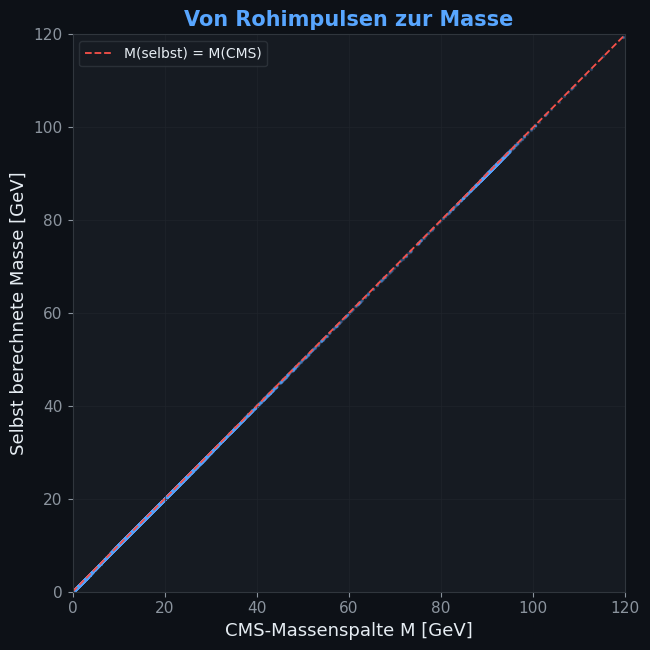

In [31]:
cu.apply_cern_style()
m_mu = cu.M_MYON   # Myonmasse = 0.105658 GeV/c²

# Energie aus dem gemessenen Impuls rekonstruieren: E = sqrt(p^2 + m^2)
def energie(px, py, pz, m): return np.sqrt(px**2 + py**2 + pz**2 + m**2)
E1 = energie(EV['px1'], EV['py1'], EV['pz1'], m_mu)
E2 = energie(EV['px2'], EV['py2'], EV['pz2'], m_mu)

# Invariante Masse:  M^2 = (E1+E2)^2 - |p1+p2|^2
E_sum  = E1 + E2
px_sum = EV['px1'] + EV['px2']
py_sum = EV['py1'] + EV['py2']
pz_sum = EV['pz1'] + EV['pz2']
MASSEN = np.sqrt(np.maximum(E_sum**2 - (px_sum**2 + py_sum**2 + pz_sum**2), 0.0))

# Ein konkretes Ereignis Schritt für Schritt
i = 4
print(f"Ereignis #{i}: zwei Myonen, entgegengesetzte Ladung (Q1={EV['Q1'][i]:+d}, Q2={EV['Q2'][i]:+d})")
print(f"  μ1: p=({EV['px1'][i]:7.2f},{EV['py1'][i]:7.2f},{EV['pz1'][i]:7.2f}) GeV  ->  E1 = {E1[i]:6.2f} GeV")
print(f"  μ2: p=({EV['px2'][i]:7.2f},{EV['py2'][i]:7.2f},{EV['pz2'][i]:7.2f}) GeV  ->  E2 = {E2[i]:6.2f} GeV")
print(f"  => invariante Masse M = {MASSEN[i]:.3f} GeV")

# Verifikation gegen die offizielle CMS-Massenspalte
resid = np.abs(MASSEN - EV['M'])
print(f"\n✅ Über alle {MASSEN.size:,} Ereignisse: Median-Abweichung {np.median(resid):.1e} GeV, "
      f"max {resid.max():.1e} GeV")
print("   -> Unsere Kinematik reproduziert die CMS-Massen (Restabweichung = CSV-Rundung).")

# Kontrollplot: selbst berechnet vs. CMS — muss auf der Diagonale liegen
fig, ax = plt.subplots(figsize=(6.6, 6.6))
ax.scatter(EV['M'], MASSEN, s=2, alpha=.20, color='#58a6ff')
ax.plot([0, 120], [0, 120], color='#f85149', lw=1.3, ls='--', label='M(selbst) = M(CMS)')
ax.set_xlabel('CMS-Massenspalte M [GeV]'); ax.set_ylabel('Selbst berechnete Masse [GeV]')
ax.set_title('Von Rohimpulsen zur Masse', color='#58a6ff', fontweight='bold')
ax.set_xlim(0, 120); ax.set_ylim(0, 120); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

---
## Teil 3 · Das Massenspektrum — die Teilchen-Leiter

> **Lernziel:** Erkennen, dass ein Histogramm aller invarianten Massen die bekannten Teilchen als
> **Resonanz-Peaks** offenbart — ein „Periodensystem" der Dimuon-Resonanzen.

Wir tragen **alle** selbst berechneten Massen in ein Histogramm ein. Weil sowohl die Massen (0,3–120 GeV)
als auch die Häufigkeiten über viele Größenordnungen reichen, nutzen wir eine **doppelt-logarithmische**
Darstellung. Jeder Buckel ist ein eigenes Teilchen, das in zwei Myonen zerfällt. Dieser eine Datensatz
enthält jahrzehntelange Entdeckungsgeschichte.

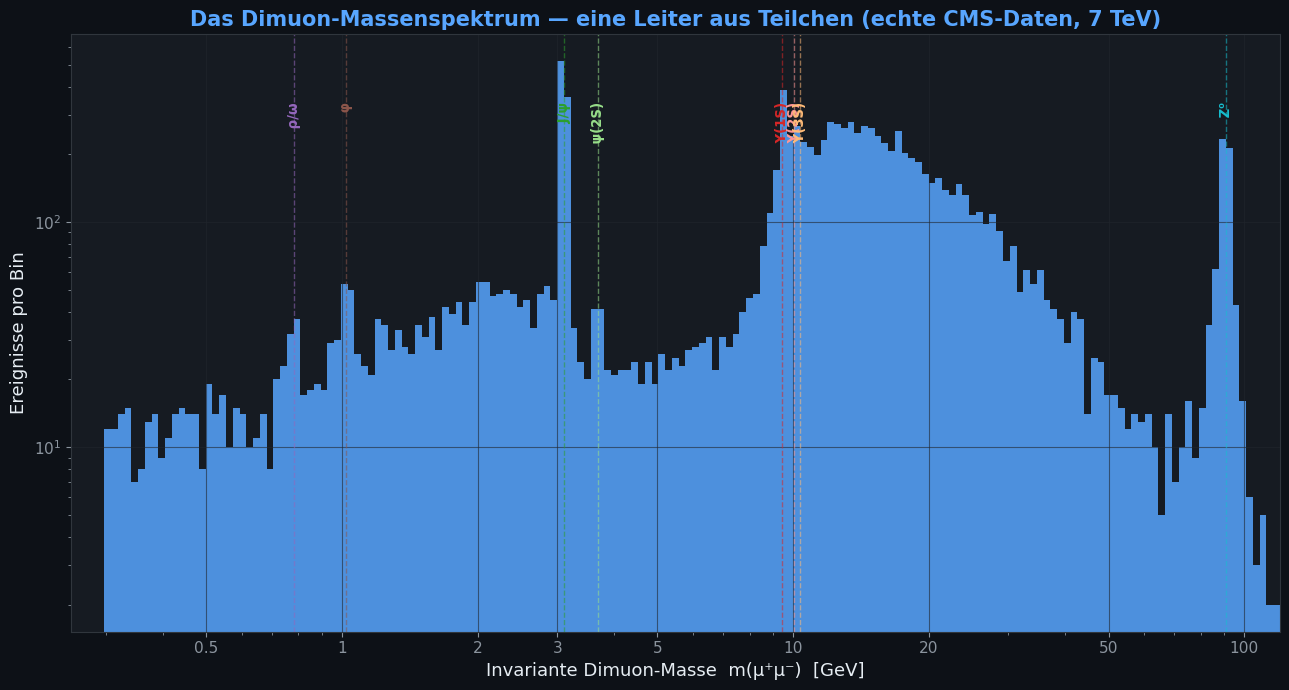

Von ρ/ω (0.78 GeV) über J/ψ, ψ(2S), das Υ-Triplett bis zum Z⁰ (91 GeV) — alles in EINEM Datensatz.
Das Higgs fehlt hier bewusst: H→μμ ist extrem selten — der echte Entdeckungskanal kommt in Teil 5.


In [32]:
cu.apply_cern_style()
if 'MASSEN' not in globals():
    MASSEN = cu.dimuon_invariante_masse(EV)

fig, ax = plt.subplots(figsize=(13, 7))
m = MASSEN[(MASSEN > 0.25) & (MASSEN < 120)]
bins = np.logspace(np.log10(0.25), np.log10(120), 180)
ax.hist(m, bins=bins, color='#58a6ff', alpha=.85, edgecolor='none')
ax.set_xscale('log'); ax.set_yscale('log')

labels = {'rho/omega': 'ρ/ω', 'phi': 'φ', 'J/psi': 'J/ψ', 'psi(2S)': 'ψ(2S)',
          'Upsilon1S': 'Υ(1S)', 'Upsilon2S': 'Υ(2S)', 'Upsilon3S': 'Υ(3S)', 'Z0': 'Z⁰'}
ymax = ax.get_ylim()[1]
for name, r in cu.RESONANZEN.items():
    if r['kanal'] != 'μ⁺μ⁻' or not (0.25 < r['m'] < 120):
        continue
    ax.axvline(r['m'], color=r['farbe'], ls='--', lw=1, alpha=.55)
    ax.text(r['m'], ymax*0.5, ' ' + labels.get(name, name), rotation=90,
            color=r['farbe'], fontsize=9.5, va='top', ha='center', fontweight='bold')

ax.set_xlabel('Invariante Dimuon-Masse  m(μ⁺μ⁻)  [GeV]')
ax.set_ylabel('Ereignisse pro Bin')
ax.set_title('Das Dimuon-Massenspektrum — eine Leiter aus Teilchen (echte CMS-Daten, 7 TeV)',
             color='#58a6ff', fontweight='bold')
ax.set_xlim(0.25, 120)
ticks = [0.5, 1, 2, 3, 5, 10, 20, 50, 100]
ax.set_xticks(ticks); ax.set_xticklabels([str(t) for t in ticks])
plt.tight_layout(); plt.show()
print("Von ρ/ω (0.78 GeV) über J/ψ, ψ(2S), das Υ-Triplett bis zum Z⁰ (91 GeV) — alles in EINEM Datensatz.")
print("Das Higgs fehlt hier bewusst: H→μμ ist extrem selten — der echte Entdeckungskanal kommt in Teil 5.")

---
## Teil 4 · Eine Resonanz vermessen

> **Lernziel:** Eine Resonanz durch **Kurvenanpassung** quantitativ vermessen — Masse und Auflösung
> mit Unsicherheit bestimmen und gegen den Literaturwert (PDG) prüfen.

Wir zoomen auf **eine** Resonanz und passen ein physikalisch motiviertes Modell an:

- **Signal:** ein **Voigt-Profil** = Faltung aus der natürlichen Breite Γ (Breit-Wigner, durch die
  Lebensdauer via $\tau=\hbar/\Gamma$ bestimmt) und der **Detektorauflösung** σ (Gauß).
- **Untergrund:** lokal linear.

Γ ist aus dem PDG bekannt und wird **fest** vorgegeben — so *messen* wir die Masse μ und die
Auflösung σ. Wechsle `RESONANZ`, um z. B. das scharfe J/ψ mit dem breiten Z⁰ zu vergleichen.

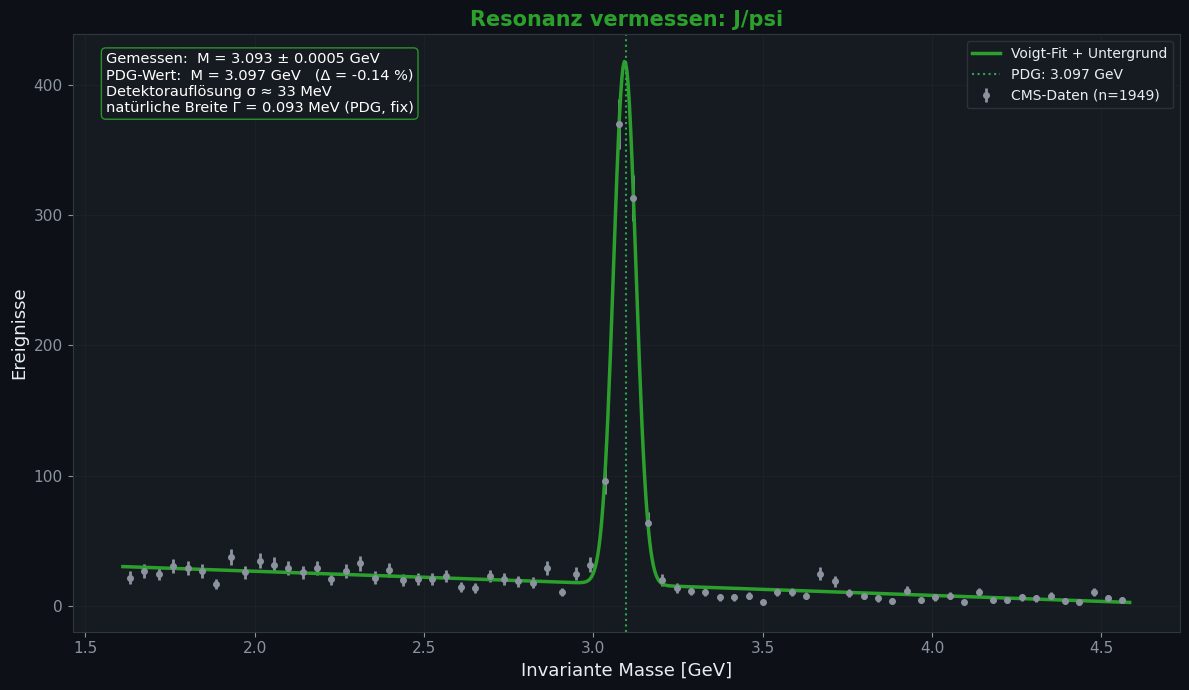

Lebensdauer aus der natürlichen Breite:  τ = ħ/Γ = 7.08e-21 s
Hinweis: der statistische Fehler ist nur ±0.5 MeV. Bei so viel Statistik dominieren
systematische Effekte (Binning, Kalibrierung, Strahlungsschwänze) den 9σ-Pull — die Masse
selbst stimmt auf 0.14% mit dem PDG-Wert überein.


In [33]:
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
cu.apply_cern_style()
if 'MASSEN' not in globals():
    MASSEN = cu.dimuon_invariante_masse(EV)

# Wählbar: "J/psi", "psi(2S)", "Upsilon1S", "Z0", "phi", "rho/omega"
RESONANZ = "J/psi"

# Echte natürliche Breiten Γ (PDG) — NICHT die Detektorauflösung!
GAMMA_NAT = {'rho/omega': 0.149, 'phi': 0.00425, 'J/psi': 9.3e-5, 'psi(2S)': 2.94e-4,
             'Upsilon1S': 5.4e-5, 'Upsilon2S': 3.2e-5, 'Upsilon3S': 2.0e-5, 'Z0': 2.495}
m0 = cu.RESONANZEN[RESONANZ]['m']; farbe = cu.RESONANZEN[RESONANZ]['farbe']
gamma = GAMMA_NAT[RESONANZ]

halb = max(0.5, 12 * max(gamma, 0.04*m0))           # Fensterbreite
lo, hi = max(0.15, m0 - halb), m0 + halb
sel = MASSEN[(MASSEN >= lo) & (MASSEN <= hi)]
h, e = np.histogram(sel, bins=70, range=(lo, hi)); c = .5*(e[1:]+e[:-1])

def modell(x, A, mu, sigma, b0, b1):
    sigma = abs(sigma)
    peak  = A * voigt_profile(x - mu, sigma, gamma/2)
    unter = np.maximum(b0 + b1*(x - m0), 0)
    return peak + unter

p0   = [h.max()*(0.04*m0 + gamma), m0, max(0.02, 0.012*m0), np.median(h), 0.0]
bnds = ([0, m0-halb/2, 0.004, 0, -np.inf], [np.inf, m0+halb/2, halb, np.inf, np.inf])
p, pc = curve_fit(modell, c, h, p0=p0, bounds=bnds, maxfev=40000)
perr = np.sqrt(np.diag(pc))
m_fit, m_err, sig_fit = p[1], perr[1], abs(p[2])

fig, ax = plt.subplots(figsize=(12, 7))
ax.errorbar(c, h, yerr=np.sqrt(np.maximum(h, 1)), fmt='o', color='#8b949e', ms=4,
            label=f'CMS-Daten (n={sel.size})')
xf = np.linspace(lo, hi, 800)
ax.plot(xf, modell(xf, *p), color=farbe, lw=2.5, label='Voigt-Fit + Untergrund')
ax.axvline(m0, color='#2ea44f', ls=':', lw=1.5, label=f'PDG: {m0:.4g} GeV')
ax.set_xlabel('Invariante Masse [GeV]'); ax.set_ylabel('Ereignisse')
ax.set_title(f'Resonanz vermessen: {RESONANZ}', color=farbe, fontweight='bold')
rel  = (m_fit - m0)/m0*100                         # relative Abweichung [%]
txt = (f'Gemessen:  M = {m_fit:.4g} ± {m_err:.2g} GeV\n'
       f'PDG-Wert:  M = {m0:.4g} GeV   (Δ = {rel:+.2f} %)\n'
       f'Detektorauflösung σ ≈ {sig_fit*1000:.0f} MeV\n'
       f'natürliche Breite Γ = {gamma*1000:.3g} MeV (PDG, fix)')
ax.text(.03, .97, txt, transform=ax.transAxes, va='top', fontsize=10.5,
        bbox=dict(boxstyle='round', fc='#161b22', ec=farbe, alpha=.9), color='#fff')
ax.legend(loc='upper right', framealpha=.85)
plt.tight_layout(); plt.show()

hbar = 6.582e-25  # GeV·s
print(f"Lebensdauer aus der natürlichen Breite:  τ = ħ/Γ = {hbar/gamma:.2e} s")
pull = abs(m_fit - m0)/m_err if m_err > 0 else float('nan')
print(f"Hinweis: der statistische Fehler ist nur ±{m_err*1000:.1f} MeV. Bei so viel Statistik dominieren\n"
      f"systematische Effekte (Binning, Kalibrierung, Strahlungsschwänze) den {pull:.0f}σ-Pull — die Masse\n"
      f"selbst stimmt auf {abs(rel):.2f}% mit dem PDG-Wert überein.")

---
## Teil 5 · Entdeckung & Signifikanz

> **Lernziel:** Quantifizieren, *wann* ein Peak eine **Entdeckung** ist — über die statistische
> Signifikanz und das **5σ-Kriterium** — und verstehen, warum mehr Daten (Luminosität) entscheidend sind.

Ein Buckel ist erst dann eine Entdeckung, wenn er **nicht** als zufällige Untergrund-Fluktuation erklärbar
ist. Eine einfache, gängige Kennzahl ist

$$Z \approx \frac{S}{\sqrt{B}}\,,$$

mit Signalzahl $S$ und Untergrund $B$ unter dem Peak (aus den **Seitenbändern** geschätzt). Die Konvention
der Teilchenphysik: **5σ** (Wahrscheinlichkeit einer Fluktuation ≈ 1 zu 3,5 Mio.) = *Entdeckung*, 3σ =
*Hinweis*. Weil $S\propto N$ und $B\propto N$ wächst, gilt $Z\propto\sqrt{N}$ — **mehr Statistik schärft das
Signal**. Genau deshalb brauchte das seltene **Higgs** (Goldkanal H→ZZ\*→4ℓ) Jahre an Daten bis zur
Entdeckung am **4. Juli 2012**.

Z⁰-Fenster (85.19, 97.19) GeV:  S ≈ 507 Signal,  B ≈ 45 Untergrund  ->  Z = S/√B = 75.6σ


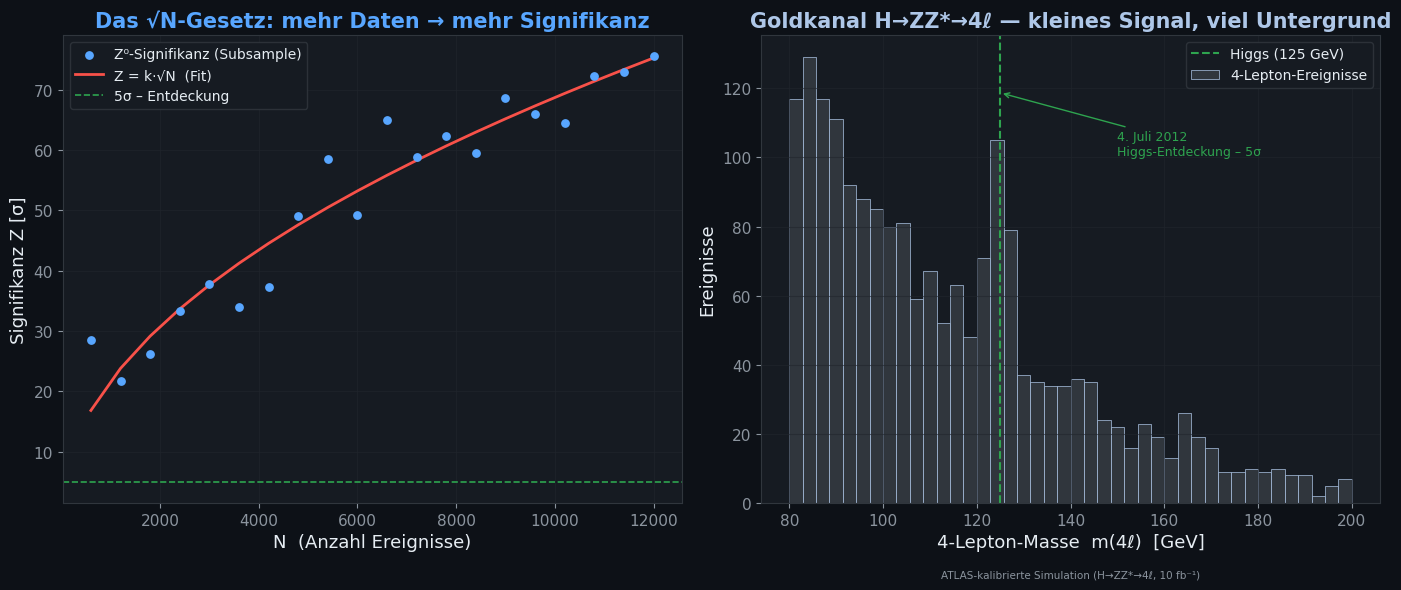


Das Z⁰ ist mit 76σ ein müheloses Signal. Das Higgs dagegen liefert nur ~120 Signal-Ereignisse auf großem Untergrund — erst genug Luminosität brachte 2012 die 5σ.


In [34]:
cu.apply_cern_style()
if 'MASSEN' not in globals():
    MASSEN = cu.dimuon_invariante_masse(EV)

# --- (A) Signifikanz des Z⁰-Peaks DIREKT aus den Daten ---
m0 = cu.RESONANZEN['Z0']['m']
sig_region = (m0 - 6, m0 + 6)                       # Signalfenster
seiten     = [(m0 - 18, m0 - 8), (m0 + 8, m0 + 18)] # Seitenbänder (reiner Untergrund)
zähle = lambda a, lo, hi: int(np.sum((a >= lo) & (a < hi)))

def signifikanz(massen):
    n_sr = zähle(massen, *sig_region)
    b_cts = sum(zähle(massen, a, b) for a, b in seiten)
    b_wid = sum(b - a for a, b in seiten)
    B = b_cts * (sig_region[1] - sig_region[0]) / b_wid   # Untergrund auf Signalbreite skaliert
    S = max(n_sr - B, 0.0)
    return S, B, (S/np.sqrt(B) if B > 0 else 0.0)

S, B, Z = signifikanz(MASSEN)
print(f"Z⁰-Fenster {sig_region} GeV:  S ≈ {S:.0f} Signal,  B ≈ {B:.0f} Untergrund  ->  Z = S/√B = {Z:.1f}σ")

# √N-Gesetz: Signifikanz bei wachsender Statistik (Subsampling)
rng = np.random.default_rng(0)
frac = np.linspace(0.05, 1.0, 20)
Zf = np.array([signifikanz(MASSEN[rng.choice(MASSEN.size, int(f*MASSEN.size), replace=False)])[2]
               for f in frac])
Nv = frac * MASSEN.size

fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 6))
axA.scatter(Nv, Zf, color='#58a6ff', s=28, zorder=3, label='Z⁰-Signifikanz (Subsample)')
k = np.sum(Zf*np.sqrt(Nv))/np.sum(Nv)                 # Ursprungsgerade Z = k·√N
axA.plot(Nv, k*np.sqrt(Nv), color='#f85149', lw=2, label='Z = k·√N  (Fit)')
axA.axhline(5, color='#2ea44f', ls='--', lw=1.2, label='5σ – Entdeckung')
axA.set_xlabel('N  (Anzahl Ereignisse)'); axA.set_ylabel('Signifikanz Z [σ]')
axA.set_title('Das √N-Gesetz: mehr Daten → mehr Signifikanz', color='#58a6ff', fontweight='bold')
axA.legend(loc='upper left', framealpha=.85)

# --- (B) Der echte Entdeckungskanal: Higgs → ZZ* → 4ℓ (ATLAS-kalibrierte Simulation) ---
m4l, info4 = cu.lade_higgs_4l()
h4, e4 = np.histogram(m4l, bins=42, range=(80, 200)); c4 = .5*(e4[1:]+e4[:-1])
axB.bar(c4, h4, width=(e4[1]-e4[0]), color='#30363d', edgecolor='#aec7e8', lw=.5,
        label='4-Lepton-Ereignisse')
axB.axvline(125, color='#2ea44f', ls='--', lw=1.5, label='Higgs (125 GeV)')
disc = cu.HISTORIE['discovery']
axB.annotate(f"{disc['datum']}\n{disc['text']}", xy=(125, h4.max()*0.92),
             xytext=(150, h4.max()*0.78), color='#2ea44f', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='#2ea44f'))
axB.set_xlabel('4-Lepton-Masse  m(4ℓ)  [GeV]'); axB.set_ylabel('Ereignisse')
axB.set_title('Goldkanal H→ZZ*→4ℓ — kleines Signal, viel Untergrund', color='#aec7e8', fontweight='bold')
axB.legend(loc='upper right', framealpha=.85)
axB.text(.5, -.16, info4['quelle'], transform=axB.transAxes, ha='center', fontsize=7.5, color='#8b949e')
plt.tight_layout(); plt.show()

print(f"\nDas Z⁰ ist mit {Z:.0f}σ ein müheloses Signal. Das Higgs dagegen liefert nur ~{info4['n_signal']} "
      f"Signal-Ereignisse auf großem Untergrund — erst genug Luminosität brachte 2012 die 5σ.")

---
## Teil 6 · Maschinenphysik & Reichweite

> **Lernziel:** Quantifizieren, warum **höhere Energie schwerere Teilchen** zugänglich macht — und warum
> das Dipolfeld die LHC-Energie begrenzt.

Um ein Teilchen der Masse $M$ zu erzeugen, muss die **Schwerpunktsenergie** $\sqrt{s}$ mindestens $M$
betragen (notwendige Bedingung). Bei zwei gegenläufigen Strahlen der Energie $E$ gilt $\sqrt{s}=2E$.
Gehalten werden die Teilchen von Dipolmagneten:

$$B = \frac{p}{0{,}3\,\rho}\,,$$

mit Krümmungsradius $\rho\approx 2804\,$m. Die supraleitenden Dipole quenchen oberhalb von **8,33 T** — das
deckelt die LHC-Energie bei **7 TeV** pro Strahl. Für **Blei-Ionen** (Ladung $Z{=}82$, Massenzahl $A{=}208$)
skaliert das nötige Feld mit $A/Z$, und der Lorentz-Faktor wird **pro Nukleon** gerechnet,
$\gamma = E_\text{Nukleon}/m_N$.

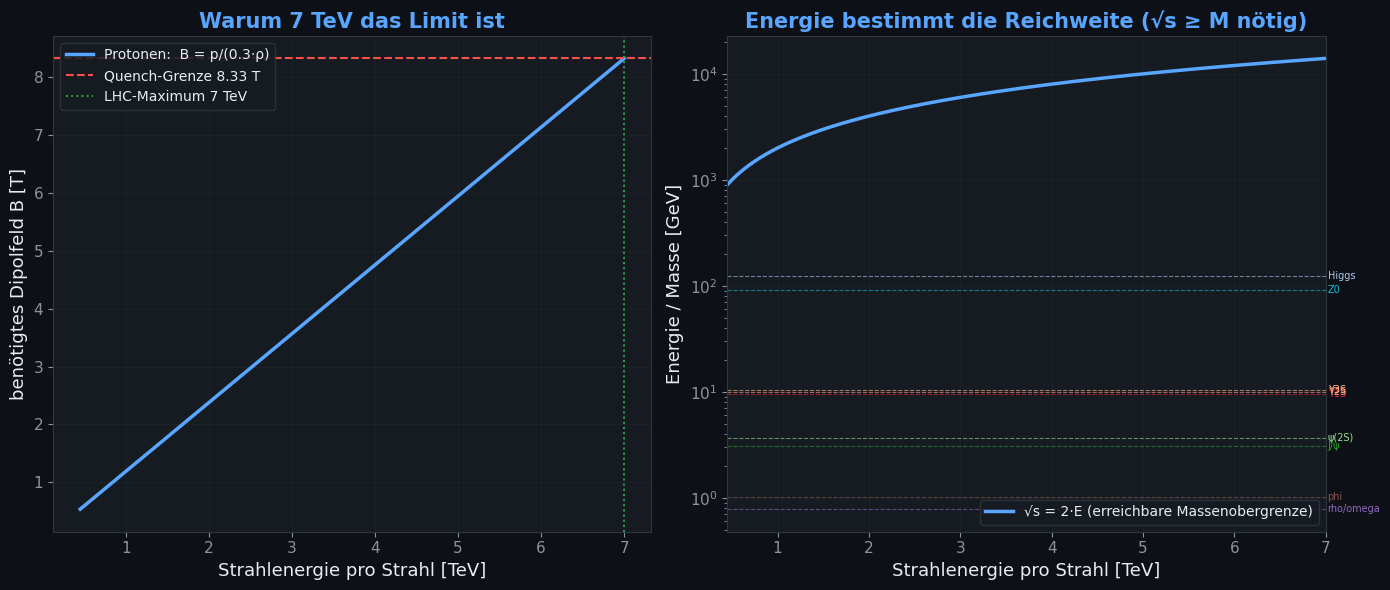

Blei-Ionen (Pb⁸²⁺, A=208):
  @ 0.177 TeV/u:  B =  0.53 T   γ =    190
  @ 2.560 TeV/u:  B =  7.72 T   γ =  2,748
  Die 2.56-TeV/u-Obergrenze entspricht genau dem 8.33-T-Quench-Limit der Dipole.


In [35]:
cu.apply_cern_style()
rho   = 2803.95                 # Krümmungsradius der LHC-Dipole [m]
k     = 0.299792458 * rho       # Rigiditäts-Faktor: B = p / k
B_max = 8.33                    # Quench-Grenze der supraleitenden Dipole [T]

E = np.linspace(0.45, 7.0, 200) * 1000   # Strahlenergie pro Strahl [GeV] (p ≈ E bei v≈c)
B_p = E / k

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 6))
# Links: Dipolfeld vs. Energie — warum 7 TeV das Limit ist
axL.plot(E/1000, B_p, color='#58a6ff', lw=2.5, label='Protonen:  B = p/(0.3·ρ)')
axL.axhline(B_max, color='#f85149', ls='--', lw=1.5, label=f'Quench-Grenze {B_max} T')
axL.axvline(7.0, color='#2ea44f', ls=':', lw=1.4, label='LHC-Maximum 7 TeV')
axL.set_xlabel('Strahlenergie pro Strahl [TeV]'); axL.set_ylabel('benötigtes Dipolfeld B [T]')
axL.set_title('Warum 7 TeV das Limit ist', color='#58a6ff', fontweight='bold')
axL.legend(loc='upper left', framealpha=.85)

# Rechts: Schwerpunktsenergie √s = 2E setzt die Massen-Reichweite
axR.plot(E/1000, 2*E, color='#58a6ff', lw=2.5, label='√s = 2·E (erreichbare Massenobergrenze)')
for name, r in cu.RESONANZEN.items():
    axR.axhline(r['m'], color=r['farbe'], ls='--', lw=.8, alpha=.6)
    axR.text(7.02, r['m'], name.replace('Upsilon', 'Υ').replace('psi', 'ψ'),
             color=r['farbe'], fontsize=7, va='center')
axR.set_yscale('log'); axR.set_xlim(0.45, 7.0)
axR.set_xlabel('Strahlenergie pro Strahl [TeV]'); axR.set_ylabel('Energie / Masse [GeV]')
axR.set_title('Energie bestimmt die Reichweite (√s ≥ M nötig)', color='#58a6ff', fontweight='bold')
axR.legend(loc='lower right', framealpha=.85)
plt.tight_layout(); plt.show()

print("Blei-Ionen (Pb⁸²⁺, A=208):")
for E_n in [0.177, 2.56]:
    Eg = E_n*1000; B = (208/82)*Eg/k; g = Eg/0.9315
    print(f"  @ {E_n:5.3f} TeV/u:  B = {B:5.2f} T   γ = {g:>6,.0f}")
print(f"  Die 2.56-TeV/u-Obergrenze entspricht genau dem {B_max}-T-Quench-Limit der Dipole.")

---
## Teil 7 · Zusammenfassung & Übungen

Du hast den vollständigen Weg der experimentellen Teilchenphysik durchlaufen:

1. **Die Maschine** — Beschleunigung, Speicherung und Kollision im LHC (Stellwerk).
2. **Rohdaten → Masse** — invariante Masse aus gemessenen Impulsen ($M^2=(\sum E)^2-|\sum\vec p|^2$).
3. **Das Spektrum** — die Resonanz-Leiter von ρ/ω bis Z⁰ in echten CMS-Daten.
4. **Resonanz vermessen** — Voigt-Fit, Masse & Auflösung vs. PDG, Lebensdauer aus der Breite.
5. **Signifikanz** — $Z=S/\sqrt B$, das √N-Gesetz und das 5σ-Kriterium (Higgs, 4. Juli 2012).
6. **Maschinenphysik** — $\sqrt s=2E$, das 8,33-T-Limit und die Massen-Reichweite.

### 🧩 Übungen für den Begabtenkurs
1. **Υ-Triplett auflösen:** Setze in Teil 4 `RESONANZ="Upsilon1S"` und vergrößere das Fenster. Kannst du
   Υ(1S/2S/3S) trennen? Welche **Detektorauflösung** σ wäre dafür nötig (Abstand der Zustände ≈ 0,56 GeV)?
2. **Lebensdauer des Z⁰:** Bestimme aus Γ(Z⁰)=2,495 GeV die Lebensdauer $\tau=\hbar/\Gamma$. Vergleiche
   mit dem J/ψ — warum ist das eine so viel „schärfer" als das andere?
3. **Wie viel Statistik für 5σ?** Wenn ein Signal anfänglich nur $Z=1{,}2\sigma$ liefert: um welchen Faktor
   muss die Datenmenge $N$ wachsen, um 5σ zu erreichen? (√N-Gesetz)
4. **Volle Statistik:** Setze in Teil 1 `LADE_VOLLEN_DATENSATZ=True`, lade den vollen CMS-Datensatz und
   wiederhole Teil 3–5. Wie verändern sich Peaks und Signifikanz?
5. **Warum kein Higgs im Dimuon-Spektrum?** Recherchiere das Verzweigungsverhältnis von H→μμ (~0,02 %) und
   schätze, wie viele Ereignisse man bräuchte, um es im Spektrum aus Teil 3 zu sehen.
6. **Collider-Design:** Welche Strahlenergie pro Strahl bräuchte man, um ein hypothetisches Teilchen von
   1 TeV zu erzeugen? Welches Dipolfeld wäre bei gleichem Radius $\rho$ nötig?

> **Ausblick:** Dieselben Methoden — invariante Masse, Spektren, Fits, Signifikanz — tragen von hier bis zur
> Forschungsfront: zu Präzisionsmessungen, der Suche nach Dunkler Materie und neuer Physik jenseits des
> Standardmodells.